# Publication / Inferential Analysis — Endometriosis & Intrapartum Cesarean Section
## Sheba Medical Center

---

## Scientific question

This notebook is the association / descriptive companion to the canonical
predictive modeling pipeline. It asks a different question than the
predictive pipeline does:

- **Predictive pipeline (elsewhere):** how well can `target_intrapartum_cs`
  be predicted out-of-sample from the available predictor pool?
- **This notebook:** which predictors — and in particular, which
  endometriosis-specific phenotype/surgical-history features — are
  **associated** with intrapartum cesarean delivery, in the whole cohort,
  described in clinically interpretable units, with and without adjustment
  for a small pre-specified conventional covariate set?

**This is not a causal analysis.** Throughout, results are described as
*association*, *adjusted association*, *predictive contribution*,
*incremental predictive value*, or *exploratory finding* — never as
*causes*, *effect of*, or *independent causal effect*.

**How the two halves of this notebook are computed, in one sentence each:**
the association/descriptive analyses (Sections A–G, I — Table 1, univariable
associations, BH-FDR, endometriosis-specific findings, adjusted associations,
research-signal evidence, figures) are **computed live, in this notebook**, every time
it is run end-to-end from a clean kernel against the real patient-level
cohort; the Compact Ridge predictive results (Section H) are **consumed
read-only** from already-persisted locked/final publication artifacts and are
never re-fit, tuned, or rerun here.

### Prediction vs. association — why both exist and why they can disagree
A predictor can be strongly *associated* with the outcome in a univariable
or adjusted regression while contributing little *incremental predictive
value* on top of everything else already in a multivariable model (because
it is redundant with other predictors) — and vice versa. Sections below keep
these two kinds of evidence in clearly separate tables and never substitute
one for the other.

### Strict separation from the predictive modeling pipeline
This notebook and its supporting code (`analysis/publication_analysis/`)
never import from, write to, or execute the predictive-modeling package or
its outputs. Where this notebook shows predictive-model context (Section H)
it is a **read-only consumer** of already-persisted result artifacts — it
never re-fits, tunes, or reruns the predictive model. The one exception is a
read-only, file-path load of the canonical subject-grouping helper for the
parity check at the end of Section A (that helper is never modified and no
model is run).

### Status note

All sections (A–I) implement, and are cross-checked for internal consistency
against, the current predictor pool, the locked `PRIMARY_ADJUSTMENT_SET` /
`SENSITIVITY_ADJUSTMENT_SET`, the single-source-of-truth univariable/BH-FDR
join used by every downstream section, and the current Compact Ridge
(Decision 99) predictive context.

Sections A–G — and the Section I figures generated from this notebook's own
live association analyses (the univariable and endometriosis-specific forest
plots) — are computed live from the real patient-level cohort each time the
notebook is run end-to-end from a clean kernel; nothing in those sections is
a cached or pre-computed number. Re-running the notebook is how a result
reported in Sections A–G/I is produced and reproduced; the fail-loud contract
checks in Section A below (and the runtime subject-grouping parity gate) halt
the run before any inferential section if the live cohort ever diverges from
what this notebook expects.

Section H is different by design: it consumes the already-accepted, locked
Compact Ridge, six-predictor adjusted-OR, and Firth-sensitivity artifacts
**read-only** and never refits, tunes, or reruns them (see Section H's own
header for the full read-only contract) — its performance-table/figure/
coefficient content is reproduced from the locked artifact files on disk each
run, not recomputed live in this notebook.

Section A (this part) is the canonical input contract: the analysis runs
exclusively on the 81-predictor EDA-C modeling matrix
(`outputs/eda_c/modeling_dataset_candidate_features.xlsx`), never the Data
Cleaning B dataframe. The subject-grouping key is checked **at runtime** (not
by a stored verdict) against the canonical predictive-pipeline implementation
— the parity cell in Section A raises and halts the notebook if they ever
diverge.

---
## Section A — Analysis Contract

Two layers of validation, both **fail-loud**:

1. **Metadata contract** — canonical cohort / stage / endometriosis-family
   counts against the live variable-level manifests (no patient row read).
2. **Analytical-matrix contract** — the real 81-predictor matrix: N = 431,
   target 370 / 61 with no missing and values in {0, 1}, exactly 81
   predictor columns in the exact order of `candidate_model_features.csv`,
   no duplicate columns or registry names, and agreement with the manifest's
   `n_rows` / `n_events` / `n_eligible_pool`.

Row identity (for subject-cluster-robust SEs) is recovered separately through
the canonical row-alignment sidecar and `work_df_batch18.xlsx`.

In [1]:
from analysis.publication_analysis import publication_contract as contract

report = contract.validate_contract(strict=True)  # raises PublicationContractError on any mismatch

print(f"Eligible predictor pool: {report.n_eligible_pool}")
print(f"Cumulative stage sizes (1/2/3): {report.stage_cumulative}")
print(f"Target distribution (0/1): {report.target_0}/{report.target_1}")
print(f"Endometriosis-specific family size: {report.endometriosis_family_size}")
print(
    "Endometriosis family matches EDA-C domain-derived subset: "
    f"{report.endometriosis_family_matches_domain_subset}"
)
print(f"Data Cleaning B shape: {report.cleaning_b_n_rows} x {report.cleaning_b_n_cols}")

Eligible predictor pool: 81
Cumulative stage sizes (1/2/3): {1: 70, 2: 76, 3: 81}
Target distribution (0/1): 370/61
Endometriosis-specific family size: 35
Endometriosis family matches EDA-C domain-derived subset: True
Data Cleaning B shape: 431 x 82


In [2]:
from analysis.publication_analysis import analysis_matrix as amx

# Positionally align the analytical matrix to the validated 0..430 sidecar.
matrix_df, row_key_df = amx.load_aligned_analysis_inputs()

# Fail loud unless the real matrix matches the canonical 81-predictor contract.
matrix_report = amx.validate_analysis_matrix(matrix_df, strict=True)

predictor_names = amx.predictor_columns(matrix_df)   # 81 names, canonical order
df = matrix_df                                       # analytical matrix used by later sections

# Registry metadata reused by later sections (types / stage / family membership).
features_df = contract.load_candidate_features()
endo_family_names = contract.endometriosis_family_names()

print(
    f"Analytical matrix: {matrix_df.shape[0]} rows x {matrix_df.shape[1]} cols "
    f"(target + {matrix_report.n_predictors} predictors)"
)
print(f"Row-alignment sidecar rows: {len(row_key_df)}")
print(f"Target 0/1 in matrix: {matrix_report.target_0}/{matrix_report.target_1}")
print(f"Analytical-matrix contract OK: {matrix_report.ok}")

Analytical matrix: 431 rows x 82 cols (target + 81 predictors)
Row-alignment sidecar rows: 431
Target 0/1 in matrix: 370/61
Analytical-matrix contract OK: True


In [3]:
from analysis.publication_analysis import subject_grouping

batch18_df = subject_grouping.load_batch18()
subject_groups = subject_grouping.build_subject_groups(matrix_df, row_key_df, batch18_df)
group_summary = subject_grouping.summarize_subject_groups(matrix_df, row_key_df, batch18_df)

print(f"rows: {group_summary.n_rows}")
print(f"unique subject clusters: {group_summary.n_unique_groups}")
print(f"rows without a linked subject id: {group_summary.n_rows_missing_subject_number}")
print(f"clusters with more than one delivery: {group_summary.n_repeated_subject_groups}")
print(f"rows in multi-delivery clusters: {group_summary.n_rows_in_repeated_subject_groups}")
print(f"max deliveries per subject: {group_summary.max_deliveries_per_subject}")

rows: 431
unique subject clusters: 430
rows without a linked subject id: 8
clusters with more than one delivery: 1
rows in multi-delivery clusters: 2
max deliveries per subject: 2


### Subject-grouping parity gate (runtime)

The cell below is the **authoritative** parity check. It re-runs, every time
this notebook executes, a read-only comparison of the publication grouping
against the canonical predictive-pipeline implementation
`analysis/modeling/final_modeling/subject_groups.py::load_group_labels`
(loaded by file path; that module is never modified and no model is run). It
**raises `SubjectGroupParityError` and halts the notebook** unless BOTH hold
for all 431 rows:

- (A) exact row-wise label equality (implementation-integrity check);
- (B) partition equivalence — same rows grouped together / apart (the
  requirement for subject-cluster-robust standard errors).

No dated/stored "PASS" is trusted. The same check is available on the command
line: `.venv312\Scripts\python.exe analysis/publication_analysis/verify_subject_group_parity.py`

In [4]:
from analysis.publication_analysis.verify_subject_group_parity import (
    verify_live_subject_group_parity,
)

# RUNTIME GATE: raises SubjectGroupParityError (halting the notebook before any
# inferential section) unless exact row-label equality AND partition
# equivalence both hold for every row, checked live against the canonical
# final_modeling grouping.
parity_result = verify_live_subject_group_parity(strict=True)

print(f"rows compared:                {parity_result.n_rows}")
print(f"(A) exact row-label equality: {parity_result.row_label_equal}")
print(f"(B) partition equivalence:    {parity_result.partition_equivalent}")
print("subject-group parity gate: PASS")

rows compared:                431
(A) exact row-label equality: True
(B) partition equivalence:    True
subject-group parity gate: PASS


---
## Section B — Representation Contract and Data Quality Audit

### Publication Representation Contract (all 81 source predictors)

Exactly **one row per canonical source predictor**, in canonical registry
order. Each predictor is assigned an `inferential_role` — one of
`BINARY`, `CONTINUOUS`, `COUNT`, `CATEGORICAL`, `DESCRIPTIVE_ONLY`, or
`PENDING_REPRESENTATION_REVIEW` — grounded in an existing repository source
recorded in `source_of_decision`. This contract is the **single
representation-decision source of truth** for the whole publication package —
no other module builds an independent decision table.

`publication_status` is distinct from `inferential_role`. In the current
final contract **no representation decision remains pending**: all **73**
`BINARY` / `CATEGORICAL` / `CONTINUOUS` / `COUNT` predictors carry an
**`APPROVED`** inferential representation, and the remaining **8** predictors
carry a **final `DESCRIPTIVE_ONLY`** representation — a completed
clinical/methodological decision to describe rather than fit, **not** an
awaiting-sign-off state. No row is `PENDING_CLINICAL_SIGNOFF` or
`PENDING_REPRESENTATION_REVIEW`; `PENDING_CLINICAL_SIGNOFF` is retained only
as an architectural status for possible future use.

For `BINARY` predictors, `binary_semantic_status` distinguishes
**`EXPLICITLY_DOCUMENTED`** (a repository source states what 0 and 1 mean for
*that* predictor) from **`GENERIC_1_VS_0`** (the predictor is canonically 0/1
binary, but no repository source documents a predictor-specific clinical
present/absent/yes/no meaning — the reportable contrast is only "value 1 vs
value 0", never "present vs absent"). `physical_variable_type=binary` /
`model_representation_type=binary_passthrough` alone never proves a
clinical present/absent meaning.

Machine-only predictive transformations (fold-specific cutpoints, quantile
bins, scaler outputs) are **never** reused for inferential reporting. Where
no defensible reference level / category order / clinical unit is on record,
the predictor stays `PENDING_REPRESENTATION_REVIEW` — a representation is
never invented here.

In [5]:
from analysis.publication_analysis import publication_representations as repr_mod
from analysis.publication_analysis import publication_exports as exports

representation_contract = repr_mod.build_publication_representation_contract()
repr_summary = repr_mod.summarize_publication_representation_contract(representation_contract)

print(f"source predictors in contract: {repr_summary.n_total}")
print("inferential_role counts:")
for role, n in repr_summary.n_by_role.items():
    print(f"  {role:31s} {n}")
print("publication_status counts:")
for status, n in repr_summary.n_by_publication_status.items():
    print(f"  {status:31s} {n}")
print("binary_semantic_status counts (BINARY predictors only):")
for status, n in repr_summary.n_by_binary_semantic_status.items():
    print(f"  {status:31s} {n}")
print(f"needs_clinical_signoff = True (expect 0 — no pending representation decisions): {repr_summary.n_needs_signoff}")

exports.ensure_output_dirs()
exports.save_table_csv(representation_contract, exports.PUBLICATION_REPRESENTATION_CONTRACT_CSV)
representation_contract

source predictors in contract: 81
inferential_role counts:
  BINARY                          55
  CATEGORICAL                     10
  CONTINUOUS                      6
  COUNT                           2
  DESCRIPTIVE_ONLY                8
  PENDING_REPRESENTATION_REVIEW   0
publication_status counts:
  APPROVED                        73
  DESCRIPTIVE_ONLY                8
  PENDING_CLINICAL_SIGNOFF        0
  PENDING_REPRESENTATION_REVIEW   0
binary_semantic_status counts (BINARY predictors only):
  EXPLICITLY_DOCUMENTED           6
  GENERIC_1_VS_0                  49
needs_clinical_signoff = True (expect 0 — no pending representation decisions): 0


,predictor,physical_type,earliest_entry_stage,canonical_model_representation,model_entry_mode,publication_status,publication_value_source,publication_representation,inferential_role,binary_semantic_status,...,native_unit,reporting_unit,continuous_unit_scale,reference_level,category_order,raw_code_to_publication_label,functional_form_status,source_of_decision,needs_clinical_signoff,reason
0,nulliparity,binary,1,binary_passthrough,direct,APPROVED,raw_cleaned_column,"binary passthrough, value 1 = no prior deliver...",BINARY,EXPLICITLY_DOCUMENTED,...,code 0/1,n/a,NaN,0,None,None,NOT_APPLICABLE,outputs/eda_c/candidate_model_features.csv (ph...,False,Canonical 0/1 binary passthrough with an expli...
1,pregnancy_related_hypertensive_disorder,binary,1,binary_passthrough,direct,APPROVED,raw_cleaned_column,"binary passthrough, value 1 vs value 0",BINARY,GENERIC_1_VS_0,...,code 0/1,n/a,NaN,0,None,None,NOT_APPLICABLE,outputs/eda_c/candidate_model_features.csv: ph...,False,Canonical 0/1 binary passthrough; the statisti...
2,gestational_diabetes,binary,1,binary_passthrough,direct,APPROVED,raw_cleaned_column,"binary passthrough, value 1 vs value 0",BINARY,GENERIC_1_VS_0,...,code 0/1,n/a,NaN,0,None,None,NOT_APPLICABLE,outputs/eda_c/candidate_model_features.csv: ph...,False,Canonical 0/1 binary passthrough; the statisti...
3,aspirin_during_pregnancy,binary,1,binary_passthrough,direct,APPROVED,raw_cleaned_column,"binary passthrough, value 1 vs value 0",BINARY,GENERIC_1_VS_0,...,code 0/1,n/a,NaN,0,None,None,NOT_APPLICABLE,outputs/eda_c/candidate_model_features.csv: ph...,False,Canonical 0/1 binary passthrough; the statisti...
4,S_P_CS,binary,1,binary_passthrough,direct,APPROVED,raw_cleaned_column,"binary passthrough, value 1 = previous CS vs v...",BINARY,EXPLICITLY_DOCUMENTED,...,code 0/1,n/a,NaN,0,None,None,NOT_APPLICABLE,outputs/eda_c/candidate_model_features.csv (ph...,False,Canonical 0/1 binary passthrough with an expli...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,weight_before_pregnancy,continuous,1,same_as_physical_numeric,direct,APPROVED,raw_cleaned_column,"APPROVED continuous, raw kg -- final inferenti...",CONTINUOUS,None,...,kg,Nonlinear spline (df=3),NaN,None,None,None,NONLINEAR_FORM_APPROVED,CLAUDE.md 'Anthropometry / Hb missingness (Dat...,False,Raw clinical unit (kg). NONLINEAR_FORM_APPROVE...
77,Hb_before_delivery,continuous,2,same_as_physical_numeric,direct,APPROVED,raw_cleaned_column,"APPROVED continuous, raw g/dL, OR per 1 g/dL -...",CONTINUOUS,None,...,g/dL,1 g/dL,1.0,None,None,None,LINEAR_FORM_APPROVED,"CLAUDE.md 'Hb_before_delivery, Hb_after_delive...",False,"Numeric g/dL; OR reported per 1 g/dL, one-slop..."
78,weight_in_pregnancy,continuous,2,fold_safe_quantile_categorical,transform_source_only,DESCRIPTIVE_ONLY,fold_safe_transform_source_raw_column,"descriptive only, raw kg — no fixed inferentia...",DESCRIPTIVE_ONLY,None,...,kg,n/a,NaN,None,None,None,NOT_APPLICABLE,CLAUDE.md 'weight_in_pregnancy (current)' + Da...,False,Measurement timing is not sufficiently standar...
79,BMI_after,continuous,2,fold_safe_quantile_categorical,transform_source_only,DESCRIPTIVE_ONLY,fold_safe_transform_source_raw_column,"descriptive only, raw kg/m^2 — no fixed infere...",DESCRIPTIVE_ONLY,None,...,kg/m^2,n/a,NaN,None,None,None,NOT_APPLICABLE,CLAUDE.md 'BMI_after (current)' + manual_decis...,False,Near-delivery / postpartum-discharge-influence...


### Representation sign-off review table

Every predictor that still **genuinely** needs a clinical/representation
decision: `needs_clinical_signoff == True` **or**
`inferential_role == PENDING_REPRESENTATION_REVIEW`. The 8 finalized
`DESCRIPTIVE_ONLY` predictors are **resolved** decisions and are not listed
here. For the current live 81-row contract this table is **empty** — no
representation decision remains pending.

In [6]:
representation_review = repr_mod.build_representation_review_table(representation_contract)

pending_predictors = repr_summary.pending_predictors
pending_signoff_predictors = repr_summary.pending_clinical_signoff_predictors
print(f"rows requiring clinical sign-off / review: {len(representation_review)}")
print(f"PENDING_REPRESENTATION_REVIEW ({len(pending_predictors)}):")
for name in pending_predictors:
    print(f"  - {name}")
print(f"PENDING_CLINICAL_SIGNOFF ({len(pending_signoff_predictors)}, proposed but not clinician-approved):")
for name in pending_signoff_predictors:
    print(f"  - {name}")

exports.save_table_csv(representation_review, exports.REPRESENTATION_SIGNOFF_REVIEW_CSV)
representation_review

rows requiring clinical sign-off / review: 0
PENDING_REPRESENTATION_REVIEW (0):
PENDING_CLINICAL_SIGNOFF (0, proposed but not clinician-approved):


,predictor,physical_type,earliest_entry_stage,inferential_role,publication_status,reference_level,category_order,native_unit,reporting_unit,continuous_unit_scale,functional_form_status,source_of_decision,reason,needs_clinical_signoff


### Full variable / quality audit

For all 81 eligible predictors: earliest stage, domain, endometriosis-family
membership, publication `inferential_role`, non-missing / missing counts,
unique-value counts, and (for binary predictors) `value_1_rows` /
`value_1_unique_subjects` counts — i.e. rows/subjects where the stored
numeric value equals 1. This is a **numeric** count, not a claim of clinical
positivity: see `binary_semantic_status` in the representation contract for
which binary predictors have a repository-documented clinical meaning for
value 1 versus value 0.

In [7]:
from analysis.publication_analysis.descriptive_analysis import (
    variable_types_from_candidate_features,
    stage_map_from_candidate_features,
)

variable_types = variable_types_from_candidate_features(features_df)
stage_map = stage_map_from_candidate_features(features_df)
endo_family = contract.endometriosis_family_names()

_role_by_pred = representation_contract.set_index("predictor")["inferential_role"].to_dict()
_status_by_pred = representation_contract.set_index("predictor")["publication_status"].to_dict()
_domain_by_pred = features_df.set_index("variable")["domain"].to_dict()

quality_rows = []
for variable in features_df["variable"]:
    series = df[variable]
    non_missing = series.dropna()
    row = {
        "predictor": variable,
        "earliest_stage": stage_map.get(variable),
        "domain": _domain_by_pred.get(variable),
        "endometriosis_specific": variable in endo_family,
        "inferential_role": _role_by_pred.get(variable),
        "publication_status": _status_by_pred.get(variable),
        "N_nonmissing": int(non_missing.shape[0]),
        "missing_n": int(series.isna().sum()),
        "missing_pct": round(100.0 * series.isna().sum() / len(series), 1),
        "unique_values": int(series.nunique(dropna=True)),
    }
    if variable_types.get(variable) == "binary":
        # "value_1", not "positive": this is a numeric count (stored value
        # == 1), not a clinical-positivity claim. See binary_semantic_status
        # in the representation contract for which predictors have a
        # repository-documented clinical meaning for value 1 vs value 0.
        value_1_rows = non_missing[non_missing == 1]
        row["value_1_rows"] = int(len(value_1_rows))
        row["value_1_unique_subjects"] = int(
            subject_groups.loc[value_1_rows.index].nunique()
        )
    quality_rows.append(row)

import pandas as pd

variable_quality_audit = pd.DataFrame(quality_rows)
exports.save_table_csv(variable_quality_audit, exports.MISSINGNESS_SUPPORT_AUDIT_CSV)
variable_quality_audit.head(20)

,predictor,earliest_stage,domain,endometriosis_specific,inferential_role,publication_status,N_nonmissing,missing_n,missing_pct,unique_values,value_1_rows,value_1_unique_subjects
0,nulliparity,1,obstetric_history,False,BINARY,APPROVED,431,0,0.0,2,237.0,237.0
1,pregnancy_related_hypertensive_disorder,1,pregnancy_complication,False,BINARY,APPROVED,431,0,0.0,2,19.0,19.0
2,gestational_diabetes,1,pregnancy_complication,False,BINARY,APPROVED,431,0,0.0,2,64.0,64.0
3,aspirin_during_pregnancy,1,treatment_medication,False,BINARY,APPROVED,431,0,0.0,2,32.0,32.0
4,S_P_CS,1,obstetric_history,False,BINARY,APPROVED,431,0,0.0,2,18.0,18.0
5,AGE,1,demographics,False,CONTINUOUS,APPROVED,431,0,0.0,27,NaN,NaN
6,mode_of_conception_ivf_vs_all,1,conception,False,BINARY,APPROVED,431,0,0.0,2,125.0,125.0
7,IUGR,1,fetal_placental,False,BINARY,APPROVED,431,0,0.0,2,18.0,18.0
8,endometrioma,1,endometriosis_phenotype,True,BINARY,APPROVED,431,0,0.0,2,193.0,192.0
9,adenomyosis,1,endometriosis_phenotype,True,BINARY,APPROVED,431,0,0.0,2,169.0,169.0


---
## Section C — Table 1: Full Descriptive Cohort Table

All 81 eligible predictors, ordered by earliest entry stage. **One summary
rule per variable**: for every continuous / count variable the mean ± SD vs
median [IQR] choice is decided **once** — from an explicit override if given,
otherwise from the full-cohort distribution — and then applied unchanged to
the Overall, Vaginal-delivery and Intrapartum-CS columns. A variable is
never shown as mean ± SD in one column and median [IQR] in another.

Categorical levels use the contract's `category_order`, which is now
**APPROVED** for every categorical predictor (a concrete order grounded in a
cited repository source, clinically signed off — no `category_order` remains
`PENDING_CLINICAL_SIGNOFF`); where no order applies, a deterministic neutral
order (lexical, never frequency-driven, never outcome-driven) with explicit
unknown / not-documented categories last. An explicit `category_order` is a
**closed set**: every level actually observed for that predictor must be
represented in it, or `order_categorical_levels` raises
`UnexpectedCategoryLevelError` rather than silently appending or dropping the
unexpected level. The 8 `DESCRIPTIVE_ONLY` predictors (a final describe-not-fit
decision) are still **described** here — DESCRIPTIVE_ONLY means "not fitted
inferentially", not "hidden from Table 1". This table is **descriptive
only** — no inferential p-values.

In [8]:
from analysis.publication_analysis import descriptive_analysis
from analysis.publication_analysis import compact_tables
from analysis.publication_analysis import publication_display_labels
import pandas as pd

In [9]:
TARGET_COL = "target_intrapartum_cs"

# Repository-grounded category orders come from the representation
# contract; every categorical predictor's order is now APPROVED
# (clinically signed off — no PENDING_CLINICAL_SIGNOFF rows remain).
category_order_map = {
    row.predictor: list(row.category_order)
    for row in representation_contract.itertuples()
    if isinstance(row.category_order, list) and row.category_order
}

table1 = descriptive_analysis.build_table1(
    df,
    variables=list(features_df["variable"]),
    variable_types=variable_types,
    stage_map=stage_map,
    outcome_col=TARGET_COL,
    category_order_map=category_order_map,
    representation_contract=representation_contract,
    predictor_display_labels=publication_display_labels.DISPLAY_LABELS,
)

exports.save_table_csv(table1, exports.TABLE_1_FULL_DESCRIPTIVE_CSV)
exports.save_table_xlsx(table1, exports.TABLE_1_FULL_DESCRIPTIVE_XLSX)
table1.head(20)

,Variable,Clinical Label,Stage,Overall,Vaginal delivery,Intrapartum CS,Missing n (%)
0,AB,Prior abortions/miscarriages,1,0.0 [0.0–1.0],0.0 [0.0–1.0],0.0 [0.0–1.0],0 (0.0%)
1,AGE,Maternal age,1,31.6 ± 4.8,31.3 ± 4.8,33.2 ± 4.8,0 (0.0%)
2,BMI_before,Pre-pregnancy BMI,1,22.0 [19.7–25.8],22.0 [19.9–25.7],21.9 [19.6–25.9],114 (26.5%)
3,CS,Number of prior cesarean sections,1,0.0 [0.0–0.0],0.0 [0.0–0.0],0.0 [0.0–0.0],0 (0.0%)
4,EUP,History of ectopic pregnancy,1,17 (3.9%),16 (4.3%),1 (1.6%),0 (0.0%)
5,Fetus_Anamoly,Fetal anomaly detected before delivery (curren...,1,35 (8.1%),29 (7.8%),6 (9.8%),0 (0.0%)
6,G,Gravidity (number of pregnancies),1,2.0 [1.0–3.0],2.0 [1.0–3.0],1.0 [1.0–2.0],0 (0.0%)
7,IUGR,Intrauterine growth restriction (IUGR),1,18 (4.2%),15 (4.1%),3 (4.9%),0 (0.0%)
8,LIVE_BIRTH,Number of prior live births,1,0.0 [0.0–1.0],0.0 [0.0–1.0],0.0 [0.0–0.0],0 (0.0%)
9,P,Parity (number of previous deliveries),1,0.0 [0.0–1.0],0.0 [0.0–1.0],0.0 [0.0–0.0],0 (0.0%)


### Compact Table 1 — main Results descriptive subset

The full Table 1 above remains the complete Appendix-level descriptive
cohort table. This compact version is a researcher-approved main-text subset
based on final-model variables, literature relevance, and cohort-description
relevance. It is derived directly from Full Table 1 and therefore reuses the
same descriptive values. It remains **descriptive only**: no ORs, p-values,
confidence intervals, FDR q-values, or significance markers are added.

In [10]:
table1_saved = pd.read_csv(exports.TABLES_DIR / exports.TABLE_1_FULL_DESCRIPTIVE_CSV)
compact_table1 = compact_tables.build_compact_table1(table1_saved)
compact_tables.assert_compact_table1_matches_full(compact_table1, table1_saved)

compact_table1_sources = compact_table1["Variable"].str.split(": ", n=1).str[0].nunique()
print(f"Compact Table 1 source-variable concepts: {compact_table1_sources}")
print(f"Compact Table 1 display rows: {len(compact_table1)}")
assert compact_table1_sources == 13

exports.save_table_csv(compact_table1, exports.TABLE_1_COMPACT_DESCRIPTIVE_CSV)
exports.save_table_xlsx(compact_table1, exports.TABLE_1_COMPACT_DESCRIPTIVE_XLSX)
compact_table1

Compact Table 1 source-variable concepts: 13
Compact Table 1 display rows: 18


,Variable,Clinical Label,Stage,Overall,Vaginal delivery,Intrapartum CS,Missing n (%)
0,AGE,Maternal age,1,31.6 ± 4.8,31.3 ± 4.8,33.2 ± 4.8,0 (0.0%)
1,BMI_before,Pre-pregnancy BMI,1,22.0 [19.7–25.8],22.0 [19.9–25.7],21.9 [19.6–25.9],114 (26.5%)
2,nulliparity,Nulliparity,1,237 (55.0%),186 (50.3%),51 (83.6%),0 (0.0%)
3,S_P_CS,Status post previous cesarean section,1,18 (4.2%),14 (3.8%),4 (6.6%),0 (0.0%)
4,derived_hypertension_pih_pet_spectrum: no_hype...,Hypertensive disease spectrum (PIH/PET),1,397 (95.4%),344 (96.6%),53 (88.3%),15 (3.5%)
5,derived_hypertension_pih_pet_spectrum: pih_ges...,Hypertensive disease spectrum (PIH/PET),1,8 (1.9%),5 (1.4%),3 (5.0%),NaN
6,derived_hypertension_pih_pet_spectrum: preecla...,Hypertensive disease spectrum (PIH/PET),1,11 (2.6%),7 (2.0%),4 (6.7%),NaN
7,induction_any_bin,Labor induction (any),3,194 (45.0%),147 (39.7%),47 (77.0%),0 (0.0%)
8,VBAC,Vaginal birth after cesarean (VBAC),1,2 (0.5%),2 (0.5%),0 (0.0%),0 (0.0%)
9,mode_of_conception: spontaneous,Mode of conception,1,293 (68.0%),259 (70.0%),34 (55.7%),0 (0.0%)


---
## Section D — Univariable Association Analysis (all 81 source predictors)

`run_univariable_master(...)` dispatches **every one of the 81 source
predictors** by its `inferential_role` in the representation contract:

- `BINARY` → value-1-vs-value-0 logistic association (reference = value 0).
  The label is **"value 1 vs value 0"**, not "present vs absent" — see the
  contract's `binary_semantic_status`: only `EXPLICITLY_DOCUMENTED`
  predictors have a repository-documented clinical present/absent/yes/no
  meaning; `GENERIC_1_VS_0` predictors report only the numeric contrast;
- `CONTINUOUS` / `COUNT` with `functional_form_status = LINEAR_FORM_APPROVED`
  → OR per the contract's `continuous_unit_scale`;
- `CONTINUOUS` with `functional_form_status = NONLINEAR_FORM_APPROVED`
  (`weight_before_pregnancy`, `gestational_age_at_delivery_days`) → fixed
  natural cubic spline (df=3), **no single OR** — a source-level spline
  omnibus cluster-robust Wald p-value in `omnibus_p_value`;
- `CATEGORICAL` → an explicit-reference model: one `row_type='source'` row
  carrying the **source-level omnibus** p-value (its `support_status` is
  `SEE_LEVEL_SUPPORT`, not a blanket `OK` — support is inherently
  level-specific), plus one `row_type='level'` row per non-reference level
  with its own level-specific `support_status` **and** level-specific
  `level_unique_subjects` (computed within that level's rows only, never
  copied from the whole model's subject count);
- `DESCRIPTIVE_ONLY` / `PENDING_REPRESENTATION_REVIEW` → retained with
  `fit_status = NOT_FITTED` and a stated reason.

No predictor is dropped. Sample adequacy is reported as `model_analysis_N` /
`model_events` / `model_non_events` / `model_unique_subjects` (and, for
binary predictors, `value_1_n` / `value_0_n` / `value_1_events` /
`value_0_events` — numerically neutral names, never "exposed"/"unexposed",
since a `GENERIC_1_VS_0` predictor has no repository-documented clinical
exposure meaning) — never collapsed into a single "analysis_n". A
`CONTINUOUS`/`COUNT` predictor's `support_status` is `NOT_APPLICABLE_
CONTINUOUS_COUNT`, never `OK`/`SPARSE_EXPLORATORY`/`INSUFFICIENT_SUPPORT`
derived from outcome-cell counts — those describe outcome balance, not
predictor/exposure support, and a continuous/count predictor has no
carrier cell to be sparse in. A non-estimable MLE (complete / quasi-separation, zero
cells, numerical failure) is kept with a transparent `fit_status`, never
given a fabricated OR. Firth-type penalized regression is out of scope here.

Standard errors are subject-cluster-robust on the Section A grouping key.

In [11]:
from analysis.publication_analysis import univariable_analysis as uni
from analysis.publication_analysis import compact_tables
from analysis.publication_analysis import publication_display_labels

### Pre-check — FINAL FUNCTIONAL-FORM LOCK

**Appears BEFORE the univariable master dispatch below.** APPROVING A
REPORTING UNIT IS NOT THE SAME AS PROVING A PARTICULAR LOG-ODDS FUNCTIONAL
FORM. Every `CONTINUOUS` / `COUNT` predictor in the representation contract
carries a separate `functional_form_status`, gated independently of
`publication_status` / `inferential_role`. The functional-form review that
followed the diagnostics under
`outputs/publication_analysis/audit/functional_form_review.csv` is now
**manually locked** — a final, clinical/methodological decision, not an
automatic p<0.05 rule:

- **`LINEAR_FORM_APPROVED` (6 predictors):** `AGE`, `BMI_before`, `height`,
  `Hb_before_delivery`, `G`, `AB` — ordinary one-slope logistic association,
  subject-cluster-robust covariance, one OR / 95% CI / coefficient p-value
  per the approved reporting unit.
- **`NONLINEAR_FORM_APPROVED` (2 predictors):** `weight_before_pregnancy`,
  `gestational_age_at_delivery_days` — fixed natural cubic spline
  (`patsy cr(x, df=3, constraints="center")`), subject-cluster-robust
  covariance, **no single OR** — the source-level result is a spline omnibus
  cluster-robust Wald p-value. `gestational_age_at_delivery_days` is Stage 3 /
  intrapartum-horizon; it is never interpreted as a baseline risk factor.
- **`DESCRIPTIVE_ONLY` (moved out of COUNT):** `P`, `CS`, `LIVE_BIRTH` — no
  primary whole-cohort OR is fitted (see the corrected `nulliparity` and
  `S_P_CS` predictors for the clinically interpretable contrasts). Still
  fully visible in Table 1 / the quality audit / descriptive support outputs.

These are manually reviewed, **data-informed, exploratory** methodological
decisions — reporting units were chosen for clinical interpretability, and
the linear-vs-nonlinear review then used the observed study data and
outcome. No outcome-derived cutpoint was created, and no functional form was
selected by an automatic p-value rule; findings for these predictors remain
exploratory rather than confirmatory, not prospectively prespecified.

`run_univariable_master(...)` now dispatches `LINEAR_FORM_APPROVED` to the
one-slope OR path and `NONLINEAR_FORM_APPROVED` to the fixed-spline omnibus
path; any other `functional_form_status` value still yields
`fit_status = NOT_FITTED`, **fail-loud, with no override flag** — there is no
executable path left where an unresolved functional form is silently fitted.

In [12]:
import pandas as pd

functional_form_review_path = exports.AUDIT_DIR / exports.FUNCTIONAL_FORM_REVIEW_CSV
if functional_form_review_path.exists():
    functional_form_review = pd.read_csv(functional_form_review_path)
    print(f"functional-form review table (diagnostic evidence, not re-run here): {len(functional_form_review)} rows")
    print(functional_form_review["functional_form_status"].value_counts().to_string())
else:
    functional_form_review = None
    print(
        f"functional_form_review.csv not found at {functional_form_review_path} -- "
        "run analysis/publication_analysis/run_functional_form_diagnostic.py first."
    )

print("FINAL locked functional_form_status counts (representation contract):")
print(representation_contract["functional_form_status"].value_counts().to_string())

ff_gated_predictors = sorted(
    representation_contract.loc[
        ~representation_contract["functional_form_status"].isin(
            ["LINEAR_FORM_APPROVED", "NONLINEAR_FORM_APPROVED", "NOT_APPLICABLE"]
        ),
        "predictor",
    ]
)
print(f"predictors still gated (unresolved functional_form_status) ({len(ff_gated_predictors)}): "
      f"{ff_gated_predictors}")
assert len(ff_gated_predictors) == 0, "FINAL FUNCTIONAL-FORM LOCK expects zero unresolved predictors"
functional_form_review

functional-form review table (diagnostic evidence, not re-run here): 11 rows
functional_form_status
AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION    11
FINAL locked functional_form_status counts (representation contract):
functional_form_status
NOT_APPLICABLE             73
LINEAR_FORM_APPROVED        6
NONLINEAR_FORM_APPROVED     2
predictors still gated (unresolved functional_form_status) (0): []


,predictor,physical_type,reporting_unit,analysis_N,events,non_events,unique_subjects,n_unique_values,diagnostic_method,linear_fit_status,...,robust_wald_p,curve_max_abs_probability_difference,curve_mean_abs_probability_difference,central_range_q05,central_range_q95,sparse_tail_present,any_level_zero_events,any_level_zero_non_events,functional_form_status,review_note
0,AGE,continuous,1 year,431,61,370,430,27,linear (raw native unit) vs natural cubic spli...,OK,...,0.207406,0.031896,0.017767,23.000000,39.000000,NaN,NaN,NaN,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
1,BMI_before,continuous,1 kg/m^2,317,45,272,316,252,linear (raw native unit) vs natural cubic spli...,OK,...,0.377130,0.041200,0.014595,17.551485,32.276203,NaN,NaN,NaN,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
2,height,continuous,5 cm,363,52,311,362,33,linear (raw native unit) vs natural cubic spli...,OK,...,0.626678,0.020133,0.010883,152.000000,174.000000,NaN,NaN,NaN,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
3,weight_before_pregnancy,continuous,5 kg,342,48,294,341,59,linear (raw native unit) vs natural cubic spli...,OK,...,0.010304,0.098559,0.041715,45.000000,89.000000,NaN,NaN,NaN,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
4,Hb_before_delivery,continuous,1 g/dL,392,55,337,392,133,linear (raw native unit) vs natural cubic spli...,OK,...,0.357766,0.026491,0.014279,10.355000,13.743500,NaN,NaN,NaN,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
5,gestational_age_at_delivery_days,continuous,1 week (7 days),431,61,370,430,53,linear (raw native unit) vs natural cubic spli...,OK,...,0.034572,0.086889,0.028364,257.000000,288.000000,NaN,NaN,NaN,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
6,P,count,1 unit (count),431,61,370,430,6,linear (per 1 unit) vs predefined low-df quadr...,OK,...,0.000148,0.673843,0.159082,0.000000,2.000000,1.0,1.0,0.0,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
7,G,count,1 unit (count),431,61,370,430,9,linear (per 1 unit) vs predefined low-df quadr...,OK,...,0.010349,0.475960,0.102547,1.000000,5.000000,1.0,1.0,0.0,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
8,CS,count,1 unit (count),431,61,370,430,3,linear (per 1 unit) vs predefined low-df quadr...,OK,...,0.566457,0.152256,0.063686,0.000000,0.000000,1.0,0.0,0.0,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...
9,LIVE_BIRTH,count,1 unit (count),431,61,370,430,6,linear (per 1 unit) vs predefined low-df quadr...,OK,...,0.004679,0.674877,0.161724,0.000000,2.000000,1.0,1.0,0.0,AWAITING_MANUAL_FUNCTIONAL_FORM_DECISION,Diagnostic evidence computed (cluster-robust W...


In [13]:
univariable_master = uni.run_univariable_master(
    matrix_df=df,
    contract_df=representation_contract,
    outcome_col=TARGET_COL,
    subject_groups=subject_groups,
)

n_source = int((univariable_master["row_type"] == "source").sum())
print(f"source-level rows (one per predictor): {n_source}")
print(f"total rows (incl. categorical level detail): {len(univariable_master)}")
print(univariable_master["fit_status"].value_counts().to_string())

exports.save_table_csv(univariable_master, exports.UNIVARIABLE_MASTER_CSV)
univariable_master.head(25)

<PROJECT_ROOT>\.venv312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
<PROJECT_ROOT>\.venv312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
<PROJECT_ROOT>\.venv312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
<PRO

source-level rows (one per predictor): 81
total rows (incl. categorical level detail): 105
fit_status
OK                                    78
STANDARD_OR_NOT_RELIABLY_ESTIMABLE    19
NOT_FITTED                             8


<PROJECT_ROOT>\.venv312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,predictor,inferential_role,row_type,level,reference_level,reporting_unit,continuous_unit_scale,fit_status,separation_status,support_status,...,level_non_events,level_unique_subjects,odds_ratio,ci_low,ci_high,coef_p_value,omnibus_p_value,effect_representation,spline_df,reason
0,nulliparity,BINARY,source,None,0,n/a,NaN,OK,none,OK,...,NaN,NaN,5.045161,2.482152,10.254673,0.000008,NaN,None,NaN,
1,pregnancy_related_hypertensive_disorder,BINARY,source,None,0,n/a,NaN,OK,none,OK,...,NaN,NaN,3.867284,1.455245,10.277227,0.006682,NaN,None,NaN,
2,gestational_diabetes,BINARY,source,None,0,n/a,NaN,OK,none,OK,...,NaN,NaN,2.136202,1.107076,4.121995,0.023618,NaN,None,NaN,
3,aspirin_during_pregnancy,BINARY,source,None,0,n/a,NaN,OK,none,OK,...,NaN,NaN,1.788889,0.736132,4.347214,0.199225,NaN,None,NaN,
4,S_P_CS,BINARY,source,None,0,n/a,NaN,OK,none,SPARSE_EXPLORATORY,...,NaN,NaN,1.784461,0.565855,5.627411,0.323026,NaN,None,NaN,
5,AGE,CONTINUOUS,source,None,None,1 year,1.0,OK,none,NOT_APPLICABLE_CONTINUOUS_COUNT,...,NaN,NaN,1.088006,1.026008,1.153751,0.004837,NaN,linear_one_slope,NaN,model_analysis_N / model_events / model_non_ev...
6,mode_of_conception_ivf_vs_all,BINARY,source,None,0,n/a,NaN,OK,none,OK,...,NaN,NaN,1.462285,0.825860,2.589153,0.192369,NaN,None,NaN,
7,IUGR,BINARY,source,None,0,n/a,NaN,OK,none,SPARSE_EXPLORATORY,...,NaN,NaN,1.224138,0.342653,4.373274,0.755569,NaN,None,NaN,
8,endometrioma,BINARY,source,None,0,n/a,NaN,OK,none,OK,...,NaN,NaN,0.834987,0.481119,1.449127,0.521434,NaN,None,NaN,
9,adenomyosis,BINARY,source,None,0,n/a,NaN,OK,none,OK,...,NaN,NaN,1.179221,0.680137,2.044532,0.557115,NaN,None,NaN,


### One global predictor-level BH-FDR family

`build_predictor_level_hypothesis_table(...)` reduces the master table to
**exactly one source-level hypothesis row per predictor** (81 rows):
`binary_coefficient` / `continuous_coefficient` / `count_coefficient` /
`categorical_omnibus` / `nonlinear_spline_omnibus` / `not_estimable`.
Categorical predictors enter the family **once**, via their omnibus p-value;
the two `NONLINEAR_FORM_APPROVED` predictors likewise enter **once**, via
their spline omnibus cluster-robust Wald p-value — no individual
spline-basis coefficient p-value ever becomes an independent family member.

`apply_global_bh(...)` then runs Benjamini-Hochberg **once** across every
estimable source-level raw p-value. It is an exploratory research aid only —
never used to decide model eligibility or to delete a predictor from a
table. The Checkpoint-C endometriosis family will **join** this global
`bh_q`, never recompute its own.

In [14]:
hypothesis_table = uni.build_predictor_level_hypothesis_table(univariable_master)
assert len(hypothesis_table) == 81, "expected exactly 81 source-level hypothesis rows"

hypothesis_fdr = uni.apply_global_bh(hypothesis_table)

n_estimable = int(hypothesis_fdr["in_bh_family"].sum())
print(f"source-level hypothesis rows: {len(hypothesis_fdr)}")
print(f"estimable raw p-values in the single BH family: {n_estimable}")
print(hypothesis_table["hypothesis_type"].value_counts().to_string())

exports.save_table_csv(hypothesis_fdr, exports.PREDICTOR_LEVEL_HYPOTHESIS_FDR_CSV)
hypothesis_fdr.sort_values("raw_p", na_position="last").head(25)

source-level hypothesis rows: 81
estimable raw p-values in the single BH family: 62
hypothesis_type
binary_coefficient          47
not_estimable               19
categorical_omnibus          7
continuous_coefficient       4
count_coefficient            2
nonlinear_spline_omnibus     2


,predictor,hypothesis_type,raw_p,bh_q,in_bh_family,fit_status
45,induction_any_bin,binary_coefficient,4.713731e-07,0.000029,True,OK
0,nulliparity,binary_coefficient,7.746232e-06,0.000240,True,OK
5,AGE,continuous_coefficient,4.837230e-03,0.099969,True,OK
1,pregnancy_related_hypertensive_disorder,binary_coefficient,6.681567e-03,0.103564,True,OK
12,cs_scar_endometriosis,binary_coefficient,1.120901e-02,0.138992,True,OK
49,PPROM,binary_coefficient,1.637704e-02,0.162017,True,OK
69,height,continuous_coefficient,2.089564e-02,0.162017,True,OK
2,gestational_diabetes,binary_coefficient,2.361847e-02,0.162017,True,OK
76,weight_before_pregnancy,nonlinear_spline_omnibus,2.669780e-02,0.162017,True,OK
75,gestational_age_at_delivery_days,nonlinear_spline_omnibus,2.868382e-02,0.162017,True,OK


### Categorical level-detail (reporting only — not part of the BH family)

The per-level ORs / CIs for `CATEGORICAL` predictors, shown for
interpretation. These `row_type='level'` rows are reporting detail; the
multiple-testing family above used one omnibus p-value per categorical
source predictor.

In [15]:
categorical_level_detail = univariable_master[
    univariable_master["row_type"] == "level"
].copy()

exports.save_table_csv(
    categorical_level_detail, exports.UNIVARIABLE_PREDICTOR_LEVEL_TESTS_CSV
)
categorical_level_detail

,predictor,inferential_role,row_type,level,reference_level,reporting_unit,continuous_unit_scale,fit_status,separation_status,support_status,...,level_non_events,level_unique_subjects,odds_ratio,ci_low,ci_high,coef_p_value,omnibus_p_value,effect_representation,spline_df,reason
23,derived_diabetes_type_grouped,CATEGORICAL,level,pregestational,no_diabetes,None,NaN,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,complete_separation,INSUFFICIENT_SUPPORT,...,8.0,8.0,NaN,NaN,NaN,NaN,NaN,None,NaN,Standard categorical MLE not reliably estimabl...
24,derived_diabetes_type_grouped,CATEGORICAL,level,GDMA1,no_diabetes,None,NaN,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,none,OK,...,32.0,39.0,NaN,NaN,NaN,NaN,NaN,None,NaN,Standard categorical MLE not reliably estimabl...
25,derived_diabetes_type_grouped,CATEGORICAL,level,GDMA2,no_diabetes,None,NaN,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,none,OK,...,10.0,18.0,NaN,NaN,NaN,NaN,NaN,None,NaN,Standard categorical MLE not reliably estimabl...
29,derived_prior_endo_surgery_procedure_status,CATEGORICAL,level,prior_surgery_no_selected_procedure_documented,no_prior_endo_surgery,None,NaN,OK,none,OK,...,8.0,13.0,3.588710,1.097453,11.735202,0.034533,NaN,None,NaN,categorical level-specific contrast vs reference
30,derived_prior_endo_surgery_procedure_status,CATEGORICAL,level,prior_surgery_with_selected_procedure_documented,no_prior_endo_surgery,None,NaN,OK,none,OK,...,184.0,208.0,0.780154,0.442125,1.376625,0.391543,NaN,None,NaN,categorical level-specific contrast vs reference
32,any_PET_cat,CATEGORICAL,level,present,absent,None,NaN,OK,none,SPARSE_EXPLORATORY,...,6.0,10.0,4.166667,1.134663,15.300675,0.031530,NaN,None,NaN,categorical level-specific contrast vs reference
33,any_PET_cat,CATEGORICAL,level,not_documented,absent,None,NaN,OK,none,SPARSE_EXPLORATORY,...,14.0,15.0,0.446429,0.057158,3.486798,0.441889,NaN,None,NaN,categorical level-specific contrast vs reference
35,derived_hypertension_pih_pet_spectrum,CATEGORICAL,level,pih_gestational_htn,no_hypertensive_disorder,None,NaN,OK,none,SPARSE_EXPLORATORY,...,5.0,8.0,3.894340,0.899353,16.863094,0.069048,NaN,None,NaN,categorical level-specific contrast vs reference
36,derived_hypertension_pih_pet_spectrum,CATEGORICAL,level,preeclampsia_spectrum,no_hypertensive_disorder,None,NaN,OK,none,SPARSE_EXPLORATORY,...,7.0,11.0,3.708895,1.045056,13.162837,0.042544,NaN,None,NaN,categorical level-specific contrast vs reference
39,endometrioma_size_status,CATEGORICAL,level,endometrioma_less_than_30mm,no_endometrioma,None,NaN,OK,none,OK,...,62.0,67.0,0.452509,0.169440,1.208480,0.113619,NaN,None,NaN,categorical level-specific contrast vs reference


### Compact Table 2 — univariable associations of final Compact Ridge predictors

The full Section D tables above remain the complete Appendix-level
univariable evidence for all 81 source predictors. This compact table contains
only the six predictors included in the locked final Compact Ridge
architecture. Membership is **not** determined by raw p-value, BH-FDR q-value,
odds-ratio magnitude, rank, or statistical significance.

For the multi-level hypertensive-disorder predictor, the source row preserves
the canonical source-level omnibus inference. Its non-reference category rows
are displayed underneath as category subrows so the crude category-specific
ORs/CIs can be read. Those subrows are not additional predictors, not separate
Compact Ridge selections, and not separate BH-FDR hypotheses.

In [16]:
univariable_master_saved = pd.read_csv(exports.TABLES_DIR / exports.UNIVARIABLE_MASTER_CSV)
hypothesis_fdr_saved = pd.read_csv(
    exports.TABLES_DIR / exports.PREDICTOR_LEVEL_HYPOTHESIS_FDR_CSV
)

compact_table2 = compact_tables.build_compact_table2(
    univariable_master=univariable_master_saved,
    hypothesis_fdr=hypothesis_fdr_saved,
    representation_contract=representation_contract,
    predictor_display_labels=publication_display_labels.DISPLAY_LABELS,
)
compact_tables.assert_compact_table2_matches_sources(
    compact_table2=compact_table2,
    univariable_master=univariable_master_saved,
    hypothesis_fdr=hypothesis_fdr_saved,
    representation_contract=representation_contract,
    predictor_display_labels=publication_display_labels.DISPLAY_LABELS,
)

compact_table2_source_rows = int((compact_table2["Row type"] == "source").sum())
compact_table2_subrows = compact_table2.loc[
    compact_table2["Row type"] == "category_subrow",
    ["Variable", "Level", "Reference", "Crude OR", "95% CI", "Level p"],
]
print(f"Compact Table 2 source rows: {compact_table2_source_rows}")
print(f"Compact Table 2 categorical subrows: {len(compact_table2_subrows)}")
print("Compact Table 2 source variables:")
print(list(compact_table2.loc[compact_table2["Row type"] == "source", "Variable"]))
assert compact_table2_source_rows == 6

exports.save_table_csv(
    compact_table2,
    exports.TABLE_2_COMPACT_FINAL_PREDICTORS_UNIVARIABLE_CSV,
)
exports.save_table_xlsx(
    compact_table2,
    exports.TABLE_2_COMPACT_FINAL_PREDICTORS_UNIVARIABLE_XLSX,
)
compact_table2

Compact Table 2 source rows: 6
Compact Table 2 categorical subrows: 2
Compact Table 2 source variables:
['AGE', 'BMI_before', 'nulliparity', 'S_P_CS', 'derived_hypertension_pih_pet_spectrum', 'induction_any_bin']


,Variable,Clinical Label,Row type,Level,Reference,Stage,Effect representation / comparison,N,Events,Non-events,...,Crude OR,95% CI,Predictor-level raw p,Predictor-level BH q,Level p,In BH family,Fit status,Separation status,Support status,Reason
0,AGE,Maternal age,source,,,1,linear_one_slope,431.0,61.0,370.0,...,1.088006,1.02600802041668-1.1537507258313942,0.004837,0.099969,,True,OK,none,NOT_APPLICABLE_CONTINUOUS_COUNT,model_analysis_N / model_events / model_non_ev...
1,BMI_before,Pre-pregnancy BMI,source,,,1,linear_one_slope,317.0,45.0,272.0,...,1.025149,0.9610134184350436-1.0935654600254694,0.45113,0.699251,,True,OK,none,NOT_APPLICABLE_CONTINUOUS_COUNT,model_analysis_N / model_events / model_non_ev...
2,nulliparity,Nulliparity,source,,0,1,,431.0,61.0,370.0,...,5.045161,2.482151629493694-10.254672656948593,0.000008,0.00024,,True,OK,none,OK,
3,S_P_CS,Status post previous cesarean section,source,,0,1,,431.0,61.0,370.0,...,1.784461,0.5658554753038315-5.627411494844868,0.323026,0.575998,,True,OK,none,SPARSE_EXPLORATORY,
4,derived_hypertension_pih_pet_spectrum,Hypertensive disease spectrum (PIH/PET),source,,no_hypertensive_disorder,1,,416.0,60.0,356.0,...,,,0.028745,0.162017,,True,OK,none,SEE_LEVEL_SUPPORT,categorical source-level omnibus test (one p-v...
5,derived_hypertension_pih_pet_spectrum,Hypertensive disease spectrum (PIH/PET),category_subrow,pih_gestational_htn,no_hypertensive_disorder,1,,8.0,3.0,5.0,...,3.89434,0.8993534245056188-16.863093732936402,,,0.069048,False,OK,none,SPARSE_EXPLORATORY,categorical level-specific contrast vs reference
6,derived_hypertension_pih_pet_spectrum,Hypertensive disease spectrum (PIH/PET),category_subrow,preeclampsia_spectrum,no_hypertensive_disorder,1,,11.0,4.0,7.0,...,3.708895,1.0450559288912995-13.162837357314162,,,0.042544,False,OK,none,SPARSE_EXPLORATORY,categorical level-specific contrast vs reference
7,induction_any_bin,Labor induction (any),source,,0,3,,431.0,61.0,370.0,...,5.092809,2.70336246049896-9.594236557704528,0.0,0.000029,,True,OK,none,OK,


---
## Section E — Endometriosis-Specific Findings

All 35 canonical endometriosis-specific predictors (`endo_family_names`, from
`publication_contract.endometriosis_family_names()`, loaded read-only in
Section A), with support, crude univariable association, exploratory BH-FDR,
and — read-only, from the locked Decision 99 Compact Ridge artifacts, never
re-fit here — `current_compact_ridge_member` membership. Historical Stage-3/
LASSO (SUPERSEDED) fold-level selection-frequency/sign-consistency, when
available, is retained ONLY under its explicit `historical_lasso_*` names —
it is never the current/canonical predictive evidence.

**Single source of truth:** this section does NOT run its own univariable
fit and does NOT compute its own BH-FDR family. It filters/joins the
canonical Section D tables (`univariable_master`, `hypothesis_fdr`) down to
the 35 endometriosis-family members — the `bh_q` here is the SAME GLOBAL
81-predictor family already computed in Section D, never a second
endometriosis-only family.

The current predictive-model context is loaded HERE (before this section's
table is built), not deferred to Section H below — Section E executes before
Section H in this notebook's cell order and must not depend on a later
backfill that never happens.

Known conservative handling: sparse-support predictors such as
`adenomyosis_feature_7` / `adenomyosis_feature_11` (single-subject support /
complete-separation pattern documented in `CLAUDE.md`) are automatically
routed to `INSUFFICIENT_SUPPORT`, never promoted to a "stable finding" by
code.

In [17]:
from analysis.publication_analysis import research_signal_summary as signal
from analysis.publication_analysis import publication_display_labels
from analysis.publication_analysis import predictive_context_loaders as pred_context

In [18]:
# Loaded HERE (before this section's table is built), read-only, from the
# already-persisted locked Decision 99 Compact Ridge artifacts -- never
# re-fits or reruns the predictive model. `compact_ridge_context` is reused
# (not reloaded) by the final predictive-model context section below.
#
# FAIL LOUD, never false-negative membership (final micro-correction #2): for
# THIS notebook, the Compact Ridge artifact is REQUIRED. A missing/incomplete
# artifact must halt the run here -- it must never silently degrade into an
# empty frozen-predictor set, which would otherwise mark every one of the 35
# endometriosis predictors `current_compact_ridge_member = False` even though
# the true membership is actually UNKNOWN (artifact failed to load), not
# "none of them are members".
compact_ridge_context = pred_context.load_compact_ridge_predictive_context()
if compact_ridge_context.status != pred_context.STATUS_COMPLETE:
    raise pred_context.PredictiveContextLoadError(
        "Compact Ridge predictive context is REQUIRED for this notebook but is not "
        f"COMPLETE (status={compact_ridge_context.status!r}, message={compact_ridge_context.message!r}). "
        "Refusing to silently treat missing current-model context as an empty "
        "frozen-predictor set -- fix the locked artifact tree before proceeding."
    )
frozen_predictors = set(compact_ridge_context.frozen_predictors)
print(f"Compact Ridge context status: {compact_ridge_context.status}")
print(
    f"current_compact_ridge_member derived from {len(frozen_predictors)} frozen predictor(s): "
    f"{sorted(frozen_predictors)}"
)

# OPTIONAL, explicitly-named HISTORICAL enrichment only (Stage-3/LASSO,
# SUPERSEDED by Decision 99): per-fold selection frequency / coefficient-sign
# consistency for the endometriosis family, read-only from already-persisted
# fold-level artifacts if present. Never the current/canonical predictive
# evidence -- see Section H below for why Compact Ridge, not this run, is
# the current architecture.
historical_lasso_stats = pred_context.load_final_d_historical_lasso_endometriosis_stats(
    sorted(endo_family_names)
)
print(f"Historical Stage-3/LASSO fold-level stats status: {historical_lasso_stats.status}")

Compact Ridge context status: COMPLETE
current_compact_ridge_member derived from 6 frozen predictor(s): ['AGE', 'BMI_before', 'S_P_CS', 'derived_hypertension_pih_pet_spectrum', 'induction_any_bin', 'nulliparity']


Historical Stage-3/LASSO fold-level stats status: COMPLETE

In [19]:
endometriosis_findings = signal.build_endometriosis_findings_table(
    univariable_master,
    hypothesis_fdr,
    endo_family_names,
    frozen_predictors=frozen_predictors,
    historical_lasso_selection_frequency=(
        historical_lasso_stats.selection_frequency
        if historical_lasso_stats.status == pred_context.STATUS_COMPLETE
        else None
    ),
    historical_lasso_sign_consistency=(
        historical_lasso_stats.sign_consistency
        if historical_lasso_stats.status == pred_context.STATUS_COMPLETE
        else None
    ),
    clinical_meaning={
        p: publication_display_labels.DISPLAY_LABELS[p]
        for p in endo_family_names
        if p in publication_display_labels.DISPLAY_LABELS
    },
)

print(f"endometriosis findings rows: {len(endometriosis_findings)} (expected 35)")
assert len(endometriosis_findings) == 35

exports.save_table_csv(endometriosis_findings, exports.ENDOMETRIOSIS_FINDINGS_CSV)
endometriosis_findings

endometriosis findings rows: 35 (expected 35)


,predictor,clinical_meaning,inferential_role,row_type,model_analysis_N,model_events,model_non_events,model_unique_subjects,odds_ratio,ci_low,...,raw_p,bh_q,in_bh_family,fit_status,separation_status,support_status,rarity_support_status,current_compact_ridge_member,historical_lasso_selection_frequency,historical_lasso_sign_consistency
0,adenomyosis,Adenomyosis (presence),BINARY,source,431.0,61.0,370.0,430.0,1.179221,0.680137,...,0.557115,0.767581,True,OK,none,OK,REVIEW_REQUIRED,False,0.06,1.000000
1,adenomyosis_feature_1,Adenomyosis sonographic finding: globular uter...,BINARY,source,431.0,61.0,370.0,430.0,1.033566,0.495840,...,0.929800,0.929800,True,OK,none,OK,REVIEW_REQUIRED,False,0.20,0.800000
2,adenomyosis_feature_10,Adenomyosis sonographic finding: ill-defined e...,BINARY,source,431.0,61.0,370.0,430.0,0.668519,0.082783,...,0.705546,0.860083,True,OK,none,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.16,1.000000
3,adenomyosis_feature_11,Adenomyosis sonographic finding: diffuse myome...,BINARY,source,431.0,61.0,370.0,430.0,NaN,NaN,...,NaN,NaN,False,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,complete_separation,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False,0.76,1.000000
4,adenomyosis_feature_2,"Adenomyosis sonographic finding: ""question-mar...",BINARY,source,431.0,61.0,370.0,430.0,1.216667,0.139002,...,0.859365,0.903061,True,OK,none,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.08,0.750000
5,adenomyosis_feature_3,Adenomyosis sonographic finding: myometrial wa...,BINARY,source,431.0,61.0,370.0,430.0,1.100190,0.467216,...,0.827031,0.899578,True,OK,none,OK,REVIEW_REQUIRED,False,0.14,0.714286
6,adenomyosis_feature_4,Adenomyosis sonographic finding: echogenic myo...,BINARY,source,431.0,61.0,370.0,430.0,0.305085,0.071353,...,0.109282,0.294586,True,OK,none,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.70,1.000000
7,adenomyosis_feature_5,Adenomyosis sonographic finding: myometrial cysts,BINARY,source,431.0,61.0,370.0,430.0,0.276984,0.036398,...,0.215032,0.476142,True,OK,none,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.24,1.000000
8,adenomyosis_feature_6,Adenomyosis sonographic finding: junctional zo...,BINARY,source,431.0,61.0,370.0,430.0,NaN,NaN,...,NaN,NaN,False,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,complete_separation,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False,0.04,1.000000
9,adenomyosis_feature_7,Adenomyosis sonographic finding: junctional zo...,BINARY,source,431.0,61.0,370.0,430.0,NaN,NaN,...,NaN,NaN,False,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,complete_separation,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False,0.78,1.000000


### Categorical level-detail for the endometriosis family (reporting only)

Per-level ORs/CIs for the endometriosis family's categorical predictors
(e.g. `endometrioma_size_status`, `endometrioma_presence_laterality`) — a
separate detail table, not flattened into the source-level findings table
above and not part of any BH family.

In [20]:
endometriosis_level_detail = signal.build_endometriosis_level_detail(
    univariable_master, endo_family_names
)
endometriosis_level_detail

,predictor,inferential_role,row_type,level,reference_level,reporting_unit,continuous_unit_scale,fit_status,separation_status,support_status,...,level_non_events,level_unique_subjects,odds_ratio,ci_low,ci_high,coef_p_value,omnibus_p_value,effect_representation,spline_df,reason
0,derived_prior_endo_surgery_procedure_status,CATEGORICAL,level,prior_surgery_no_selected_procedure_documented,no_prior_endo_surgery,None,NaN,OK,none,OK,...,8.0,13.0,3.588710,1.097453,11.735202,0.034533,NaN,None,NaN,categorical level-specific contrast vs reference
1,derived_prior_endo_surgery_procedure_status,CATEGORICAL,level,prior_surgery_with_selected_procedure_documented,no_prior_endo_surgery,None,NaN,OK,none,OK,...,184.0,208.0,0.780154,0.442125,1.376625,0.391543,NaN,None,NaN,categorical level-specific contrast vs reference
2,endometrioma_size_status,CATEGORICAL,level,endometrioma_less_than_30mm,no_endometrioma,None,NaN,OK,none,OK,...,62.0,67.0,0.452509,0.169440,1.208480,0.113619,NaN,None,NaN,categorical level-specific contrast vs reference
3,endometrioma_size_status,CATEGORICAL,level,endometrioma_30mm_or_more,no_endometrioma,None,NaN,OK,none,OK,...,88.0,103.0,1.020202,0.535975,1.941903,0.951437,NaN,None,NaN,categorical level-specific contrast vs reference
4,endometrioma_size_status,CATEGORICAL,level,endometrioma_size_unknown,no_endometrioma,None,NaN,OK,none,SPARSE_EXPLORATORY,...,18.0,22.0,1.246914,0.396684,3.919480,0.705697,NaN,None,NaN,categorical level-specific contrast vs reference
5,endometrioma_presence_laterality,CATEGORICAL,level,unilateral,none,None,NaN,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,none,OK,...,111.0,124.0,NaN,NaN,NaN,NaN,NaN,None,NaN,Standard categorical MLE not reliably estimabl...
6,endometrioma_presence_laterality,CATEGORICAL,level,bilateral,none,None,NaN,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,none,OK,...,52.0,63.0,NaN,NaN,NaN,NaN,NaN,None,NaN,Standard categorical MLE not reliably estimabl...
7,endometrioma_presence_laterality,CATEGORICAL,level,laterality_unknown,none,None,NaN,STANDARD_OR_NOT_RELIABLY_ESTIMABLE,complete_separation,INSUFFICIENT_SUPPORT,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,None,NaN,Standard categorical MLE not reliably estimabl...
8,derived_endo_surgery_adhesion_status,CATEGORICAL,level,prior_surgery_without_documented_adhesions,no_prior_endo_surgery,None,NaN,OK,none,OK,...,73.0,85.0,1.022536,0.504704,2.071670,0.950671,NaN,None,NaN,categorical level-specific contrast vs reference
9,derived_endo_surgery_adhesion_status,CATEGORICAL,level,prior_surgery_with_documented_adhesions,no_prior_endo_surgery,None,NaN,OK,none,OK,...,119.0,136.0,0.820276,0.433549,1.551967,0.542550,NaN,None,NaN,categorical level-specific contrast vs reference


---
## Section F — Adjusted Endometriosis Association Analysis

**One endometriosis-specific predictor at a time**, each with the same
small, pre-specified conventional-covariate adjustment set — never one
model containing all 35 endometriosis predictors together.

Two adjustment cores are **locked** (`adjusted_endometriosis_analysis.py` —
Adjusted Association Design Lock, Checkpoint C, APPROVED; not tunable, not
swappable per-exposure, not chosen by any statistical criterion):

- `PRIMARY_ADJUSTMENT_SET = AGE + nulliparity + S_P_CS` — the manuscript-facing
  main adjusted result.
- `SENSITIVITY_ADJUSTMENT_SET = PRIMARY_ADJUSTMENT_SET + mode_of_conception_ivf_vs_all`
  — a separate, explicitly secondary sensitivity analysis.

Only Class A (`STANDARD_ADJUSTED_MODEL_FEASIBLE`) and Class B
(`STANDARD_ADJUSTED_MODEL_HIGH_CAUTION`) exposures are fit with ordinary
logistic regression. Class C (`STANDARD_ADJUSTED_MODEL_NOT_DEFENSIBLE`)
exposures are represented as `NOT_FITTED` and are never rescued with Firth,
continuity correction, ad-hoc collapsing, or penalized OR estimates.

### Missingness in inferential models
Each adjusted model uses complete-case rows only (no fold-wise or MICE
imputation at this stage). `missingness_loss_n` / `missingness_loss_pct`
below are a presentational derived view (`N=431` minus each row's complete-case
`n`) — not a new statistic computed by `adjusted_endometriosis_analysis.py` —
so a reviewer can flag any adjusted analysis where the loss may warrant a
later multiple-imputation sensitivity check.

In [21]:
from analysis.publication_analysis import adjusted_endometriosis_analysis as adjusted
from analysis.publication_analysis.adjusted_association_reporting import (
    build_primary_bh_table,
    build_primary_vs_sensitivity_comparison,
    merge_bh_into_master,
)

In [22]:
# Derived from the validated analysis matrix (Section A), never a bare
# literal (targeted correction #7C) -- the assertion below still fails loud
# if the live cohort ever diverges from the locked canonical N=431.
FULL_COHORT_N = len(df)
assert FULL_COHORT_N == 431, (
    f"full cohort N derived from the validated analysis matrix is {FULL_COHORT_N}, expected "
    "the locked canonical N=431 -- STOP, do not silently proceed on a mismatched cohort."
)

adjusted_master = adjusted.run_adjusted_analysis_for_family(
    df,
    outcome_col=TARGET_COL,
    endometriosis_predictors=sorted(endo_family_names),
    subject_groups=subject_groups,
)

adjusted_primary_bh = build_primary_bh_table(adjusted_master)
adjusted_master = merge_bh_into_master(adjusted_master, adjusted_primary_bh)
adjusted_primary_vs_sensitivity = build_primary_vs_sensitivity_comparison(adjusted_master)

# Three DISTINCT counts (final micro-correction #1) -- `build_primary_bh_table`
# already excludes Class C, so its own row/exposure count is NOT the number of
# all 35 endometriosis-family source exposures. Counted separately here so
# Limitations (Section "Limitations") never needs to hardcode or conflate them.
n_primary_source_exposures_total = int(
    adjusted_master.loc[
        (adjusted_master["model_variant"] == adjusted.MODEL_VARIANT_PRIMARY)
        & (adjusted_master["row_type"] == adjusted.ROW_TYPE_SOURCE),
        "exposure",
    ].nunique()
)
n_primary_bh_eligible_class_ab = int(adjusted_primary_bh["exposure"].nunique())
n_primary_bh_estimable = int(adjusted_primary_bh["in_bh_family"].sum())
print(f"(A) total PRIMARY source exposures represented (Class A+B+C): {n_primary_source_exposures_total} "
      "(expected 35 -- one per endometriosis-family member)")
print(f"(B) Class A/B PRIMARY source exposures eligible for the BH procedure: {n_primary_bh_eligible_class_ab}")
print(f"(C) estimable p-values actually entering the BH denominator: {n_primary_bh_estimable}")
assert n_primary_source_exposures_total == 35

adjusted_master["missingness_loss_n"] = FULL_COHORT_N - adjusted_master["n"]
adjusted_master["missingness_loss_pct"] = (
    100.0 * adjusted_master["missingness_loss_n"] / FULL_COHORT_N
)
high_loss = adjusted_master[adjusted_master["missingness_loss_pct"] > 10]
if len(high_loss):
    print("COMPLETE_CASE_RETENTION_WARNING for:", sorted(set(high_loss["exposure"])))

exports.save_table_csv(adjusted_master, exports.ADJUSTED_ENDOMETRIOSIS_ANALYSIS_CSV)
adjusted_master.head(20)

<PROJECT_ROOT>\.venv312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
<PROJECT_ROOT>\.venv312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
<PROJECT_ROOT>\.venv312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
<PRO

(A) total PRIMARY source exposures represented (Class A+B+C): 35 (expected 35 -- one per endometriosis-family member)
(B) Class A/B PRIMARY source exposures eligible for the BH procedure: 26
(C) estimable p-values actually entering the BH denominator: 26
COMPLETE_CASE_RETENTION_WARNING for: ['derived_endo_surgery_adhesion_status', 'derived_prior_endo_surgery_procedure_status', 'endometrioma_size_status']


,exposure,exposure_class,row_type,level,reference_level,model_variant,comparison,n,events,non_events,...,fit_status,separation_status,support_status,caution_flag,caution_reason,notes,bh_q,in_bh_family,missingness_loss_n,missingness_loss_pct
0,adenomyosis,STANDARD_ADJUSTED_MODEL_FEASIBLE,source,None,None,PRIMARY,value 1 = adenomyosis present (QA rule: sonogr...,431,61,370,...,OK,none,OK,False,,,0.841343,True,0,0.0
1,adenomyosis,STANDARD_ADJUSTED_MODEL_FEASIBLE,source,None,None,SENSITIVITY_IVF,value 1 = adenomyosis present (QA rule: sonogr...,431,61,370,...,OK,none,OK,False,,,None,False,0,0.0
2,adenomyosis_feature_1,STANDARD_ADJUSTED_MODEL_FEASIBLE,source,None,None,PRIMARY,value 1 vs value 0,431,61,370,...,OK,none,OK,False,,,0.841343,True,0,0.0
3,adenomyosis_feature_1,STANDARD_ADJUSTED_MODEL_FEASIBLE,source,None,None,SENSITIVITY_IVF,value 1 vs value 0,431,61,370,...,OK,none,OK,False,,,None,False,0,0.0
4,adenomyosis_feature_10,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,source,None,None,PRIMARY,value 1 vs value 0,431,61,370,...,OK,none,SPARSE_EXPLORATORY,True,Only 1 exposed event despite 10 exposed unique...,,0.841343,True,0,0.0
5,adenomyosis_feature_10,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,source,None,None,SENSITIVITY_IVF,value 1 vs value 0,431,61,370,...,OK,none,SPARSE_EXPLORATORY,True,Only 1 exposed event despite 10 exposed unique...,,None,False,0,0.0
6,adenomyosis_feature_11,STANDARD_ADJUSTED_MODEL_NOT_DEFENSIBLE,source,None,None,PRIMARY,not fitted (class C -- STANDARD_ADJUSTED_MODEL...,431,61,370,...,NOT_FITTED,other,INSUFFICIENT_SUPPORT,True,"Complete/structural separation -- exposed N=1,...",Class C exposure: never fit with ordinary adju...,None,False,0,0.0
7,adenomyosis_feature_11,STANDARD_ADJUSTED_MODEL_NOT_DEFENSIBLE,source,None,None,SENSITIVITY_IVF,not fitted (class C -- STANDARD_ADJUSTED_MODEL...,431,61,370,...,NOT_FITTED,other,INSUFFICIENT_SUPPORT,True,"Complete/structural separation -- exposed N=1,...",Class C exposure: never fit with ordinary adju...,None,False,0,0.0
8,adenomyosis_feature_2,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,source,None,None,PRIMARY,value 1 vs value 0,431,61,370,...,OK,none,SPARSE_EXPLORATORY,True,Exposed group has only 1 exposed event despite...,,0.841343,True,0,0.0
9,adenomyosis_feature_2,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,source,None,None,SENSITIVITY_IVF,value 1 vs value 0,431,61,370,...,OK,none,SPARSE_EXPLORATORY,True,Exposed group has only 1 exposed event despite...,,None,False,0,0.0


### PRIMARY BH-FDR family (Class A/B source-level p-values only)

A separate exploratory multiplicity family from the global 81-predictor
family in Section D — this one is scoped to the 35 endometriosis-family
exposures' PRIMARY adjusted source-level p-values (Class C excluded). This is
the ONLY BH family computed for the adjusted analysis; it is never
recomputed per-subset elsewhere in this notebook.

In [23]:
adjusted_primary_bh.sort_values("raw_p", na_position="last")

,exposure,exposure_class,raw_p,bh_q,in_bh_family,fit_status
10,cs_scar_endometriosis,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.005979,0.155465,True,OK
16,endo_resection_fallopian_tube,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.071049,0.50968,True,OK
5,adenomyosis_feature_4,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.076673,0.50968,True,OK
13,derived_prior_endo_surgery_procedure_status,STANDARD_ADJUSTED_MODEL_FEASIBLE,0.078412,0.50968,True,OK
17,endo_resection_lesion,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.139248,0.639195,True,OK
6,adenomyosis_feature_5,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.163802,0.639195,True,OK
14,endo_resection_adhesiolysis,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.207653,0.639195,True,OK
19,endo_resection_ovarian_endometrioma_bilateral,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.213967,0.639195,True,OK
18,endo_resection_no_resection,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,0.239505,0.639195,True,OK
21,endometrioma,STANDARD_ADJUSTED_MODEL_FEASIBLE,0.245844,0.639195,True,OK


### PRIMARY vs SENSITIVITY_IVF — descriptive comparison

Purely descriptive, one row per Class A/B exposure — no automatic
"robust"/"not robust" threshold is assigned by code. Saved as its own
canonical table (`exports.ADJUSTED_PRIMARY_VS_SENSITIVITY_CSV`) — the exact
dataframe `build_primary_vs_sensitivity_comparison(...)` already produced
above, never recomputed independently.

In [24]:
exports.save_table_csv(adjusted_primary_vs_sensitivity, exports.ADJUSTED_PRIMARY_VS_SENSITIVITY_CSV)
adjusted_primary_vs_sensitivity

,exposure,exposure_class,primary_fit_status,primary_or,primary_ci_low,primary_ci_high,primary_p,sensitivity_fit_status,sensitivity_or,sensitivity_ci_low,sensitivity_ci_high,sensitivity_p,log_or_diff,direction_consistent,estimability_changed,notes
0,adenomyosis,STANDARD_ADJUSTED_MODEL_FEASIBLE,OK,1.085641,0.596970,1.974333,0.787705,OK,1.118984,0.613002,2.042613,0.714267,0.03025,True,False,
1,adenomyosis_feature_1,STANDARD_ADJUSTED_MODEL_FEASIBLE,OK,1.216529,0.559395,2.645612,0.620972,OK,1.172228,0.532628,2.579885,0.692974,-0.037095,True,False,
2,adenomyosis_feature_10,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,OK,0.556597,0.059167,5.236007,0.608421,OK,0.627504,0.067617,5.823423,0.681833,0.119909,True,False,
3,adenomyosis_feature_2,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,OK,1.448587,0.196270,10.691396,0.716322,OK,1.756834,0.229613,13.442034,0.587289,0.192925,True,False,
4,adenomyosis_feature_3,STANDARD_ADJUSTED_MODEL_FEASIBLE,OK,1.117374,0.454373,2.747801,0.808984,OK,1.145709,0.469012,2.798753,0.765325,0.025042,True,False,
5,adenomyosis_feature_4,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,OK,0.252280,0.054915,1.158965,0.076673,OK,0.266638,0.057633,1.233587,0.090768,0.055353,True,False,
6,adenomyosis_feature_5,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,OK,0.255854,0.037555,1.743066,0.163802,OK,0.286012,0.041341,1.978741,0.204653,0.111427,True,False,
7,adenomyosis_features_unknown,STANDARD_ADJUSTED_MODEL_FEASIBLE,OK,0.854940,0.323535,2.259180,0.751918,OK,0.858075,0.321071,2.293245,0.760231,0.003661,True,False,
8,bladder_lesion_resected,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,OK,1.234794,0.284638,5.356688,0.778181,OK,1.282613,0.288417,5.703880,0.743734,0.037995,True,False,
9,bowel_lesion_resected,STANDARD_ADJUSTED_MODEL_HIGH_CAUTION,OK,1.002652,0.379628,2.648147,0.995735,OK,1.100642,0.415563,2.915107,0.846989,0.093244,True,False,


---
## Section G — Research-Signal Triangulation

Combines support, crude association, adjusted association, predictor-level
BH-FDR, `current_compact_ridge_member` (and, where available, the explicitly
HISTORICAL `historical_lasso_*` fields — see Section E), and
rarity/separation status for each endometriosis-specific predictor.

The adjusted association fields merged in below come ONLY from the PRIMARY
model variant's source-level rows in `adjusted_master` (Section F) — never
the SENSITIVITY_IVF variant and never a categorical level-detail row — so
each of the 35 endometriosis predictors contributes exactly one unambiguous
adjusted estimate here.

Automatic code assigns **only** the objective statuses `INSUFFICIENT_SUPPORT`,
`STANDARD_OR_NOT_ESTIMABLE`, `SPARSE_EXPLORATORY`, `REVIEW_REQUIRED` — never
a scientific label like `PROMISING_EXPLORATORY`,
`CONSISTENT_MULTI-SOURCE_SIGNAL`, or `NO_APPARENT_SIGNAL`. This table carries
no placeholder scientific-conclusion column at all: the written project
report, not this executable notebook, is where the evidence below is
manually interpreted.

In [25]:
research_signal_evidence = signal.build_research_signal_evidence(
    endometriosis_findings, adjusted_df=adjusted_master
)

print(f"research-signal evidence rows: {len(research_signal_evidence)} (expected 35, no duplicates)")
assert len(research_signal_evidence) == 35
assert not research_signal_evidence["predictor"].duplicated().any()

exports.save_table_csv(research_signal_evidence, exports.RESEARCH_SIGNAL_EVIDENCE_CSV)
research_signal_evidence

research-signal evidence rows: 35 (expected 35, no duplicates)


,predictor,clinical_meaning,inferential_role,row_type,model_analysis_N,model_events,model_non_events,model_unique_subjects,odds_ratio,ci_low,...,support_status,rarity_support_status,current_compact_ridge_member,historical_lasso_selection_frequency,historical_lasso_sign_consistency,adjusted_or,adjusted_ci_low,adjusted_ci_high,adjusted_p,adjusted_fit_status
0,adenomyosis,Adenomyosis (presence),BINARY,source,431.0,61.0,370.0,430.0,1.179221,0.680137,...,OK,REVIEW_REQUIRED,False,0.06,1.000000,1.085641,0.596970,1.974333,0.787705,OK
1,adenomyosis_feature_1,Adenomyosis sonographic finding: globular uter...,BINARY,source,431.0,61.0,370.0,430.0,1.033566,0.495840,...,OK,REVIEW_REQUIRED,False,0.20,0.800000,1.216529,0.559395,2.645612,0.620972,OK
2,adenomyosis_feature_10,Adenomyosis sonographic finding: ill-defined e...,BINARY,source,431.0,61.0,370.0,430.0,0.668519,0.082783,...,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.16,1.000000,0.556597,0.059167,5.236007,0.608421,OK
3,adenomyosis_feature_11,Adenomyosis sonographic finding: diffuse myome...,BINARY,source,431.0,61.0,370.0,430.0,NaN,NaN,...,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False,0.76,1.000000,NaN,NaN,NaN,NaN,NOT_FITTED
4,adenomyosis_feature_2,"Adenomyosis sonographic finding: ""question-mar...",BINARY,source,431.0,61.0,370.0,430.0,1.216667,0.139002,...,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.08,0.750000,1.448587,0.196270,10.691396,0.716322,OK
5,adenomyosis_feature_3,Adenomyosis sonographic finding: myometrial wa...,BINARY,source,431.0,61.0,370.0,430.0,1.100190,0.467216,...,OK,REVIEW_REQUIRED,False,0.14,0.714286,1.117374,0.454373,2.747801,0.808984,OK
6,adenomyosis_feature_4,Adenomyosis sonographic finding: echogenic myo...,BINARY,source,431.0,61.0,370.0,430.0,0.305085,0.071353,...,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.70,1.000000,0.252280,0.054915,1.158965,0.076673,OK
7,adenomyosis_feature_5,Adenomyosis sonographic finding: myometrial cysts,BINARY,source,431.0,61.0,370.0,430.0,0.276984,0.036398,...,SPARSE_EXPLORATORY,SPARSE_EXPLORATORY,False,0.24,1.000000,0.255854,0.037555,1.743066,0.163802,OK
8,adenomyosis_feature_6,Adenomyosis sonographic finding: junctional zo...,BINARY,source,431.0,61.0,370.0,430.0,NaN,NaN,...,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False,0.04,1.000000,NaN,NaN,NaN,NaN,NOT_FITTED
9,adenomyosis_feature_7,Adenomyosis sonographic finding: junctional zo...,BINARY,source,431.0,61.0,370.0,430.0,NaN,NaN,...,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False,0.78,1.000000,NaN,NaN,NaN,NaN,NOT_FITTED


---
## Section H — Final Predictive-Model Context

**Predictive model results, loaded read-only from already-persisted
artifacts — never re-fit or rerun here.** Kept clearly separate from the
inferential/association results in Sections D–G above: this section
describes how well a model predicts out-of-sample; Sections D–G describe
which predictors are *associated* with the outcome. `CLAUDE.md` is not the
numerical authority for these metrics — the persisted artifacts under
`outputs/final_modeling/` are.

**Current final predictive architecture: Compact Ridge (Decision 99).** The
original Stage 3 / lasso_logistic Final-D run is retained below only as
explicitly-labeled **HISTORICAL / SUPERSEDED** context for methodological
chronology — it is never described as the current winner. Compact Ridge is
internally validated only (50 repeated-grouped-CV folds on the same
development cohort) — it is **not** externally validated.

`compact_ridge_context` was already loaded read-only in Section E above
(needed there for `current_compact_ridge_member`) — reused here, not
reloaded, so this notebook reads the locked validation manifest exactly
once per run.

**No dedicated Arm-A/B (non-endometriosis-vs-full-pool) incremental-value
artifact exists**, and this notebook does not display a placeholder section
for one. This does not mean the question was never examined: the completed
exploratory model-improvement process behind Decision 99 (four analyses on
`exploratory/overnight-model-improvement`) already reached a documented
negative conclusion — no stable incremental predictive value from any
endometriosis-specific predictor, individually or aggregated — surfaced
read-only below via `compact_ridge_context.endometriosis_forced_predictor_note`.
That conclusion is **exploratory model-development context**, clearly
distinct from the association-inference evidence in Sections D–G above.

In [26]:
print(f"Compact Ridge context status: {compact_ridge_context.status}")
if compact_ridge_context.status == pred_context.STATUS_COMPLETE:
    print(f"Architecture: {compact_ridge_context.architecture_name}")
    print(f"Frozen predictors ({len(compact_ridge_context.frozen_predictors)}): "
          f"{compact_ridge_context.frozen_predictors}")
    print(f"N = {compact_ridge_context.n_rows}, "
          f"outer CV = {compact_ridge_context.outer_repeats} x {compact_ridge_context.outer_folds} "
          f"({compact_ridge_context.n_folds_ok}/{compact_ridge_context.n_folds_total} folds OK)")
    print(f"PR-AUC:  {compact_ridge_context.pr_auc:.3f}")
    print(f"AUROC:   {compact_ridge_context.auroc:.3f}")
    print(f"Brier:   {compact_ridge_context.brier:.3f}")
    print(f"Calibration intercept / slope: {compact_ridge_context.calibration_intercept:.2f} / "
          f"{compact_ridge_context.calibration_slope:.2f}")
    print(f"Final full-cohort refit available: {compact_ridge_context.final_refit_available}")
    if compact_ridge_context.final_refit_available:
        print(f"  chosen C = {compact_ridge_context.final_refit_chosen_C}, "
              f"intercept = {compact_ridge_context.final_refit_intercept:.3f}")
        print(f"  n_rows_used = {compact_ridge_context.final_refit_n_rows_used}, "
              f"n_rows_expected = {compact_ridge_context.final_refit_n_rows_expected}, "
              f"converged = {compact_ridge_context.final_refit_converged}")
        print(f"  endometriosis predictor forced into final architecture: "
              f"{compact_ridge_context.endometriosis_forced_predictor}")
        print(f"  {compact_ridge_context.endometriosis_forced_predictor_note}")
else:
    print(compact_ridge_context.message)

Compact Ridge context status: COMPLETE
Architecture: Compact Ridge
Frozen predictors (6): ['AGE', 'nulliparity', 'S_P_CS', 'BMI_before', 'derived_hypertension_pih_pet_spectrum', 'induction_any_bin']
N = 431, outer CV = 10 x 5 (50/50 folds OK)
PR-AUC:  0.348
AUROC:   0.798
Brier:   0.106
Calibration intercept / slope: 0.16 / 1.12
Final full-cohort refit available: True
  chosen C = 0.31622776601683794, intercept = -2.048
  n_rows_used = 431, n_rows_expected = 431, converged = True
  endometriosis predictor forced into final architecture: None
  No endometriosis-specific predictor is present in the frozen architecture. The completed endometriosis exploratory analyses (endo_addon / endo_signal_recovery / endo_feature_profiling / endo_phenotype_aggregation, all on exploratory/overnight-model-improvement) found no stable incremental predictive value from any measured endometriosis phenotype/severity/surgical-history variable beyond this obstetric core; that negative result is retained as pa

### HISTORICAL / SUPERSEDED — original Final-D Stage 3 / lasso_logistic run

Superseded by Decision 99. Retained for methodological chronology only —
never the current winner. This run had no holdout, no threshold, and
inadequate calibration; `final_refit` was never run for it.

`final_d_context` below carries ONLY what `run_manifest.json` itself
recorded for this one original run (pathway/family/stage/PR-AUC) — it is
never cross-read from any other artifact (final micro-correction #7). The
historical Stage 3/LASSO comparator's full metric set (AUROC, Brier,
calibration included), fitted for direct comparability under the frozen-fold
Compact Ridge validation protocol, is shown separately and correctly
attributed in the version-controlled PR #3 performance table below.

In [27]:
final_d_context = pred_context.load_final_d_predictive_context()
print(f"Final-D context status: {final_d_context.status} (label: {final_d_context.label})")
if final_d_context.status == pred_context.STATUS_COMPLETE:
    print(f"Winning pathway: {final_d_context.winning_pathway}")
    print(f"Original recorded PR-AUC: {final_d_context.pr_auc}")
    if final_d_context.message:
        print(final_d_context.message)
else:
    print(final_d_context.message)

Final-D context status: COMPLETE (label: HISTORICAL_SUPERSEDED)
Winning pathway: Stage 3 / lasso_logistic
Original recorded PR-AUC: 0.27200061451962176


### Already-generated final publication-facing outputs (PR #3)

The tables and figures below are the **already-generated, accepted**
publication-facing Compact Ridge outputs under
`outputs/results/compact_ridge_final/` (produced by
`analysis/reports/compact_ridge_final_outputs.py` — a results/visualization
task only: no model fitting, refitting, hyperparameter search, or new
statistical inference). They are **displayed read-only here, never
regenerated by this notebook**.

This gives two independent views of the same locked architecture: the
numeric `compact_ridge_context` printed above is loaded directly from the
locked Decision 99 manifests (validation/provenance); the table/figures below
are the separately-produced, presentation-ready PR #3 artifacts. Neither is
recomputed by this cell.

**If Ridge coefficients are shown below, they are penalized coefficients on
the modeling/encoded scale — NOT conventional adjusted odds ratios** (see
`outputs/results/compact_ridge_final/README.md`).

In [28]:
from IPython.display import Markdown

compact_ridge_final_dir = pred_context.REPO_ROOT / "outputs" / "results" / "compact_ridge_final"

# Final micro-correction #3: the version-controlled `.md` table is the
# publication display AUTHORITY -- the `.csv` counterpart is gitignored/
# local-only (see .gitignore) and must never be required for this cell to
# show the accepted PR #3 table. Displayed read-only; never regenerated.
final_performance_table_md_path = compact_ridge_final_dir / "tables" / "table_final_model_performance.md"
if not final_performance_table_md_path.exists():
    raise FileNotFoundError(
        f"Version-controlled final model performance table not found: "
        f"{final_performance_table_md_path}. This file is committed to the repository "
        "(see outputs/results/compact_ridge_final/README.md) and must be present."
    )
print(f"Final model performance table (PR #3, version-controlled, read-only): "
      f"{final_performance_table_md_path}")
display(Markdown(final_performance_table_md_path.read_text(encoding="utf-8")))

Final model performance table (PR #3, version-controlled, read-only): <PROJECT_ROOT>\outputs\results\compact_ridge_final\tables\table_final_model_performance.md


# Final Compact Ridge Model Performance Under Repeated Subject-Grouped Internal Validation

| Metric | Compact Ridge (current, locked) | Historical Stage 3 / LASSO baseline |
|---|---|---|
| PR-AUC | 0.348 (SD 0.015) | 0.272 (SD 0.018) |
| AUROC | 0.798 (SD 0.011) | 0.715 (SD 0.029) |
| Brier score | 0.106 (SD 0.001) | 0.127 (SD 0.014) |
| Brier skill score | 0.130 (SD 0.012) | -0.045 (SD 0.114) |
| Log-loss | 0.337 (SD 0.005) | 0.421 (SD 0.070) |
| Calibration intercept | 0.162 (SD 0.096) | -0.689 (SD 0.667) |
| Calibration slope | 1.115 (SD 0.066) | 0.660 (SD 0.347) |

Values are locked repeat-level means (10 repeats x 5 outer folds = 50/50 successful folds, 0 failures) from `outputs/final_modeling/compact_ridge_lock/report/locked_validation_manifest.json`. SD = standard deviation across the 10 outer-CV repeats.

**Historical Stage 3 / LASSO baseline** is the previously locked, now-superseded architecture (Decision 99 superseded it). It is shown here only as a contextual historical comparator and is **not** a current candidate model.

> Performance represents internal repeated subject-grouped cross-validation after exploratory model development on the same dataset; it is not independent or external validation.


In [29]:
final_coefficients_table_md_path = compact_ridge_final_dir / "tables" / "table_final_ridge_coefficients.md"
if not final_coefficients_table_md_path.exists():
    raise FileNotFoundError(
        f"Version-controlled final Ridge coefficients table not found: "
        f"{final_coefficients_table_md_path}. This file is committed to the repository "
        "(see outputs/results/compact_ridge_final/README.md) and must be present."
    )
print(
    "NOTE: these are penalized Compact Ridge coefficients on the modeling/encoded "
    "scale -- NOT conventional adjusted odds ratios "
    "(see outputs/results/compact_ridge_final/README.md)."
)
display(Markdown(final_coefficients_table_md_path.read_text(encoding="utf-8")))

# OPTIONAL internal cross-check only (never the display authority, never
# required): a local-only, gitignored .csv counterpart may or may not exist
# on this machine -- its absence must never make the table above disappear.
_performance_csv_path = compact_ridge_final_dir / "tables" / "table_final_model_performance.csv"
_coefficients_csv_path = compact_ridge_final_dir / "tables" / "table_final_ridge_coefficients.csv"
if _performance_csv_path.exists() and _coefficients_csv_path.exists():
    print(f"(optional local cross-check CSVs also present: {_performance_csv_path.name}, "
          f"{_coefficients_csv_path.name})")

NOTE: these are penalized Compact Ridge coefficients on the modeling/encoded scale -- NOT conventional adjusted odds ratios (see outputs/results/compact_ridge_final/README.md).


# Final Compact Ridge Coefficients (Full 431-Row Data Refit)

| Predictor | Level | Ridge coefficient (standardized scale) | Direction | Outer-fold median | Outer-fold IQR | Sign consistency (50 folds) | Stability |
|---|---|---|---|---|---|---|---|
| AGE | (continuous/binary) | 0.5414 | positive | 0.4790 | 0.0854 | 1.00 | stable |
| nulliparity | (continuous/binary) | 0.8896 | positive | 0.7391 | 0.1425 | 1.00 | stable |
| S_P_CS | (continuous/binary) | 0.4422 | positive | 0.3439 | 0.1386 | 1.00 | stable |
| induction_any_bin | (continuous/binary) | 0.7931 | positive | 0.7075 | 0.0914 | 1.00 | stable |
| derived_hypertension_pih_pet_spectrum | no_hypertensive_disorder | -0.3320 | negative | n/a | n/a | n/a | not available (categorical level; stability tracked at the source-predictor level only) |
| derived_hypertension_pih_pet_spectrum | pih_gestational_htn | 0.1352 | positive | n/a | n/a | n/a | not available (categorical level; stability tracked at the source-predictor level only) |
| derived_hypertension_pih_pet_spectrum | preeclampsia_spectrum | 0.1936 | positive | n/a | n/a | n/a | not available (categorical level; stability tracked at the source-predictor level only) |
| BMI_before | (continuous/binary) | -0.0282 | negative | -0.0152 | 0.0981 | 0.54 | UNSTABLE (directional sign flips across outer folds) |

Source: `outputs/final_modeling/compact_ridge_lock/final_refit/coefficients_source_level.csv` and `coefficients_encoded.csv` (full 431-row final refit, C=0.3162, intercept=-2.0476), cross-referenced with `outputs/final_modeling/compact_ridge_lock/report/coefficient_stability.csv` (sign/magnitude stability across the 50 locked-validation outer folds).

`derived_hypertension_pih_pet_spectrum` uses full-dummy (non-reference) one-hot encoding for this penalized model, per `final_refit/preprocessing_spec.json` (`"categorical_encoding": "OneHotEncoder(handle_unknown='ignore') ... full-dummy, penalized model -- not reference/drop-first coding"`); each level's coefficient is not relative to an omitted reference category. Coefficient-stability tracking (`coefficient_stability.csv`) is reported at the source-predictor level only and does not include per-level stability for this categorical predictor.

**`BMI_before` is flagged as directionally unstable**: its sign consistency across the 50 outer validation folds is 0.54 (i.e., close to a coin flip), versus 1.00 for every other continuous/binary predictor in the frozen set. Its full-refit coefficient sign should not be over-interpreted.

> Ridge coefficients are penalized coefficients on the standardized/encoded modeling scale and are not conventional adjusted odds ratios.


(optional local cross-check CSVs also present: table_final_model_performance.csv, table_final_ridge_coefficients.csv)


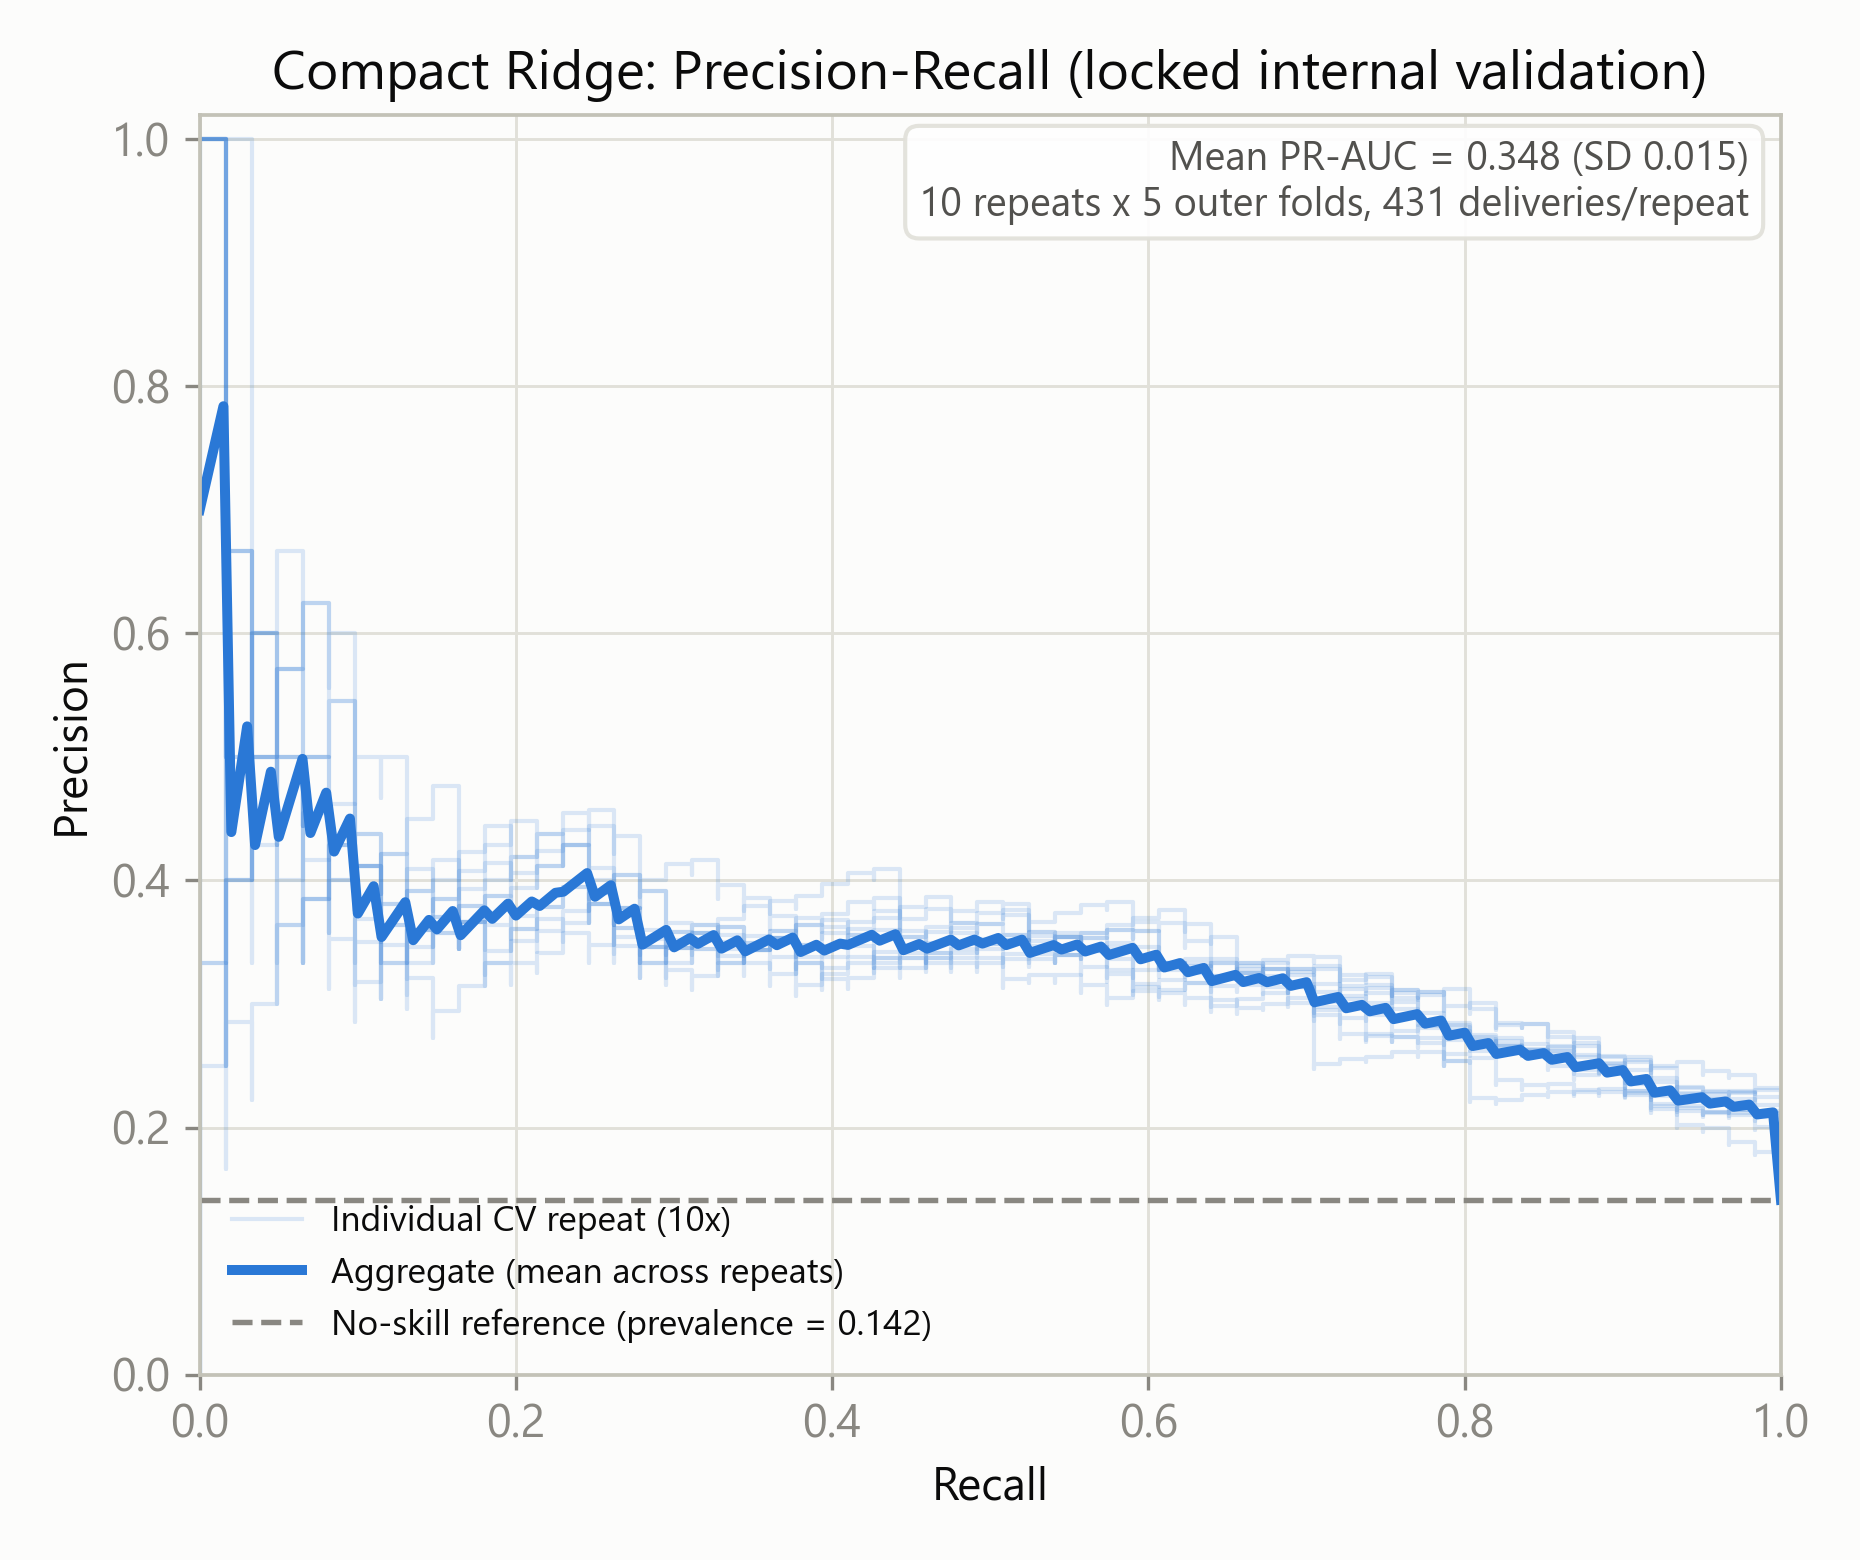

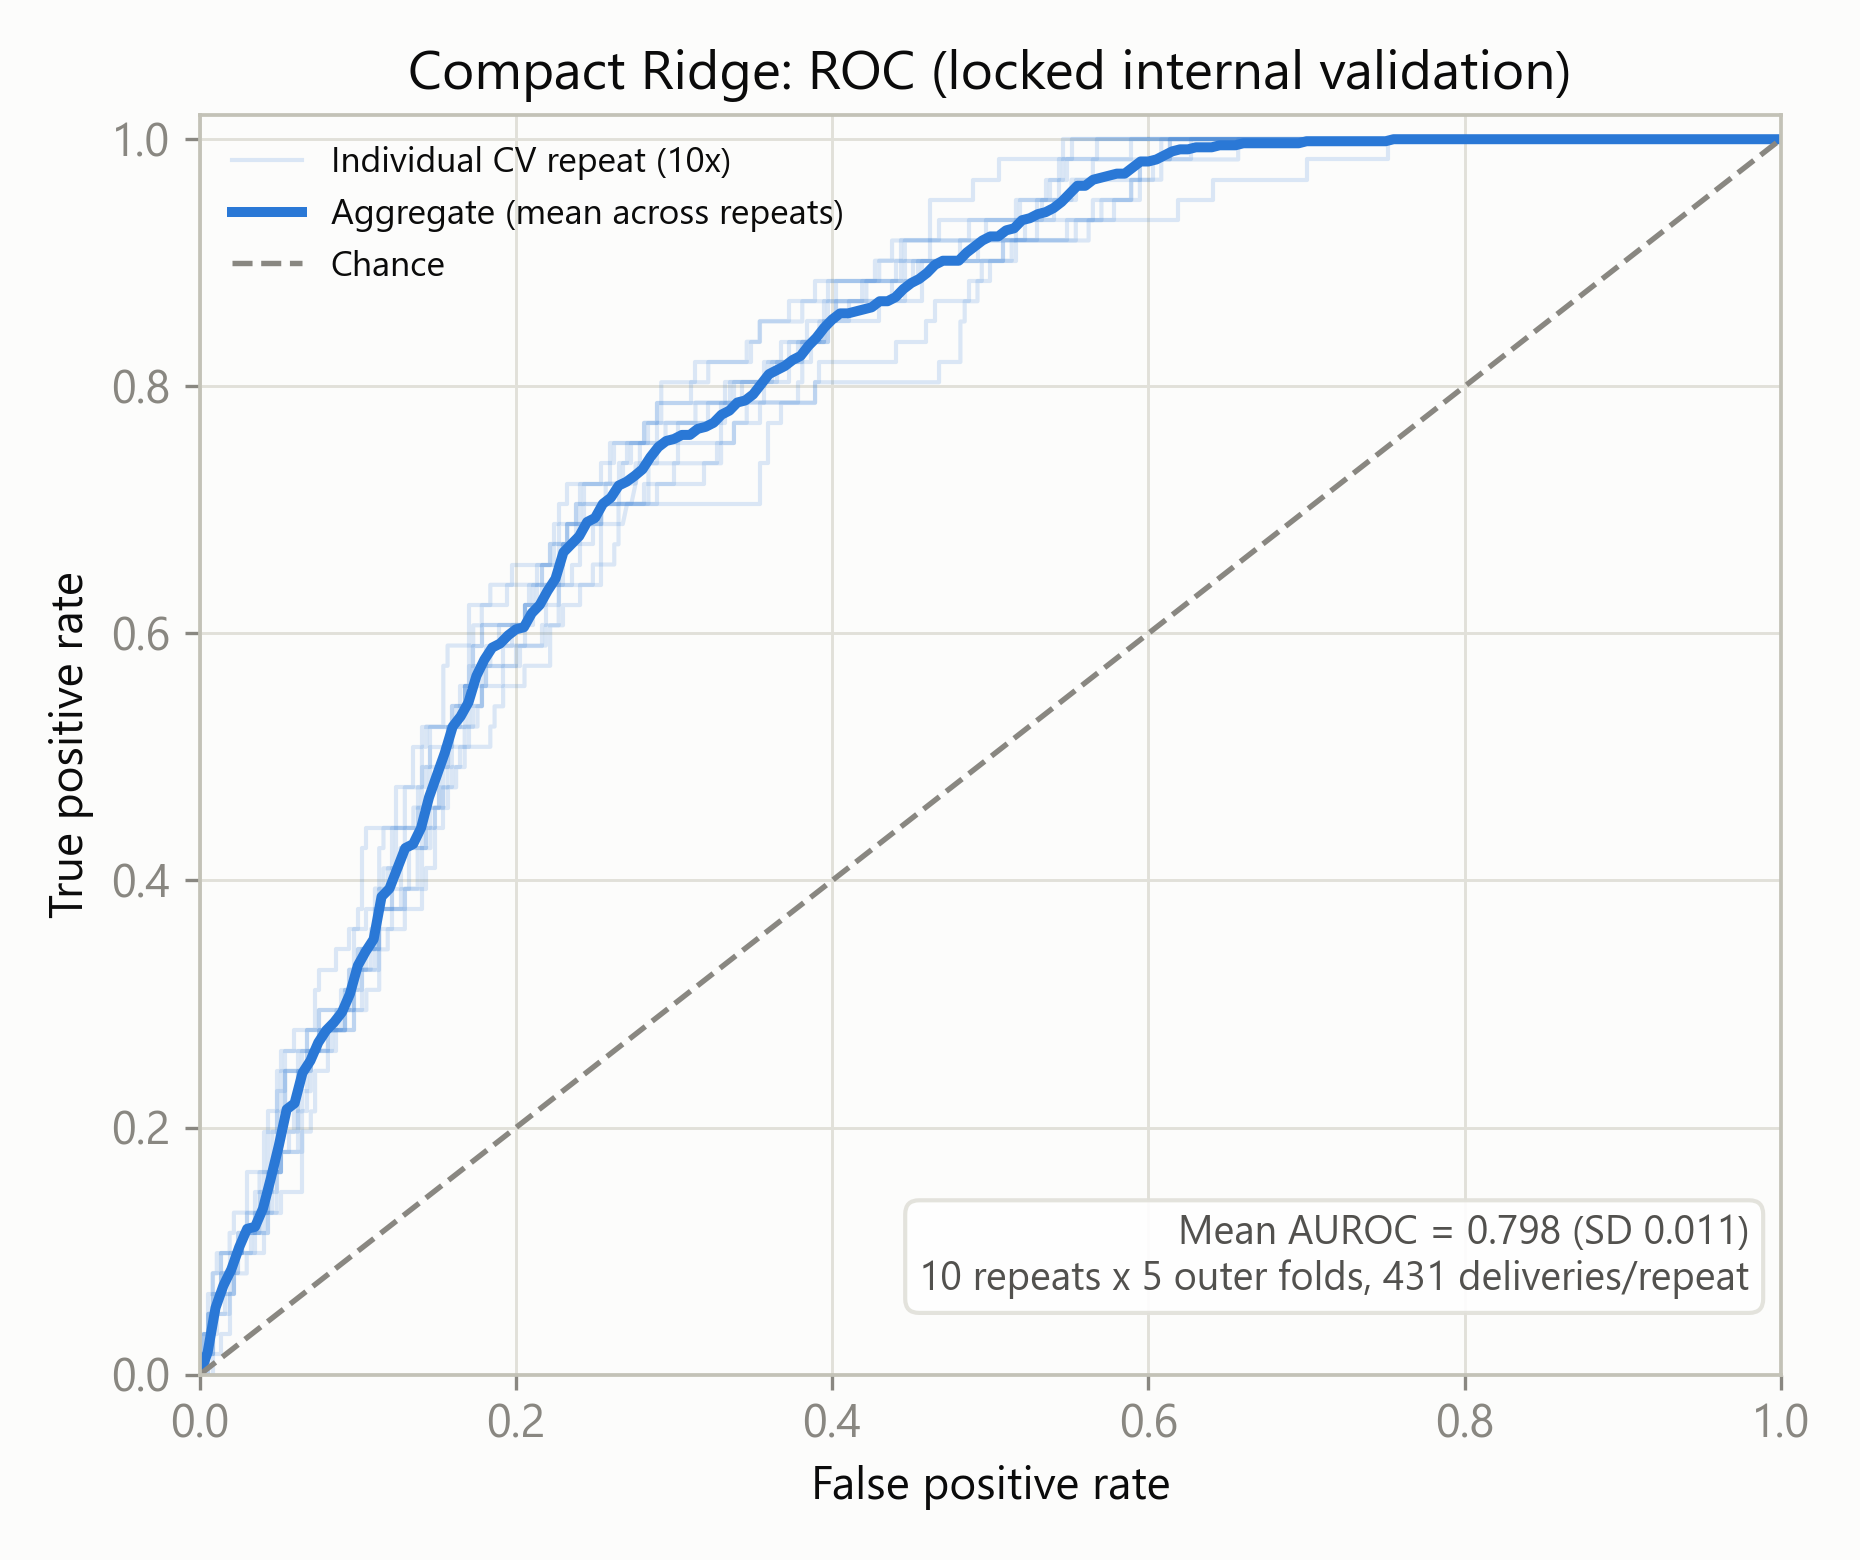

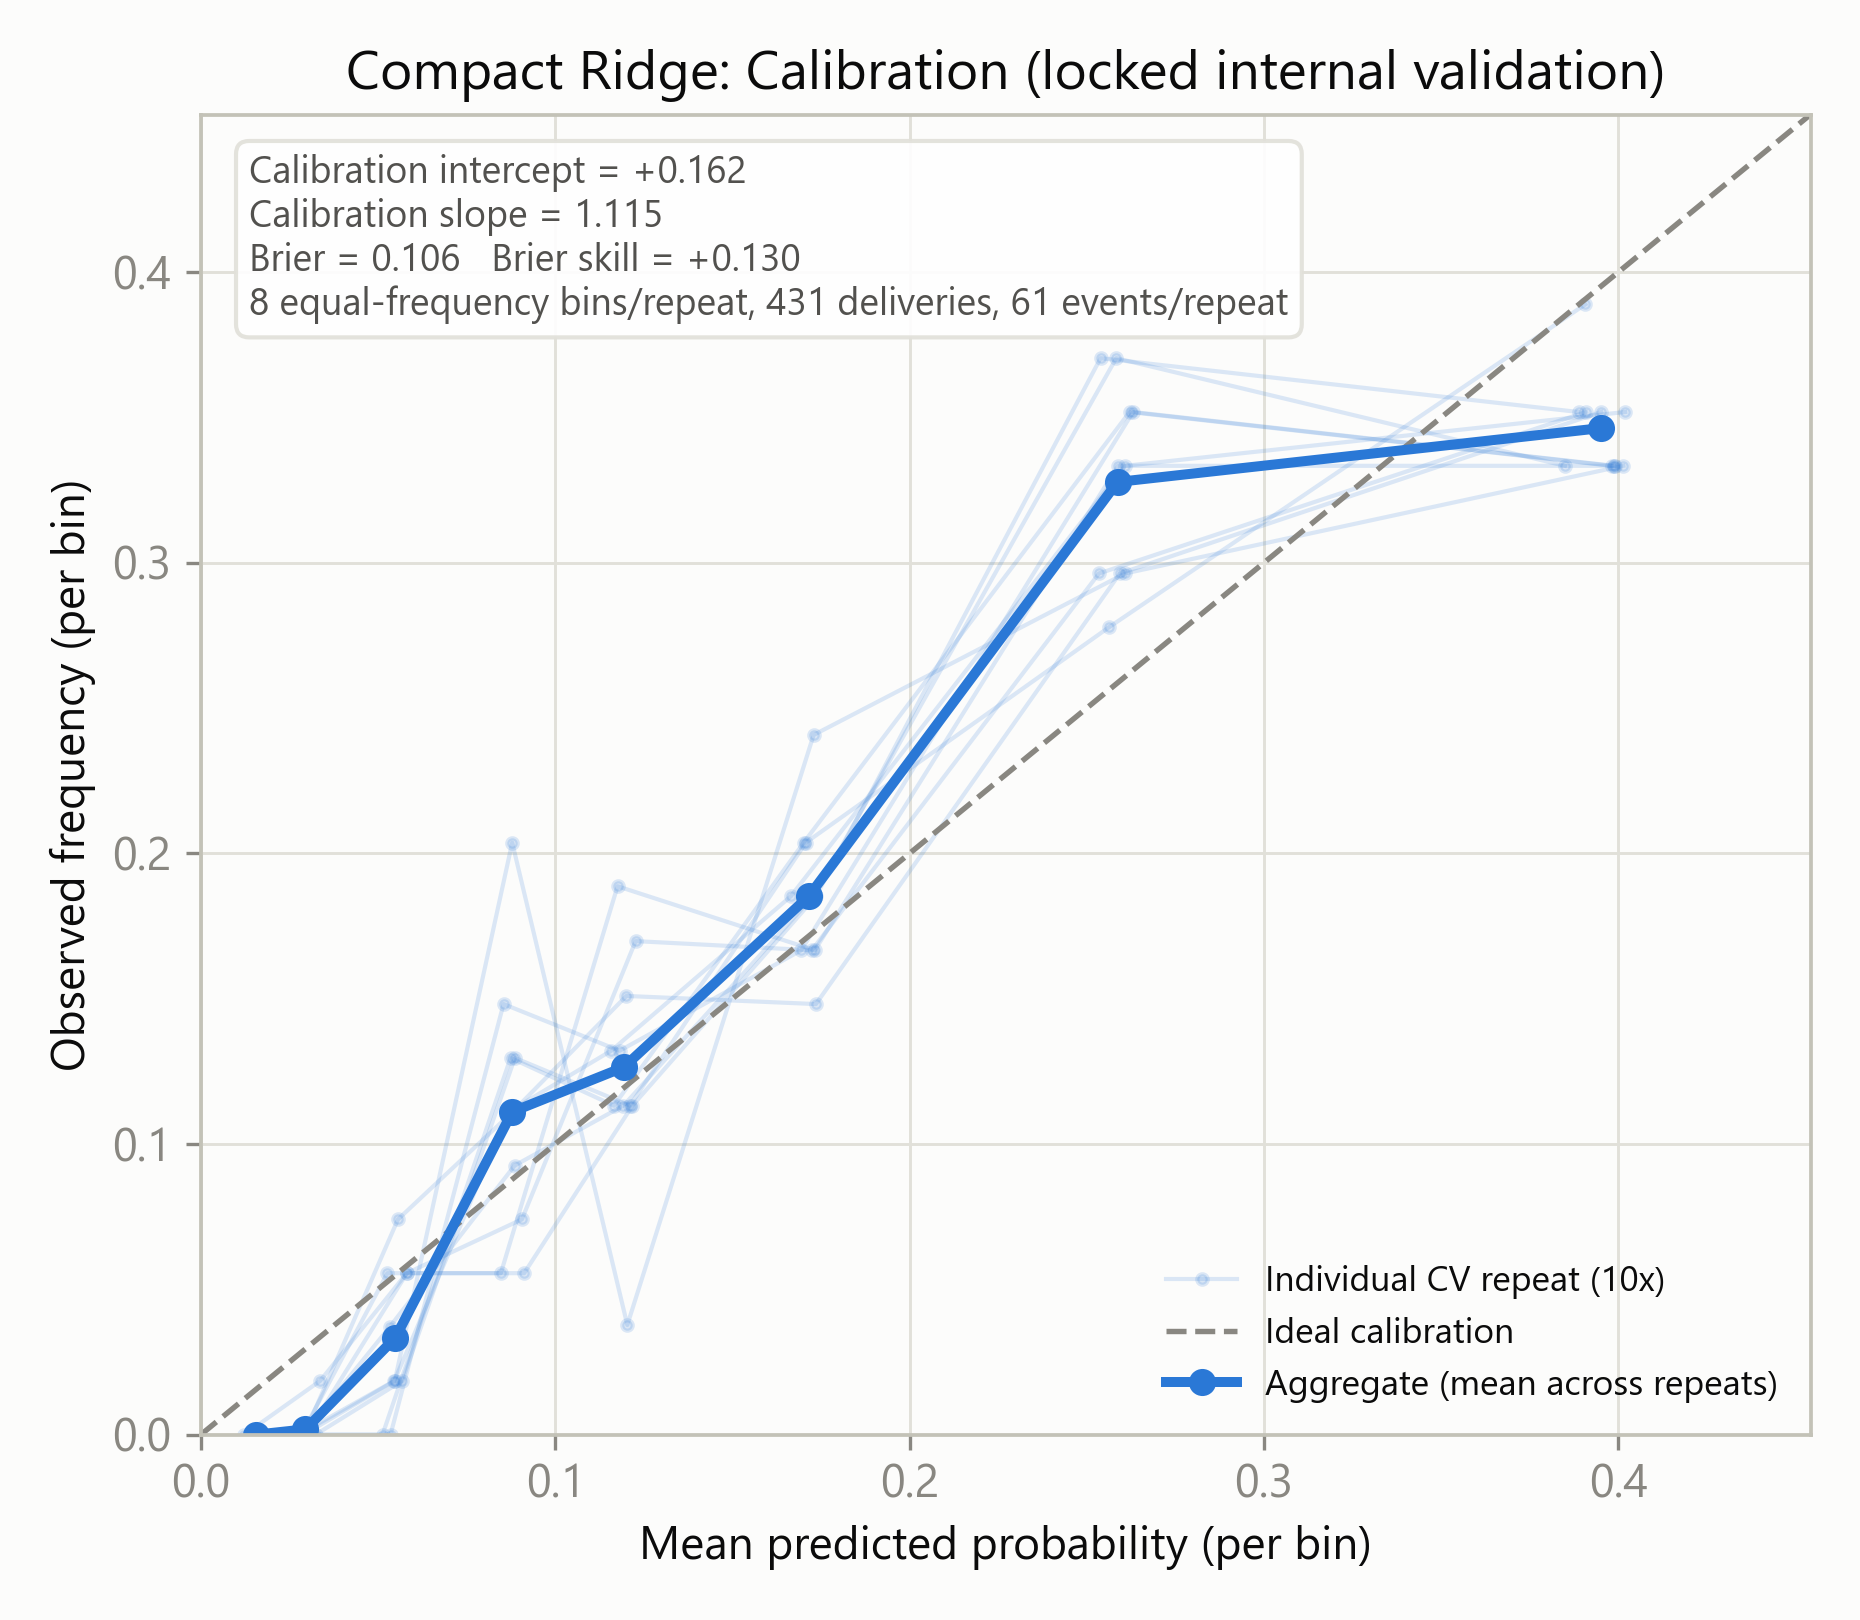

In [30]:
from IPython.display import Image

for figure_name in (
    "figure_compact_ridge_precision_recall.png",
    "figure_compact_ridge_roc.png",
    "figure_compact_ridge_calibration.png",
):
    figure_path = compact_ridge_final_dir / "figures" / figure_name
    if not figure_path.exists():
        raise FileNotFoundError(
            f"Version-controlled final Compact Ridge figure not found: {figure_path}."
        )
    display(Image(filename=str(figure_path)))

### Secondary clinically interpretable adjusted associations

The table and figure below are the already-generated, **accepted** outputs
of a separate, secondary descriptive analysis
(`analysis/reports/final_adjusted_or_analysis.py`) — read-only inputs to
this notebook, never recomputed here. This analysis fits one prespecified
ordinary (unpenalized) maximum-likelihood multivariable logistic regression
using the same six source predictors as the locked Decision 99 Compact
Ridge architecture (`AGE`, `nulliparity`, `S_P_CS`, `BMI_before`,
`derived_hypertension_pih_pet_spectrum`, `induction_any_bin`), to provide
clinically interpretable adjusted odds ratios (ORs) with 95% confidence
intervals in original clinical units.

- These are **ordinary unpenalized adjusted odds ratios** — not the
  penalized Compact Ridge coefficients shown above (which are on a
  standardized/encoded modeling scale and were tuned for predictive
  performance, not unbiased conditional-association estimation).
- They are a **secondary clinical-interpretation analysis**, distinct from
  the exploratory endometriosis-specific adjusted association analysis in
  Section F above (which adjusts one endometriosis exposure at a time for
  `AGE + nulliparity + S_P_CS`). Neither analysis is merged into, or
  replaces, the other.
- They do **not** alter Decision 99 or any reported predictive performance
  (PR-AUC, AUROC, Brier, calibration) — those remain exclusively sourced
  from the locked Ridge validation artifacts above.

In [31]:
adjusted_or_dir = compact_ridge_final_dir / "adjusted_or"

adjusted_or_table_md_path = adjusted_or_dir / "table_adjusted_odds_ratios.md"
if not adjusted_or_table_md_path.exists():
    raise FileNotFoundError(
        f"Accepted six-predictor adjusted-OR table not found: {adjusted_or_table_md_path}. "
        "This file is committed to the repository "
        "(see outputs/results/compact_ridge_final/adjusted_or/README.md) and must be present."
    )
print(f"Adjusted odds ratio table (accepted, version-controlled, read-only): "
      f"{adjusted_or_table_md_path}")
display(Markdown(adjusted_or_table_md_path.read_text(encoding="utf-8")))

Adjusted odds ratio table (accepted, version-controlled, read-only): <PROJECT_ROOT>\outputs\results\compact_ridge_final\adjusted_or\table_adjusted_odds_ratios.md


# Adjusted Odds Ratios: Six Compact Ridge Predictors

**Primary adjusted-association analysis, secondary to the predictive Compact Ridge model.** See `table_adjusted_odds_ratios_firth_sensitivity.md` for the prespecified Firth sparse-cell sensitivity analysis.

| Predictor | Comparison | Adjusted OR | 95% CI | Coefficient | SE | p-value | Reference |
|---|---|---|---|---|---|---|---|
| Age (per 1-year increase) | per 1-year increase | 1.137 | 1.065–1.212 | 0.1279 | 0.0329 | 0.0001 | n/a (continuous) |
| Nulliparous vs. non-nulliparous (prior birth) | nulliparous (1) vs. prior birth (0) | 8.367 | 3.331–21.017 | 2.1244 | 0.4699 | <0.0001 | 0 = non-nulliparous / prior birth |
| Prior cesarean vs. no prior cesarean | prior cesarean (1) vs. none (0) | 14.617 | 3.296–64.812 | 2.6822 | 0.7599 | 0.0004 | 0 = no prior cesarean |
| Pre-pregnancy BMI (per 1 kg/m² increase) | per 1 kg/m² increase | 0.989 | 0.929–1.053 | -0.0111 | 0.0320 | 0.7272 | n/a (continuous) |
| PIH / gestational hypertension vs. no hypertensive disorder | pih_gestational_htn vs. no_hypertensive_disorder | 2.151 | 0.382–12.108 | 0.7658 | 0.8817 | 0.3851 | no_hypertensive_disorder |
| Preeclampsia spectrum vs. no hypertensive disorder | preeclampsia_spectrum vs. no_hypertensive_disorder | 2.248 | 0.557–9.072 | 0.8099 | 0.7119 | 0.2553 | no_hypertensive_disorder |
| Labor induction vs. no induction | induction (1) vs. none (0) | 6.006 | 2.873–12.557 | 1.7928 | 0.3763 | <0.0001 | 0 = no induction |

Source variable names (source-level, matching the locked Ridge frozen-predictor list): AGE, BMI_before, S_P_CS, derived_hypertension_pih_pet_spectrum, induction_any_bin, nulliparity.

Ordinary (unpenalized) maximum-likelihood multivariable logistic regression; all six predictors entered together (n = 431, 61 events). AOR = exp(coefficient); 95% CI = exp(Wald confidence interval on the coefficient). `BMI_before` uses the corrected component-level reconstruction (see README) -- not direct median imputation.

> This is a secondary, prespecified descriptive association analysis. It is not the predictive Compact Ridge model, not a causal model, and not a variable-selection exercise. Do not infer causality from these odds ratios.


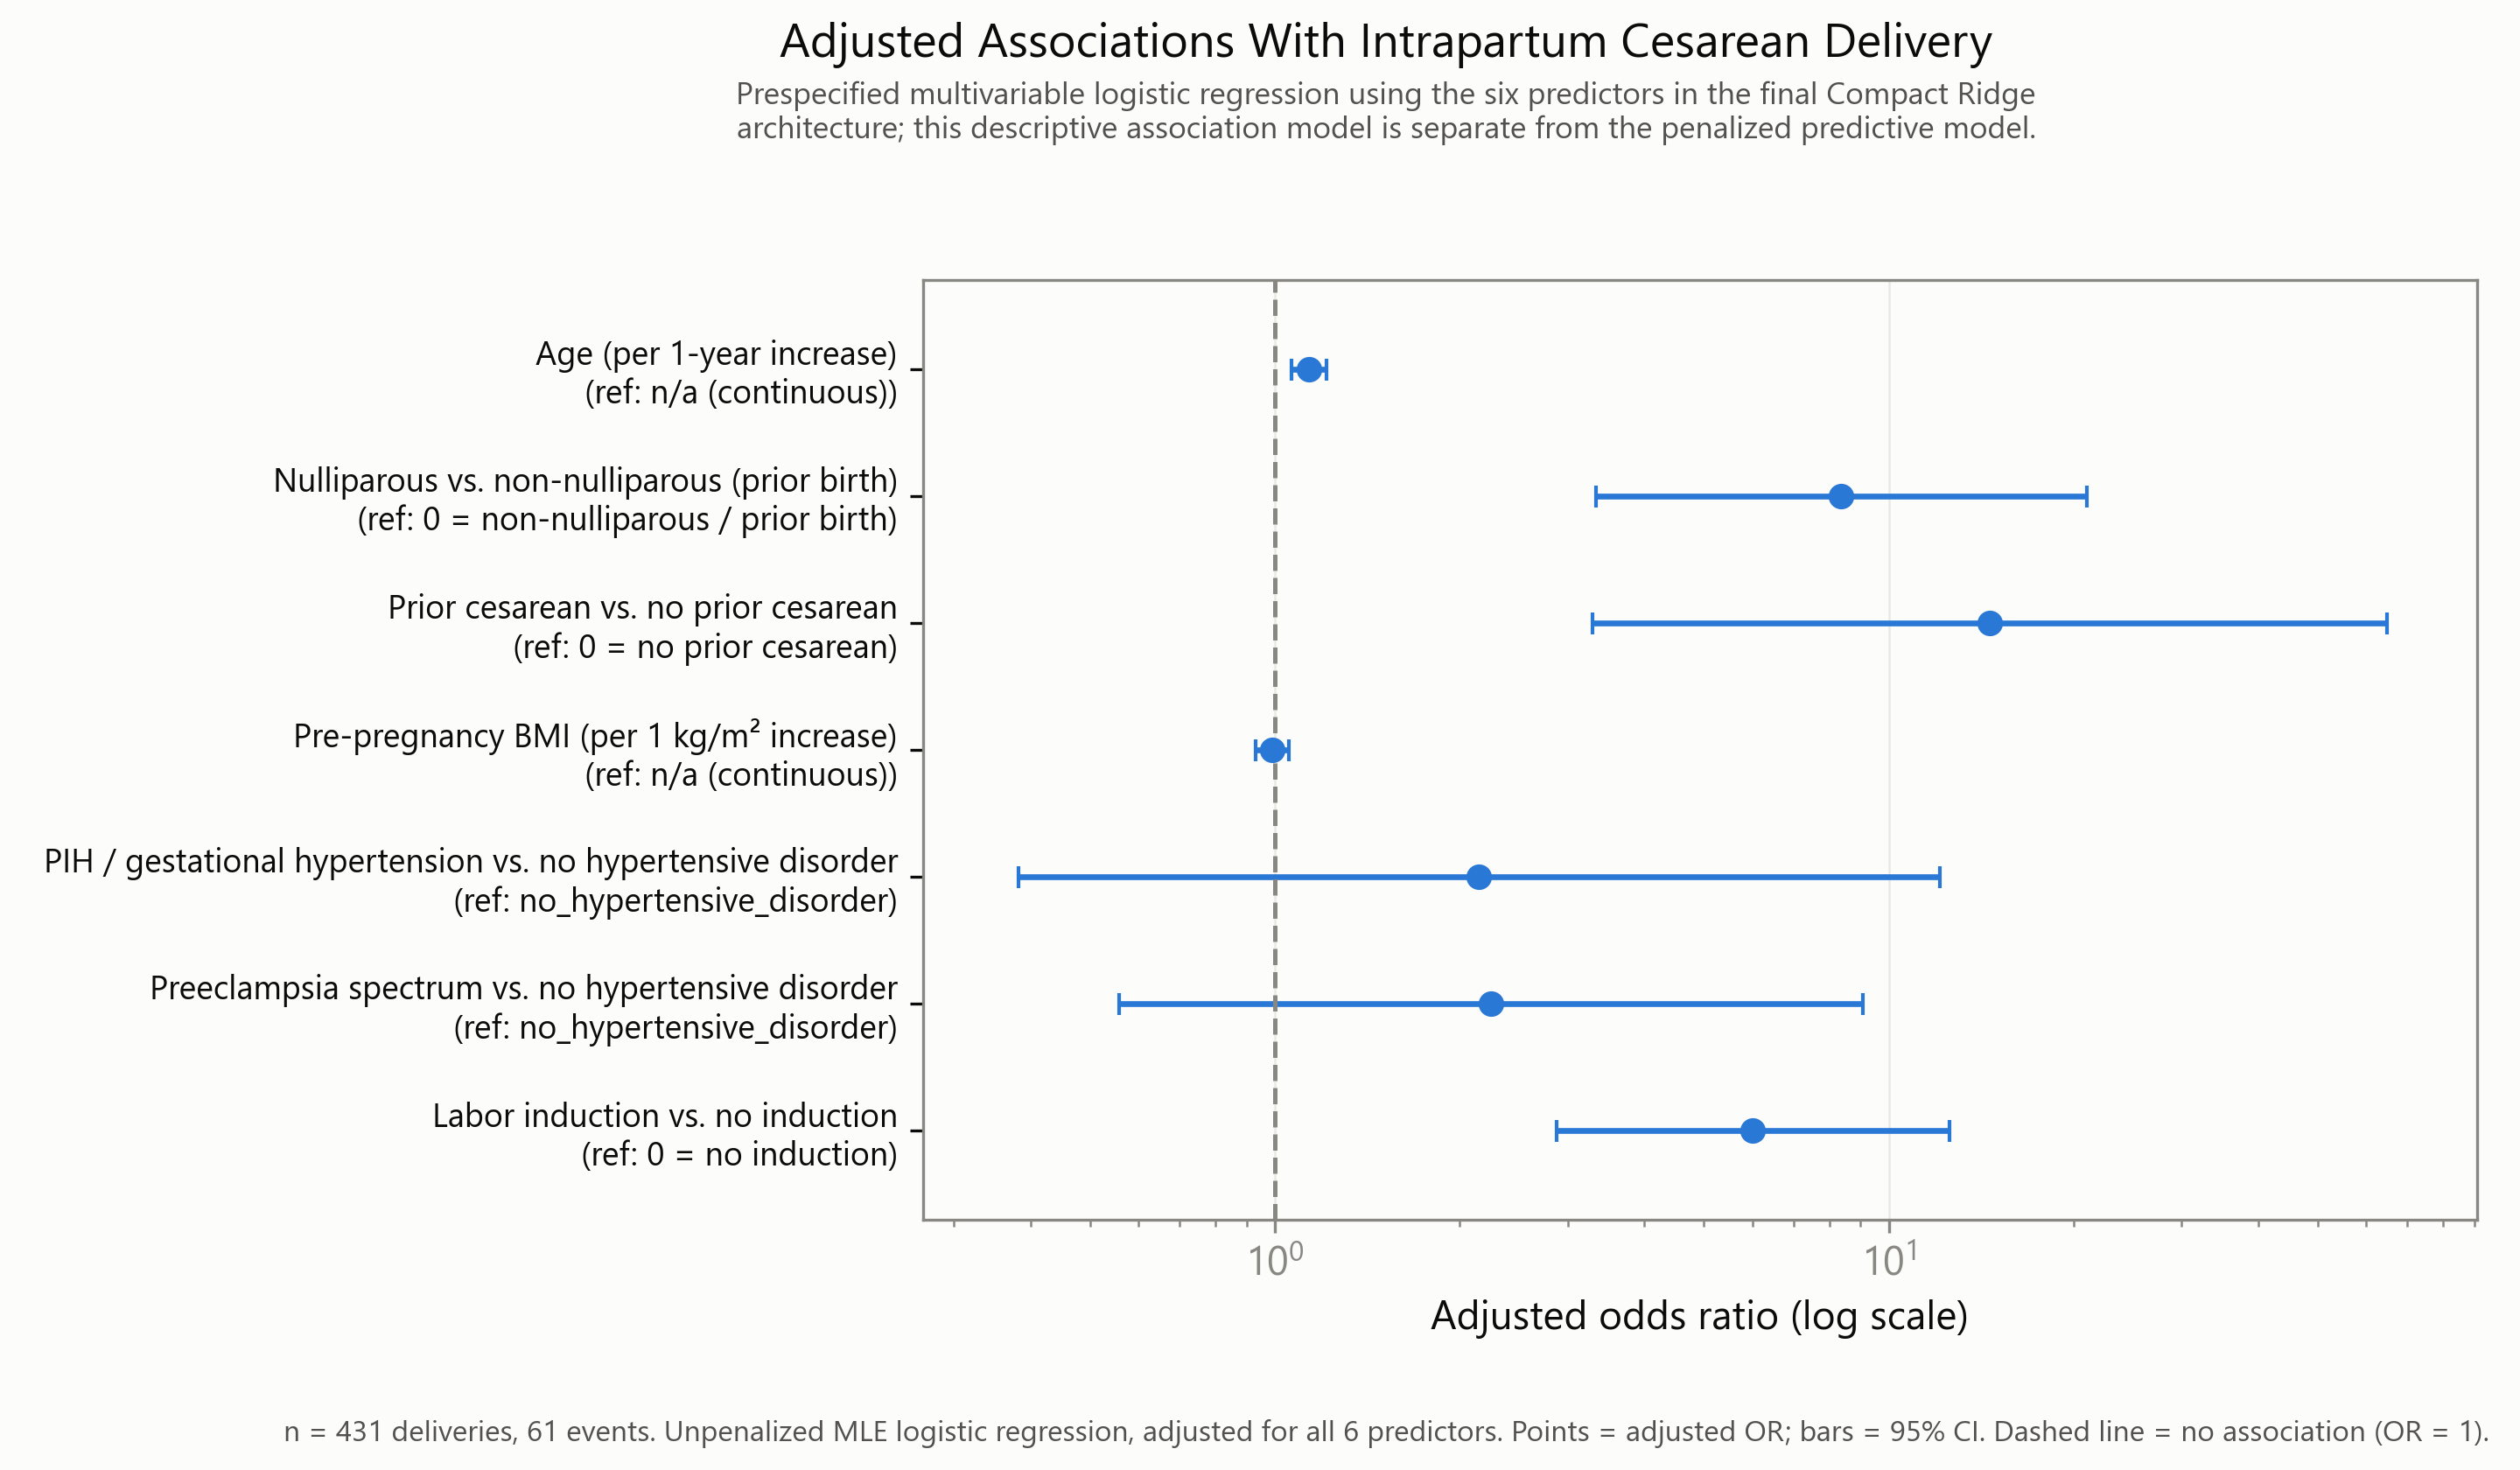

In [32]:
adjusted_or_figure_path = adjusted_or_dir / "figure_adjusted_odds_ratios.png"
if not adjusted_or_figure_path.exists():
    raise FileNotFoundError(
        f"Accepted adjusted-OR forest figure not found: {adjusted_or_figure_path}."
    )
display(Image(filename=str(adjusted_or_figure_path)))

In [33]:
# Firth (bias-reduced penalized-likelihood) sensitivity analysis, fit on the
# identical design because two hypertension categories are sparse-celled.
# MLE remains the PRIMARY adjusted-OR model above; this cell surfaces only
# the accepted verdict text, never a second forest plot, and is never
# recomputed here.
adjusted_or_readme_path = adjusted_or_dir / "README.md"
if not adjusted_or_readme_path.exists():
    raise FileNotFoundError(f"Accepted adjusted-OR README not found: {adjusted_or_readme_path}.")
_adjusted_or_readme_text = adjusted_or_readme_path.read_text(encoding="utf-8")
_verdict_marker = "Overall sensitivity verdict:"
_verdict_line = next(
    (line for line in _adjusted_or_readme_text.splitlines() if _verdict_marker in line),
    None,
)
if _verdict_line is None:
    raise ValueError(
        f"Could not locate '{_verdict_marker}' in {adjusted_or_readme_path}."
    )
print("Firth sensitivity analysis (identical six-predictor design, sparse-cell trigger):")
print(_verdict_line.strip())
print("MLE remains the primary adjusted-OR model; Firth is sensitivity only — "
      "see table_adjusted_odds_ratios_firth_sensitivity.md for the supplementary table.")

adjusted_or_firth_table_md_path = adjusted_or_dir / "table_adjusted_odds_ratios_firth_sensitivity.md"
if adjusted_or_firth_table_md_path.exists():
    display(Markdown(adjusted_or_firth_table_md_path.read_text(encoding="utf-8")))

Firth sensitivity analysis (identical six-predictor design, sparse-cell trigger):
**Overall sensitivity verdict: `ROBUST — NO MATERIAL INTERPRETIVE CHANGE`**
MLE remains the primary adjusted-OR model; Firth is sensitivity only — see table_adjusted_odds_ratios_firth_sensitivity.md for the supplementary table.


# Firth Logistic Regression Sensitivity Analysis

**Prespecified sparse-cell sensitivity analysis for the six Compact Ridge predictors. Not the primary adjusted-OR model (see `table_adjusted_odds_ratios.md`) and not the predictive Compact Ridge model.**

| Predictor | Comparison | Firth adjusted OR | 95% CI (Wald) | Firth coefficient | SE | p-value (PLR) | Reference |
|---|---|---|---|---|---|---|---|
| Age (per 1-year increase) | per 1-year increase | 1.131 | 1.061–1.205 | 0.1228 | 0.0323 | 0.0001 | n/a (continuous) |
| Nulliparous vs. non-nulliparous (prior birth) | nulliparous (1) vs. prior birth (0) | 7.566 | 3.131–18.284 | 2.0236 | 0.4502 | <0.0001 | 0 = non-nulliparous / prior birth |
| Prior cesarean vs. no prior cesarean | prior cesarean (1) vs. none (0) | 13.942 | 3.299–58.929 | 2.6349 | 0.7354 | 0.0008 | 0 = no prior cesarean |
| Pre-pregnancy BMI (per 1 kg/m² increase) | per 1 kg/m² increase | 0.991 | 0.932–1.054 | -0.0090 | 0.0315 | 0.7717 | n/a (continuous) |
| PIH / gestational hypertension vs. no hypertensive disorder | pih_gestational_htn vs. no_hypertensive_disorder | 2.161 | 0.389–11.991 | 0.7704 | 0.8744 | 0.3602 | no_hypertensive_disorder |
| Preeclampsia spectrum vs. no hypertensive disorder | preeclampsia_spectrum vs. no_hypertensive_disorder | 2.291 | 0.576–9.122 | 0.8291 | 0.7049 | 0.2343 | no_hypertensive_disorder |
| Labor induction vs. no induction | induction (1) vs. none (0) | 5.665 | 2.762–11.619 | 1.7343 | 0.3665 | <0.0001 | 0 = no induction |

Firth (1993) bias-reduced penalized-likelihood logistic regression; same 431-row cohort, same 61-event outcome, same seven slope parameters, same treatment/reference coding as the primary MLE model. 95% CI = Wald-type confidence interval based on the inverse expected Fisher information evaluated at the converged Firth estimate. p-value = penalized likelihood-ratio (PLR) test (2x log-likelihood difference vs. the model refit with that parameter fixed at 0, chi-square(1)) -- not a Wald test on the Firth estimate, which is unreliable in exactly this sparse-cell regime.

> This is a prespecified SENSITIVITY analysis, triggered by genuine small-cell sparsity in the hypertension categories (pih_gestational_htn: n=8, 3 events; preeclampsia_spectrum: n=11, 4 events). It does not replace the ordinary MLE as the primary adjusted-association model. Do not infer causality from these odds ratios.


---
## Section I — Figures

Forest plots with a reference line at OR = 1, a logarithmic OR axis, and
visible confidence intervals. A row is plotted as an OR point only when it
has a finite OR, finite CI, AND `fit_status == OK`. Every other row is
classified into exactly one of two distinct sidebars (never conflated) via
`figures.classify_forest_rows`: `NO_SINGLE_OR` — a categorical source-level
omnibus row or a nonlinear-spline source row, a genuinely estimable
association with no legitimate single OR by construction, reported as "No
single OR — source-level omnibus/nonlinear result; see table" — and
`NOT_ESTIMABLE` — a Class C (`NOT_FITTED`) exposure or any other genuinely
failed/unsupported fit. Neither is ever given a fabricated point. Categorical
LEVEL rows are labeled `"{clinical predictor label}: {level} vs
{reference_level}"` using the clinical display-label layer
(`publication_display_labels.py`; the technical predictor/exposure column is
kept alongside, untouched, for traceability). Long predictor lists are split
into logically grouped figures (by domain) rather than compressed into one
unreadable plot. Every figure is saved to disk first, then re-displayed
inline via `exports.display_saved_figure` (`IPython.display.Image` on the
saved PNG bytes) — backend-independent, so a headless plotting backend never
silently degrades the notebook's inline output to a text-only `Figure(...)`
repr.

In [34]:
from analysis.publication_analysis import publication_figures as figures
from analysis.publication_analysis import publication_display_labels

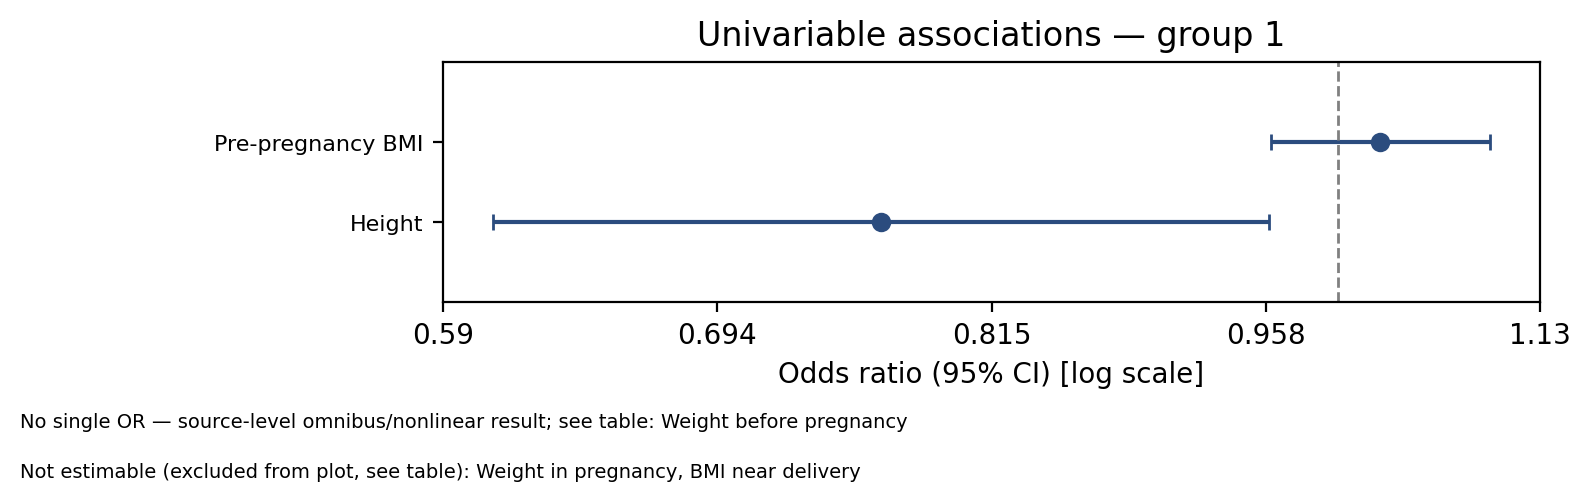

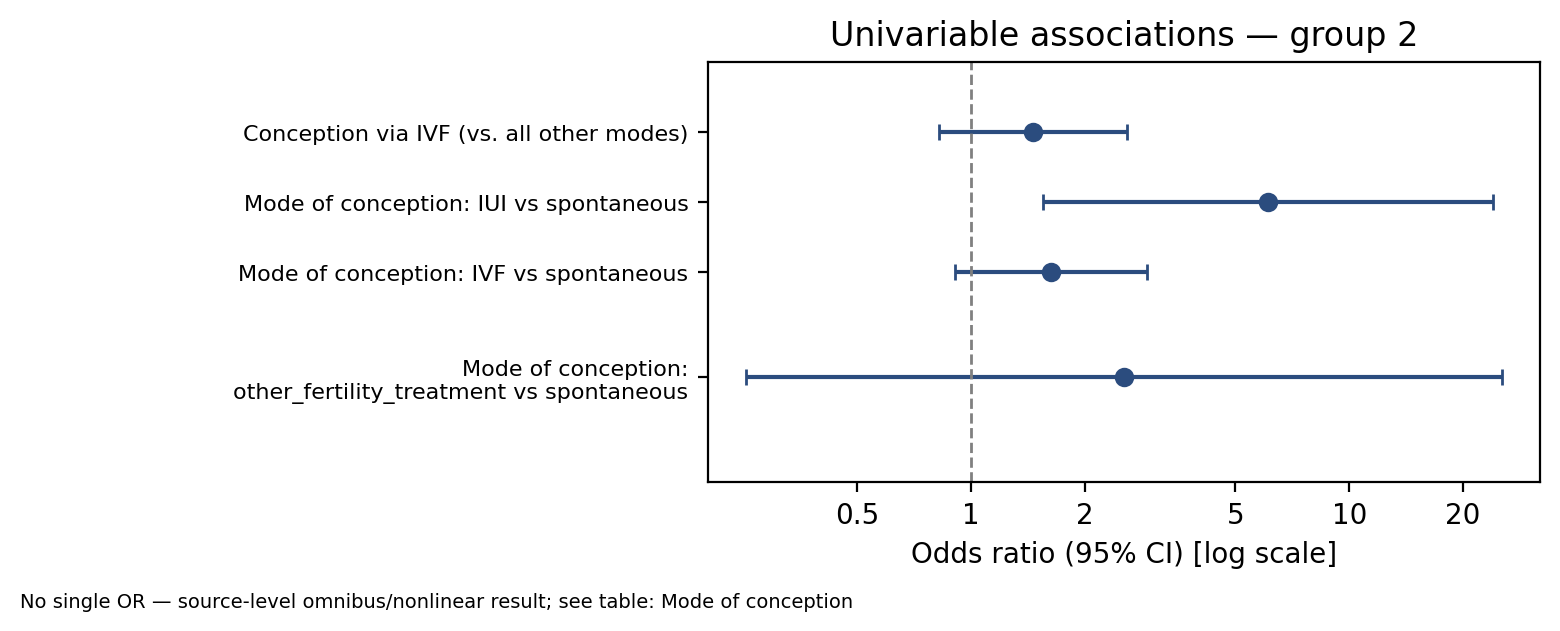

<PROJECT_ROOT>\.venv312\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


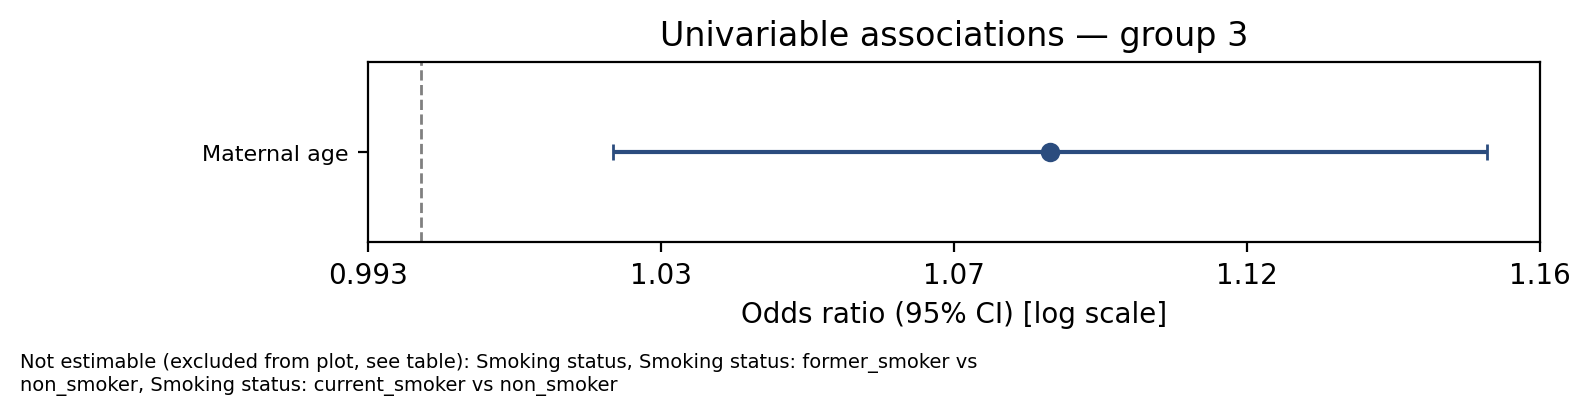

Univariable associations — group 4: No plottable single-OR estimate in this group -- see the results table above for exact values (not estimable: Diabetes type (grouped: pregestational vs. gestational), Diabetes type (grouped: pregestational vs. gestational): pregestational vs no_diabetes, Diabetes type (grouped: pregestational vs. gestational): GDMA1 vs no_diabetes, Diabetes type (grouped: pregestational vs. gestational): GDMA2 vs no_diabetes).


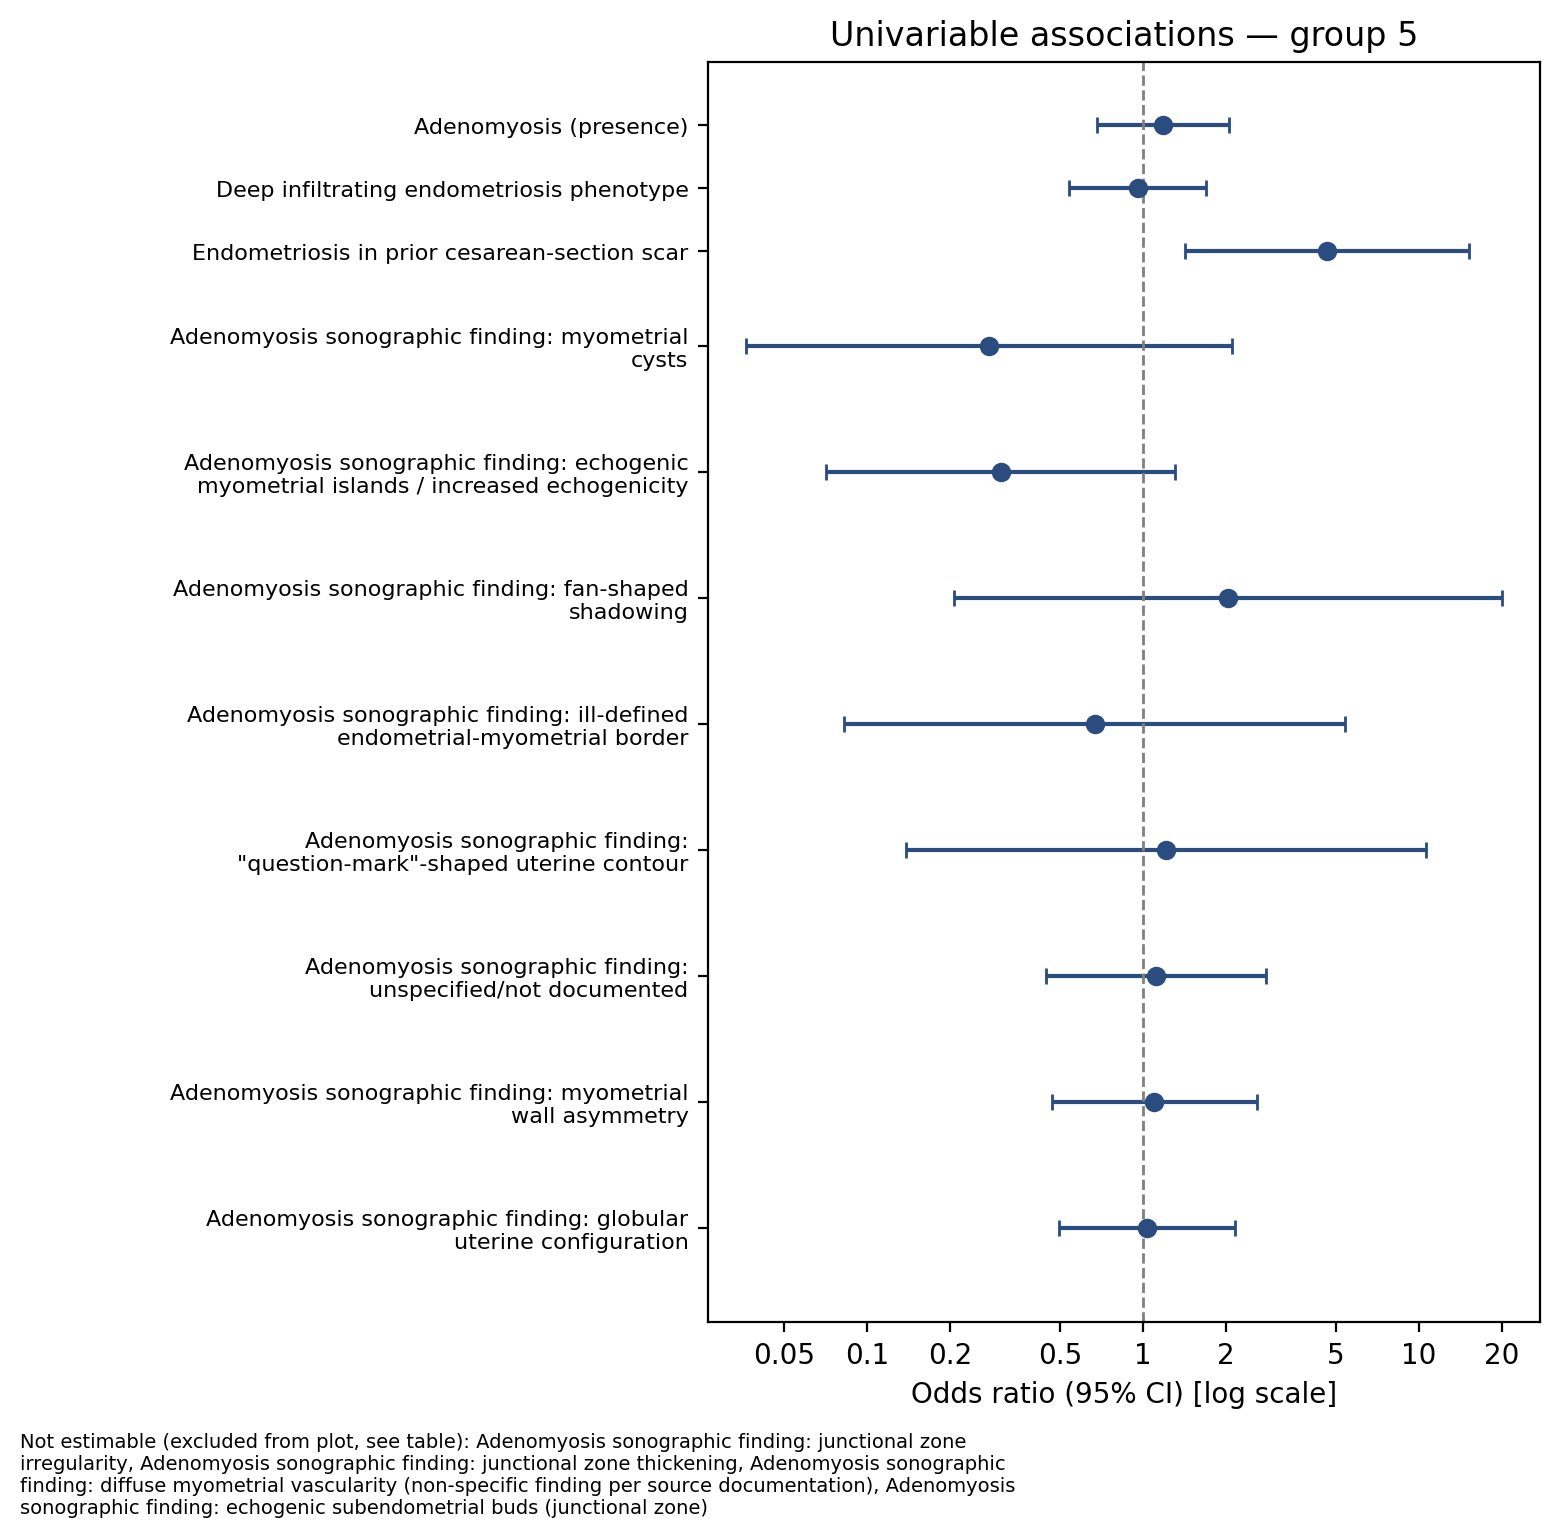

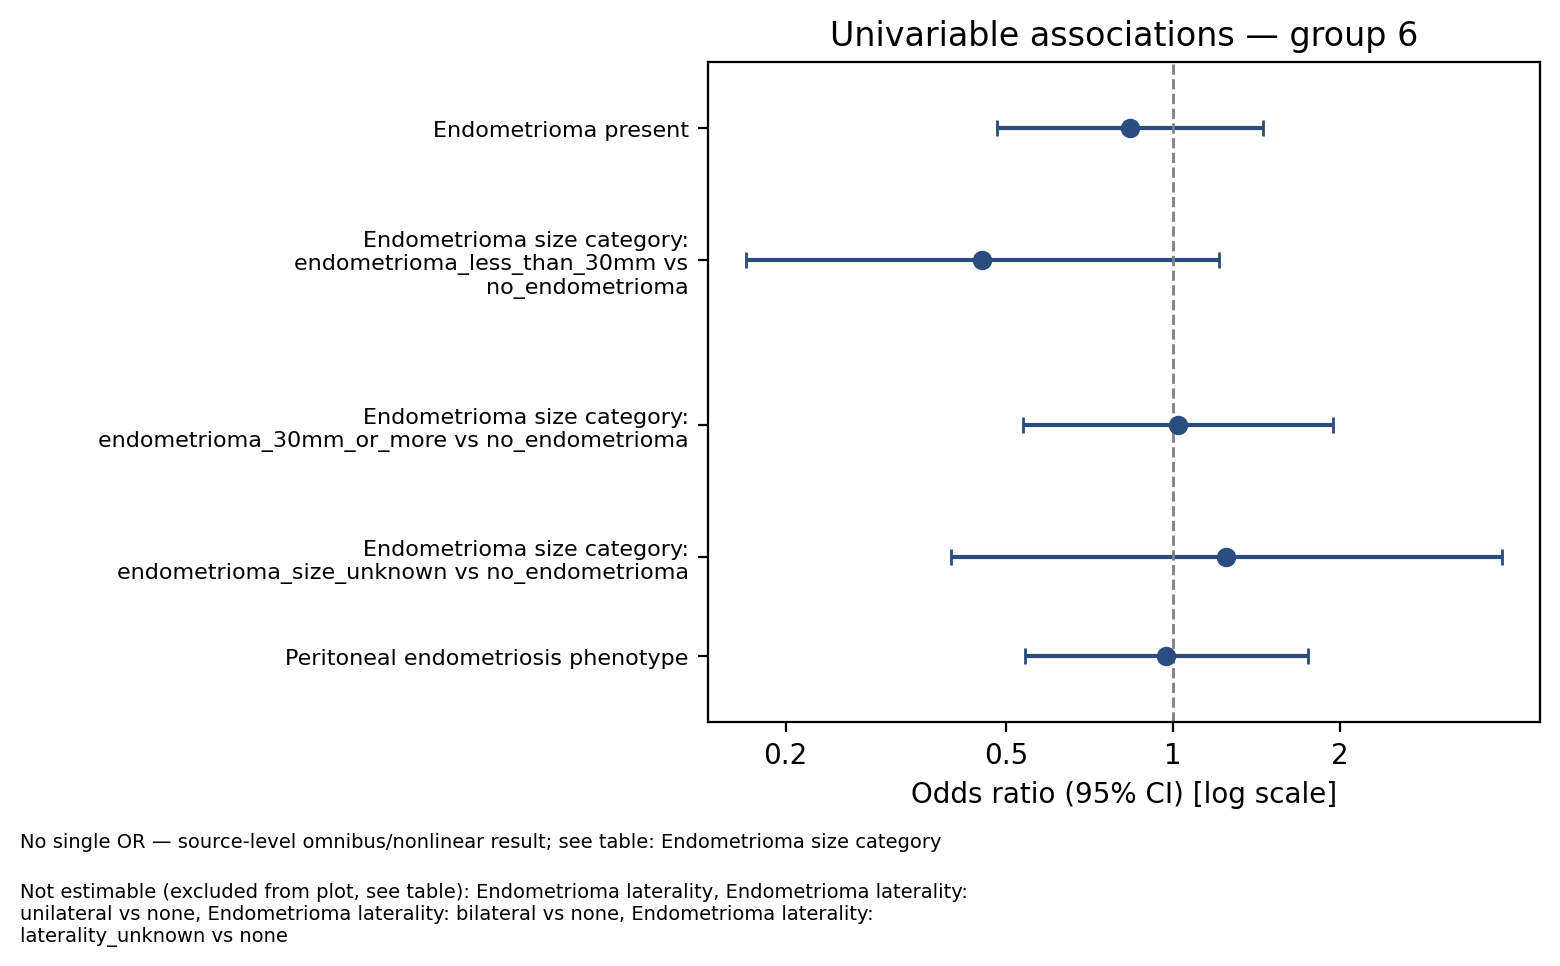

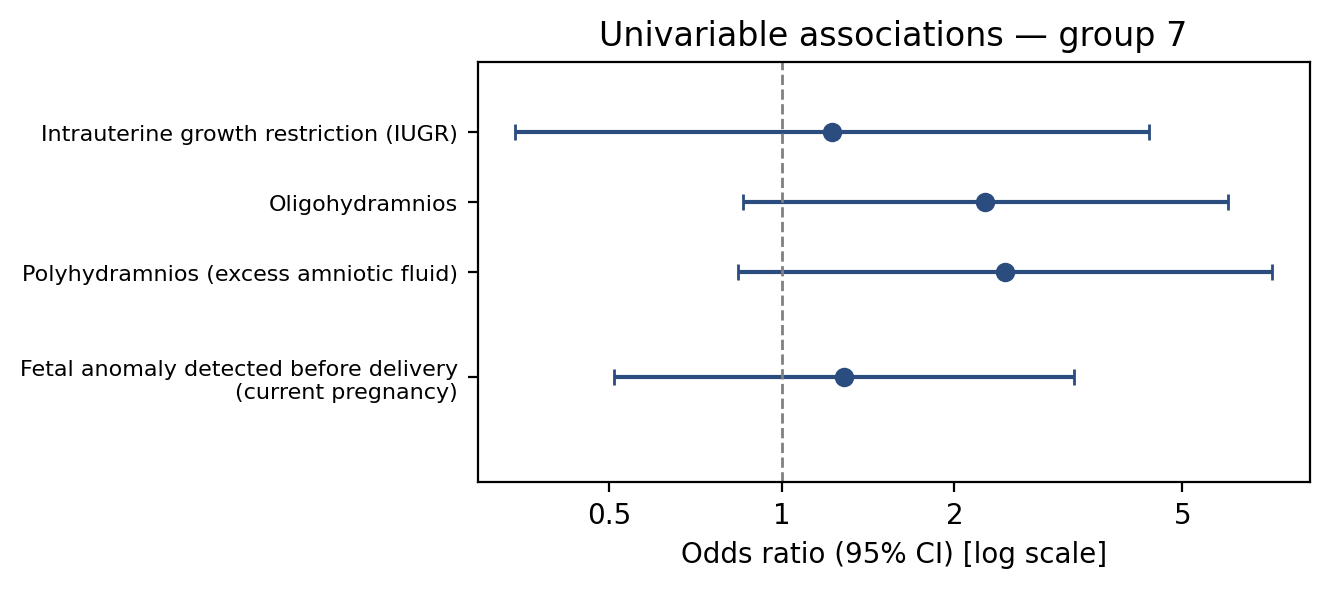

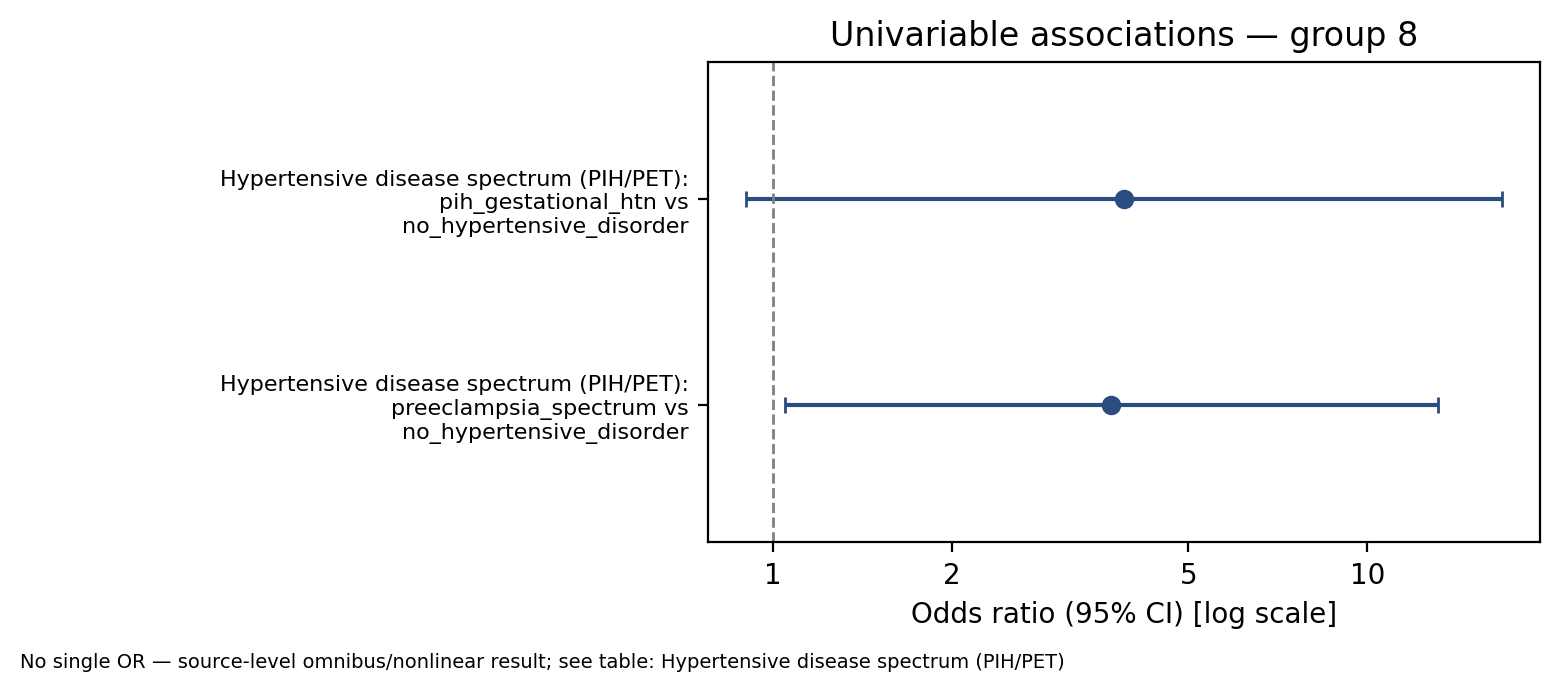

Univariable associations — group 9: No plottable single-OR estimate in this group -- see the results table above for exact values (not estimable: Indication for labor induction).


<PROJECT_ROOT>\.venv312\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


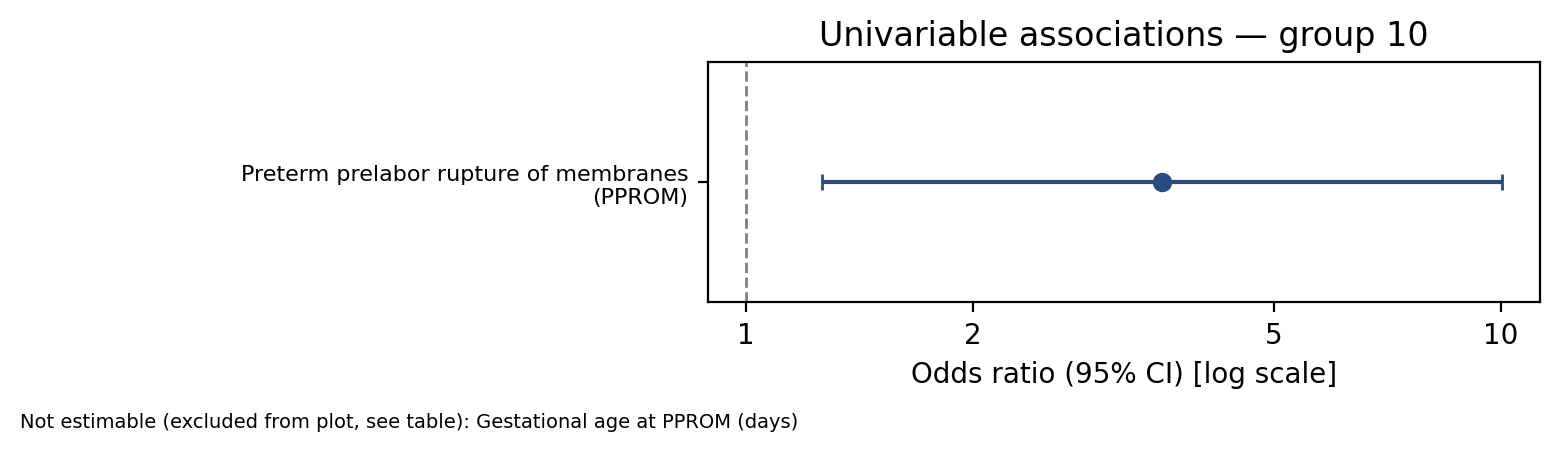

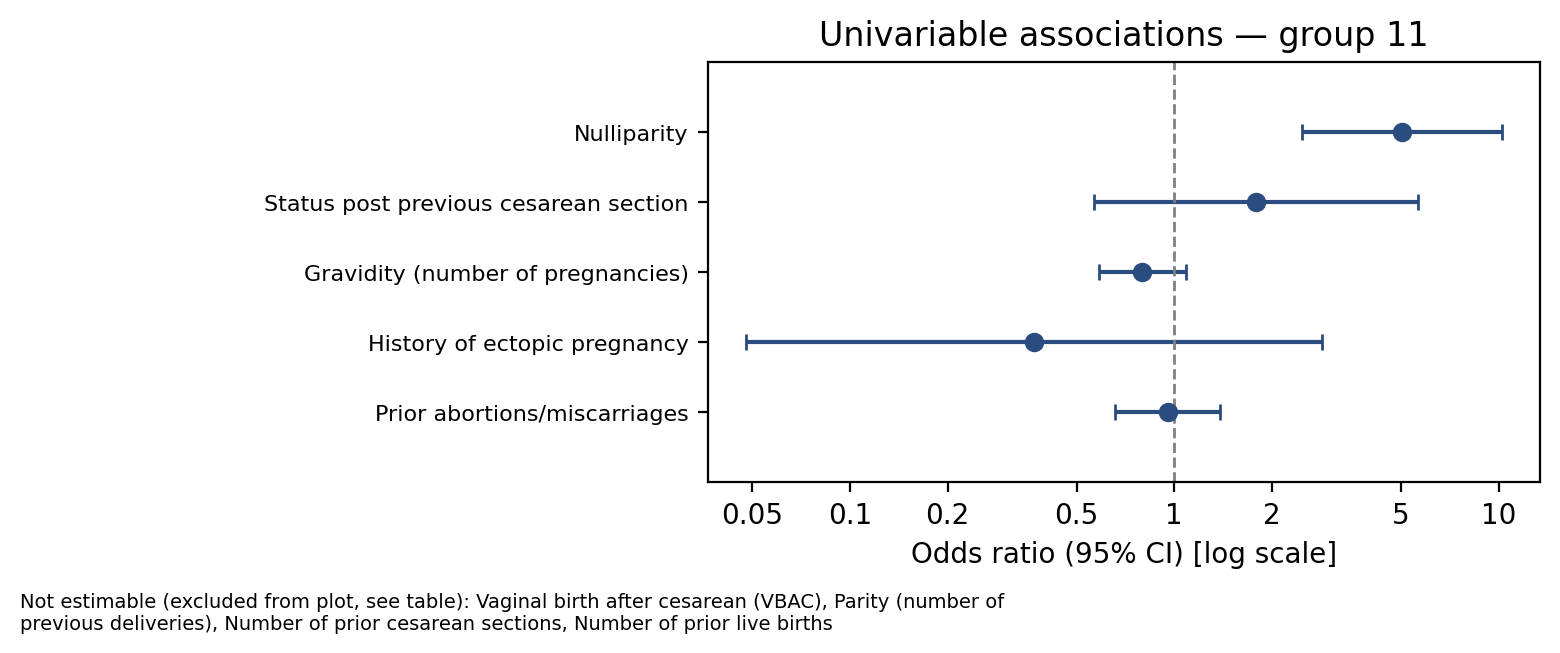

<PROJECT_ROOT>\.venv312\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


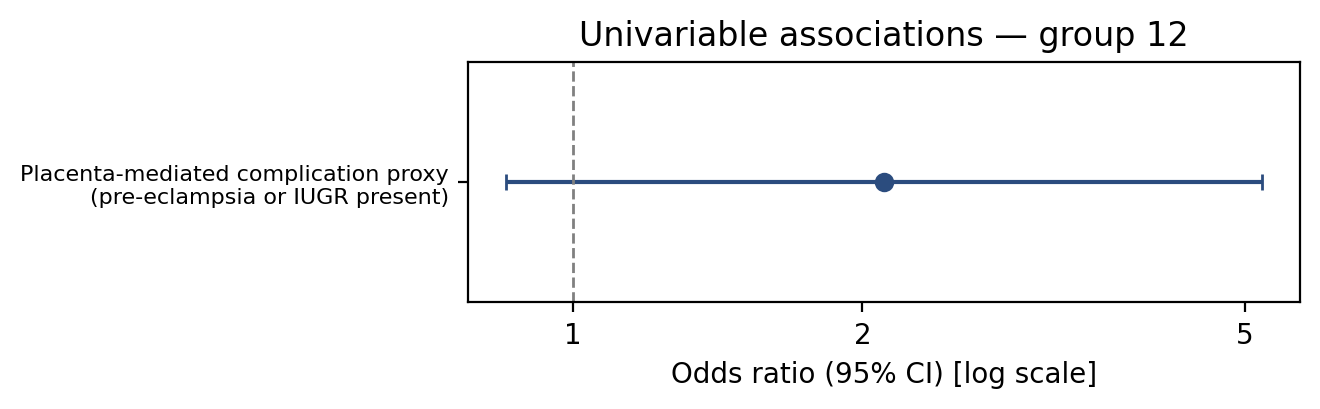

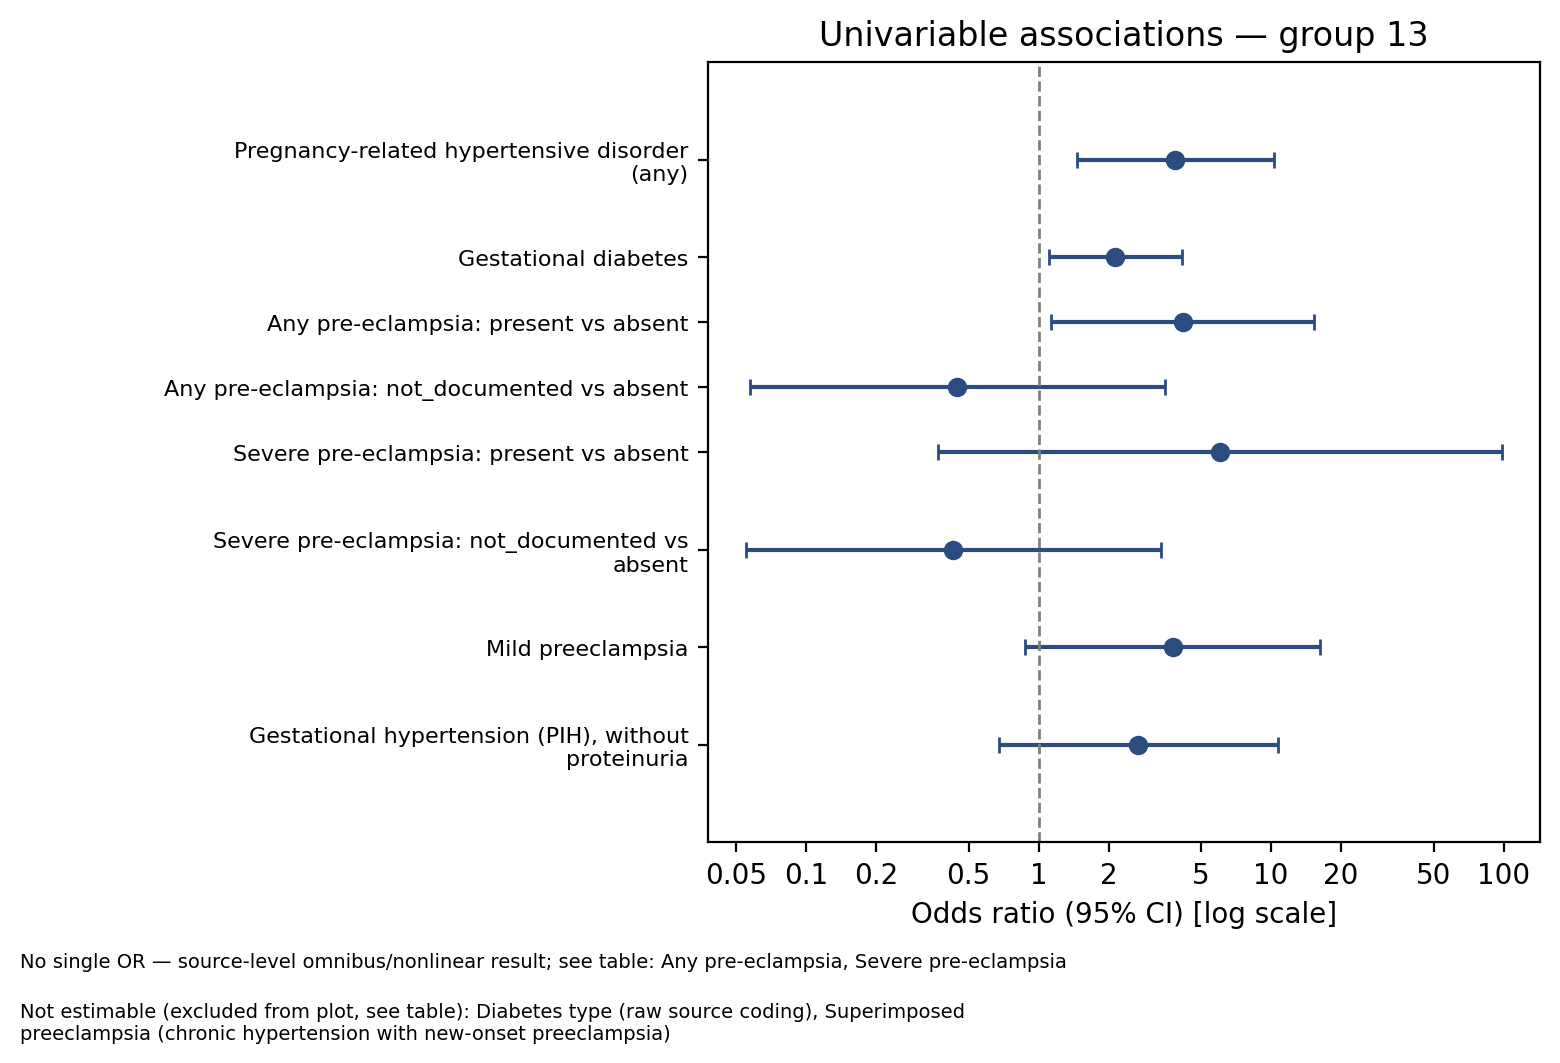

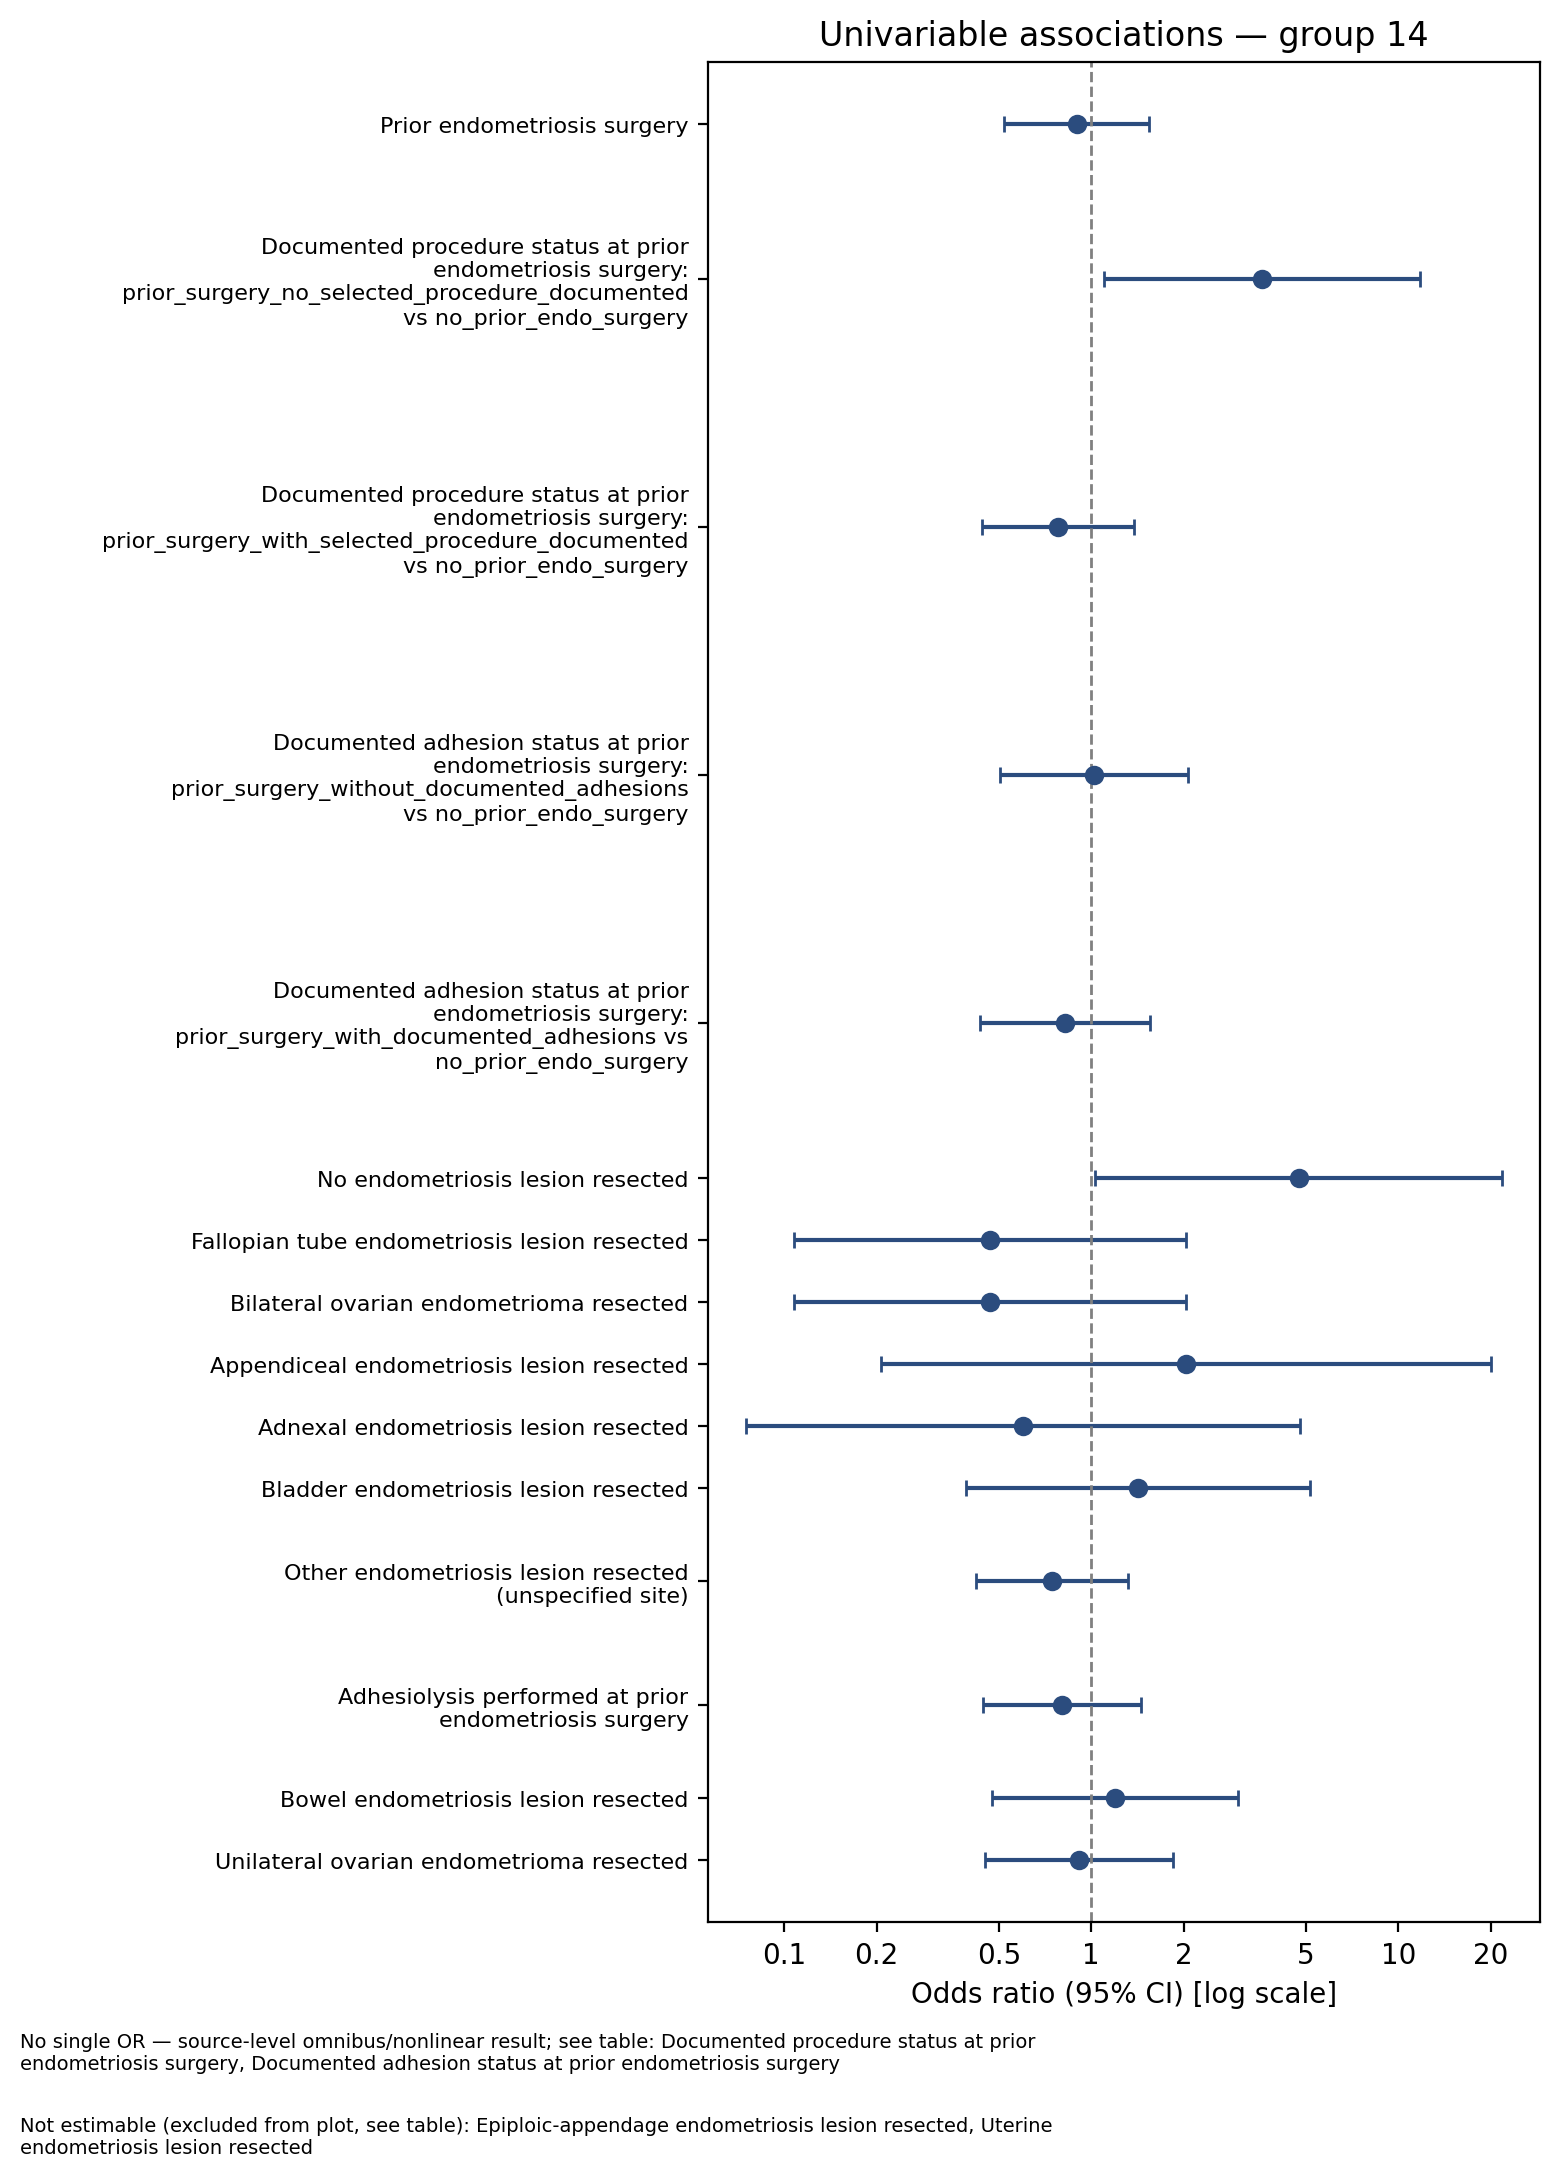

<PROJECT_ROOT>\.venv312\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


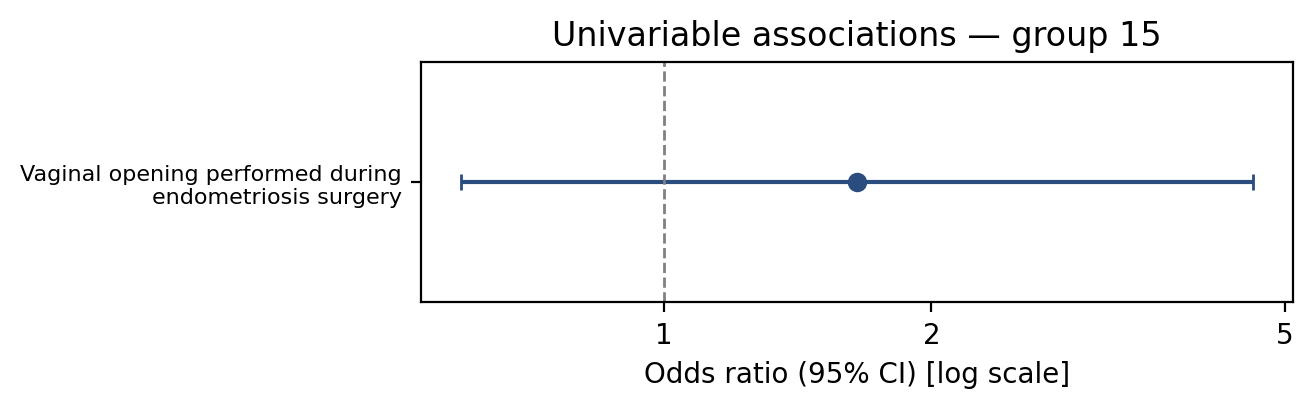

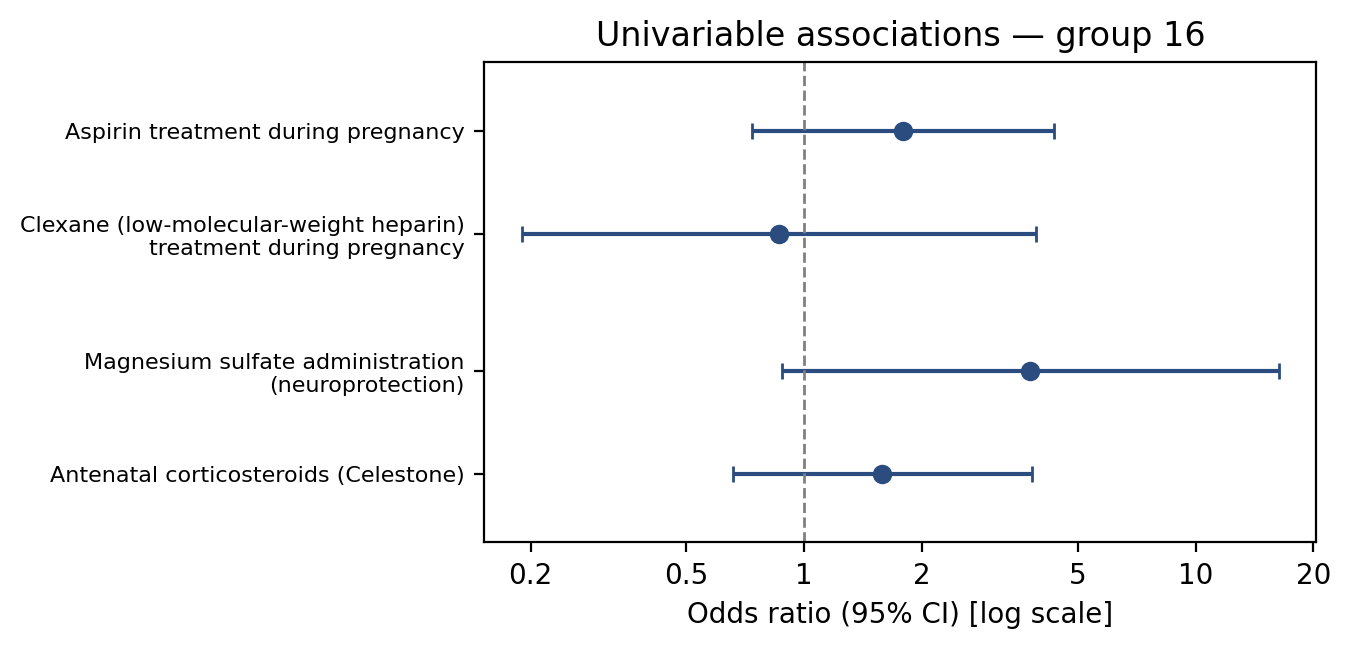

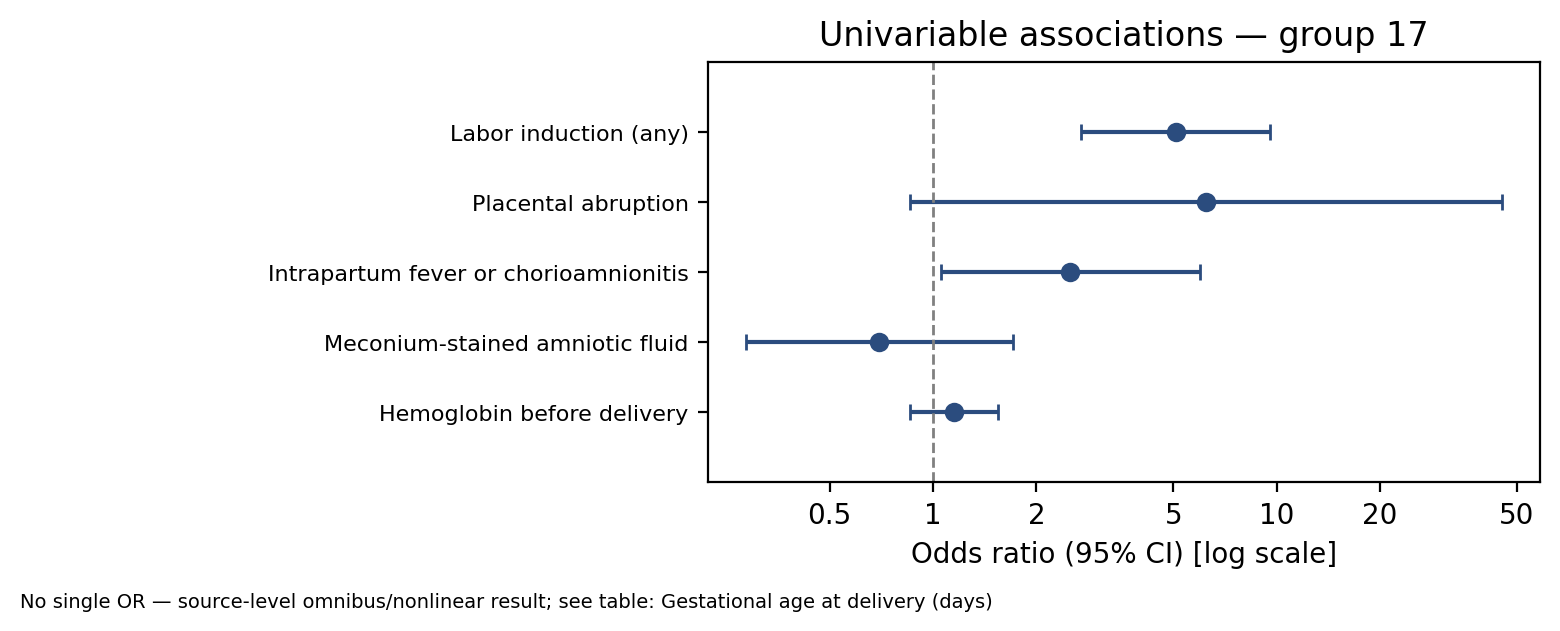

In [35]:
domain_map = dict(zip(features_df["variable"], features_df["domain"]))
plot_ready_predictors = sorted(
    univariable_master.loc[univariable_master["row_type"] == "source", "predictor"]
)
chunks = figures.group_variables_for_forest(plot_ready_predictors, domain_map)

# Clinical display labels (Section I correction #4): the technical
# `predictor` column is kept untouched (used for grouping/traceability
# below); a separate `predictor_display_label` column drives what is
# actually shown on the figure. A predictor without a documented clinical
# label falls back to its bare technical name (never a fabricated label).
univariable_master_labeled = publication_display_labels.add_display_label_column(
    univariable_master, predictor_col="predictor", label_col="predictor_display_label"
)
univariable_forest_rows = figures.prepare_forest_rows(
    univariable_master_labeled, label_col="predictor_display_label"
)

univariable_forest_figures = []
for i, chunk in enumerate(chunks):
    # `predictor` (technical, untouched by prepare_forest_rows since the
    # display label lives in a separate column) groups level rows with their
    # source predictor correctly, without needing to parse the display label.
    chunk_df = univariable_forest_rows[univariable_forest_rows["predictor"].isin(chunk)]
    # Readability correction: a domain group with ZERO plottable single-OR
    # estimates (e.g. every member is NOT_FITTED/non-estimable, or a lone
    # categorical-omnibus/nonlinear-spline result) no longer generates a
    # large, mostly-empty forest-plot image -- it prints a concise directive
    # message instead. This is a DISPLAY decision only: no univariable_master
    # / exported table row is ever dropped or altered by this branch.
    if figures.group_has_plottable_or_row(chunk_df):
        fig = figures.plot_forest(
            chunk_df,
            label_col="predictor_display_label",
            title=f"Univariable associations — group {i + 1}",
        )
        saved_path = exports.save_figure(fig, f"{exports.FOREST_UNIVARIABLE_PREFIX}group_{i + 1}.png")
        univariable_forest_figures.append(fig)
        exports.display_saved_figure(saved_path)
    else:
        print(
            f"Univariable associations — group {i + 1}: "
            + figures.describe_non_plottable_forest_group(chunk_df, label_col="predictor_display_label")
        )

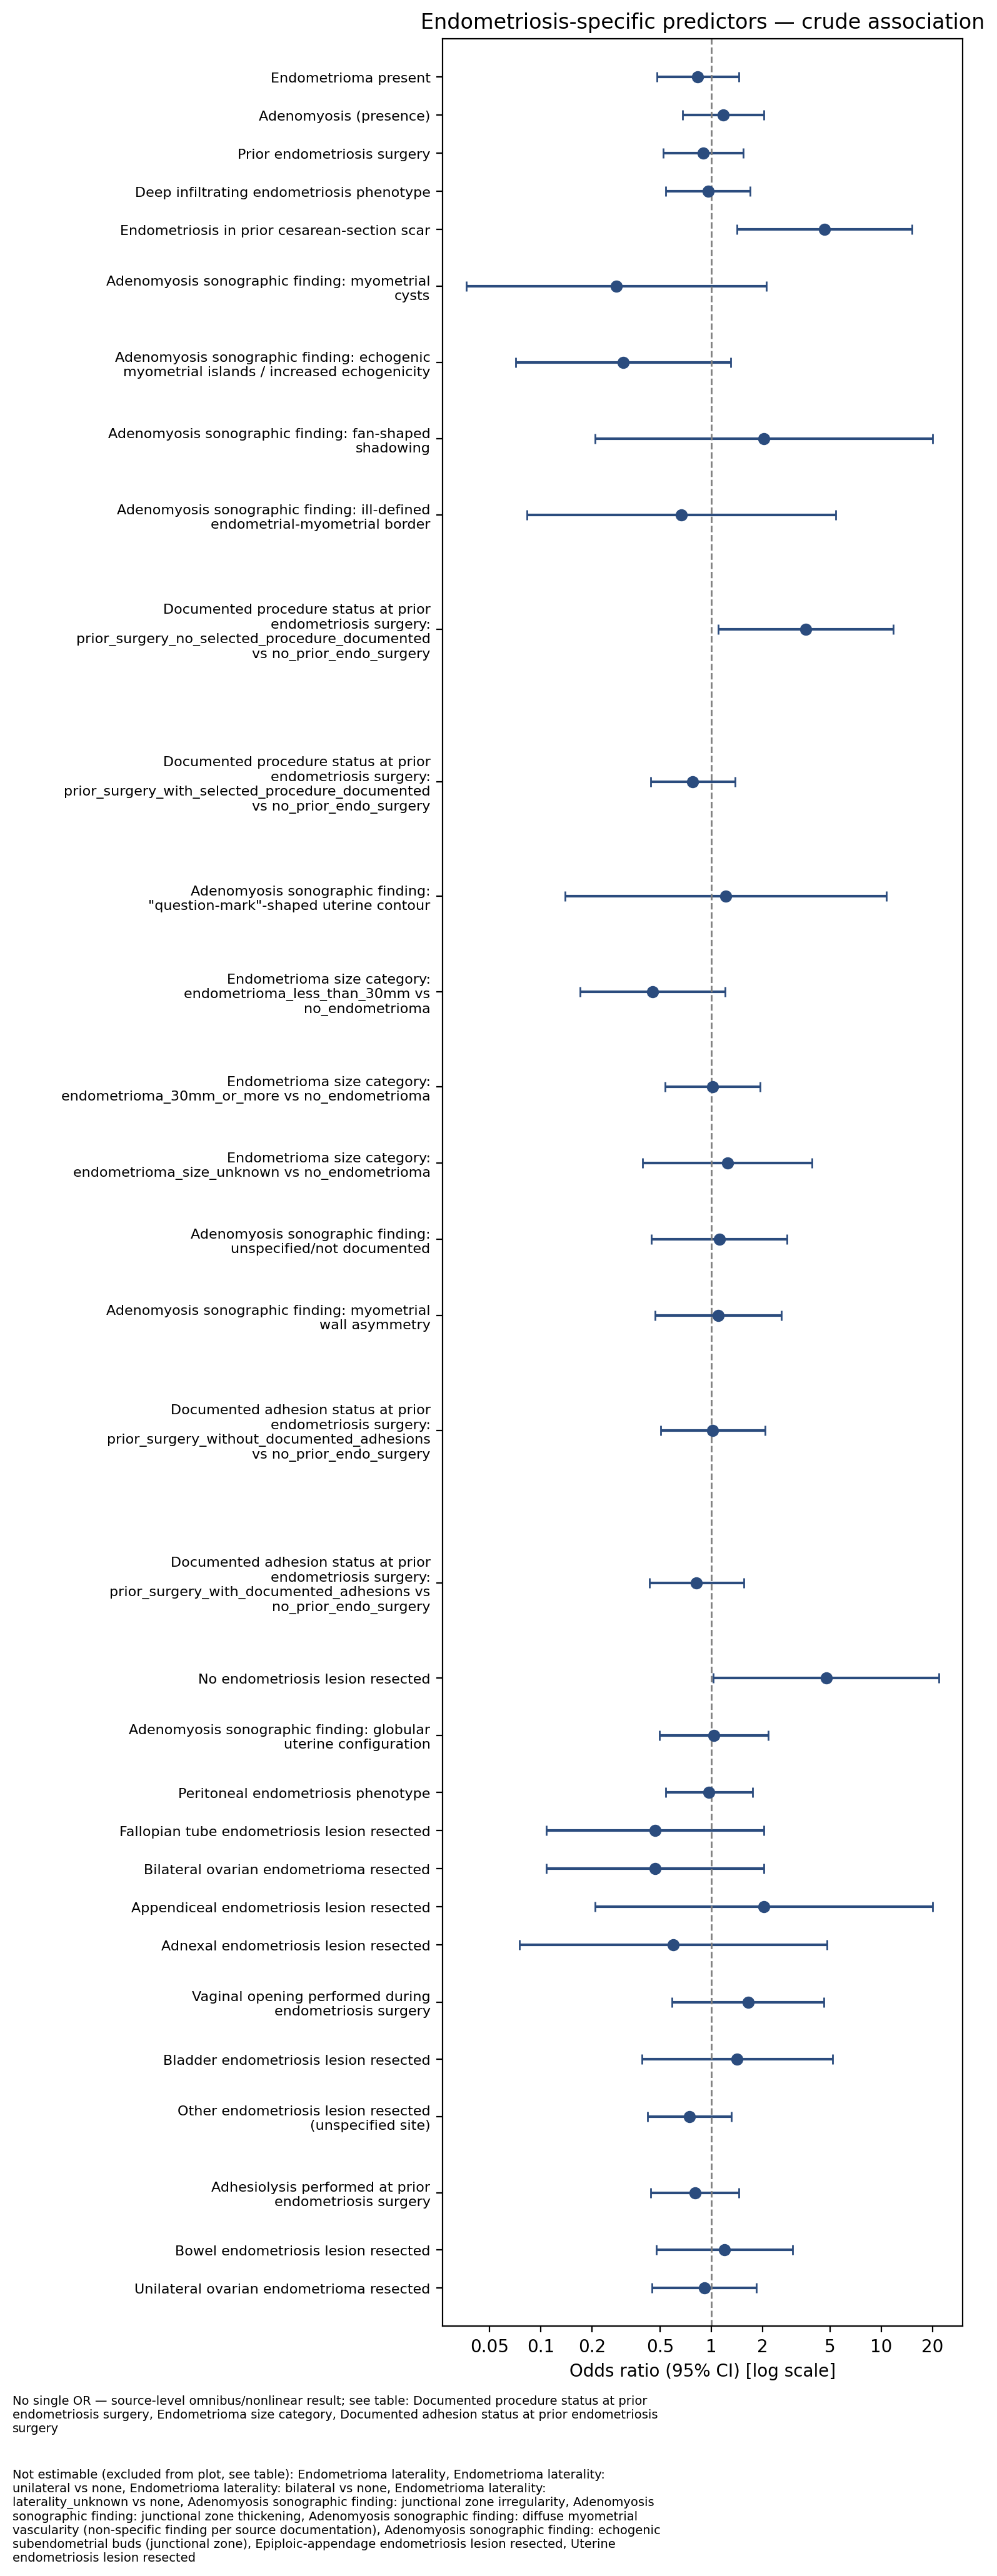

In [36]:
# Built from the canonical univariable_master (Section D), filtered to the
# 35 endometriosis-family predictors -- NOT from `endometriosis_findings`
# (Section E), which is intentionally source-level only and would omit
# legitimate categorical level-vs-reference OR points (Section I correction
# #3). No re-fit here: this is a read/filter/present operation only, and
# preserves source rows (incl. NO_SINGLE_OR omnibus/nonlinear rows) as well
# as categorical level rows.
endometriosis_family_master_rows = univariable_master[
    univariable_master["predictor"].isin(endo_family_names)
].copy()

fig_crude = figures.plot_endometriosis_forest(endometriosis_family_master_rows)
saved_path_crude = exports.save_figure(fig_crude, exports.FOREST_ENDOMETRIOSIS_CRUDE_PNG)
exports.display_saved_figure(saved_path_crude)

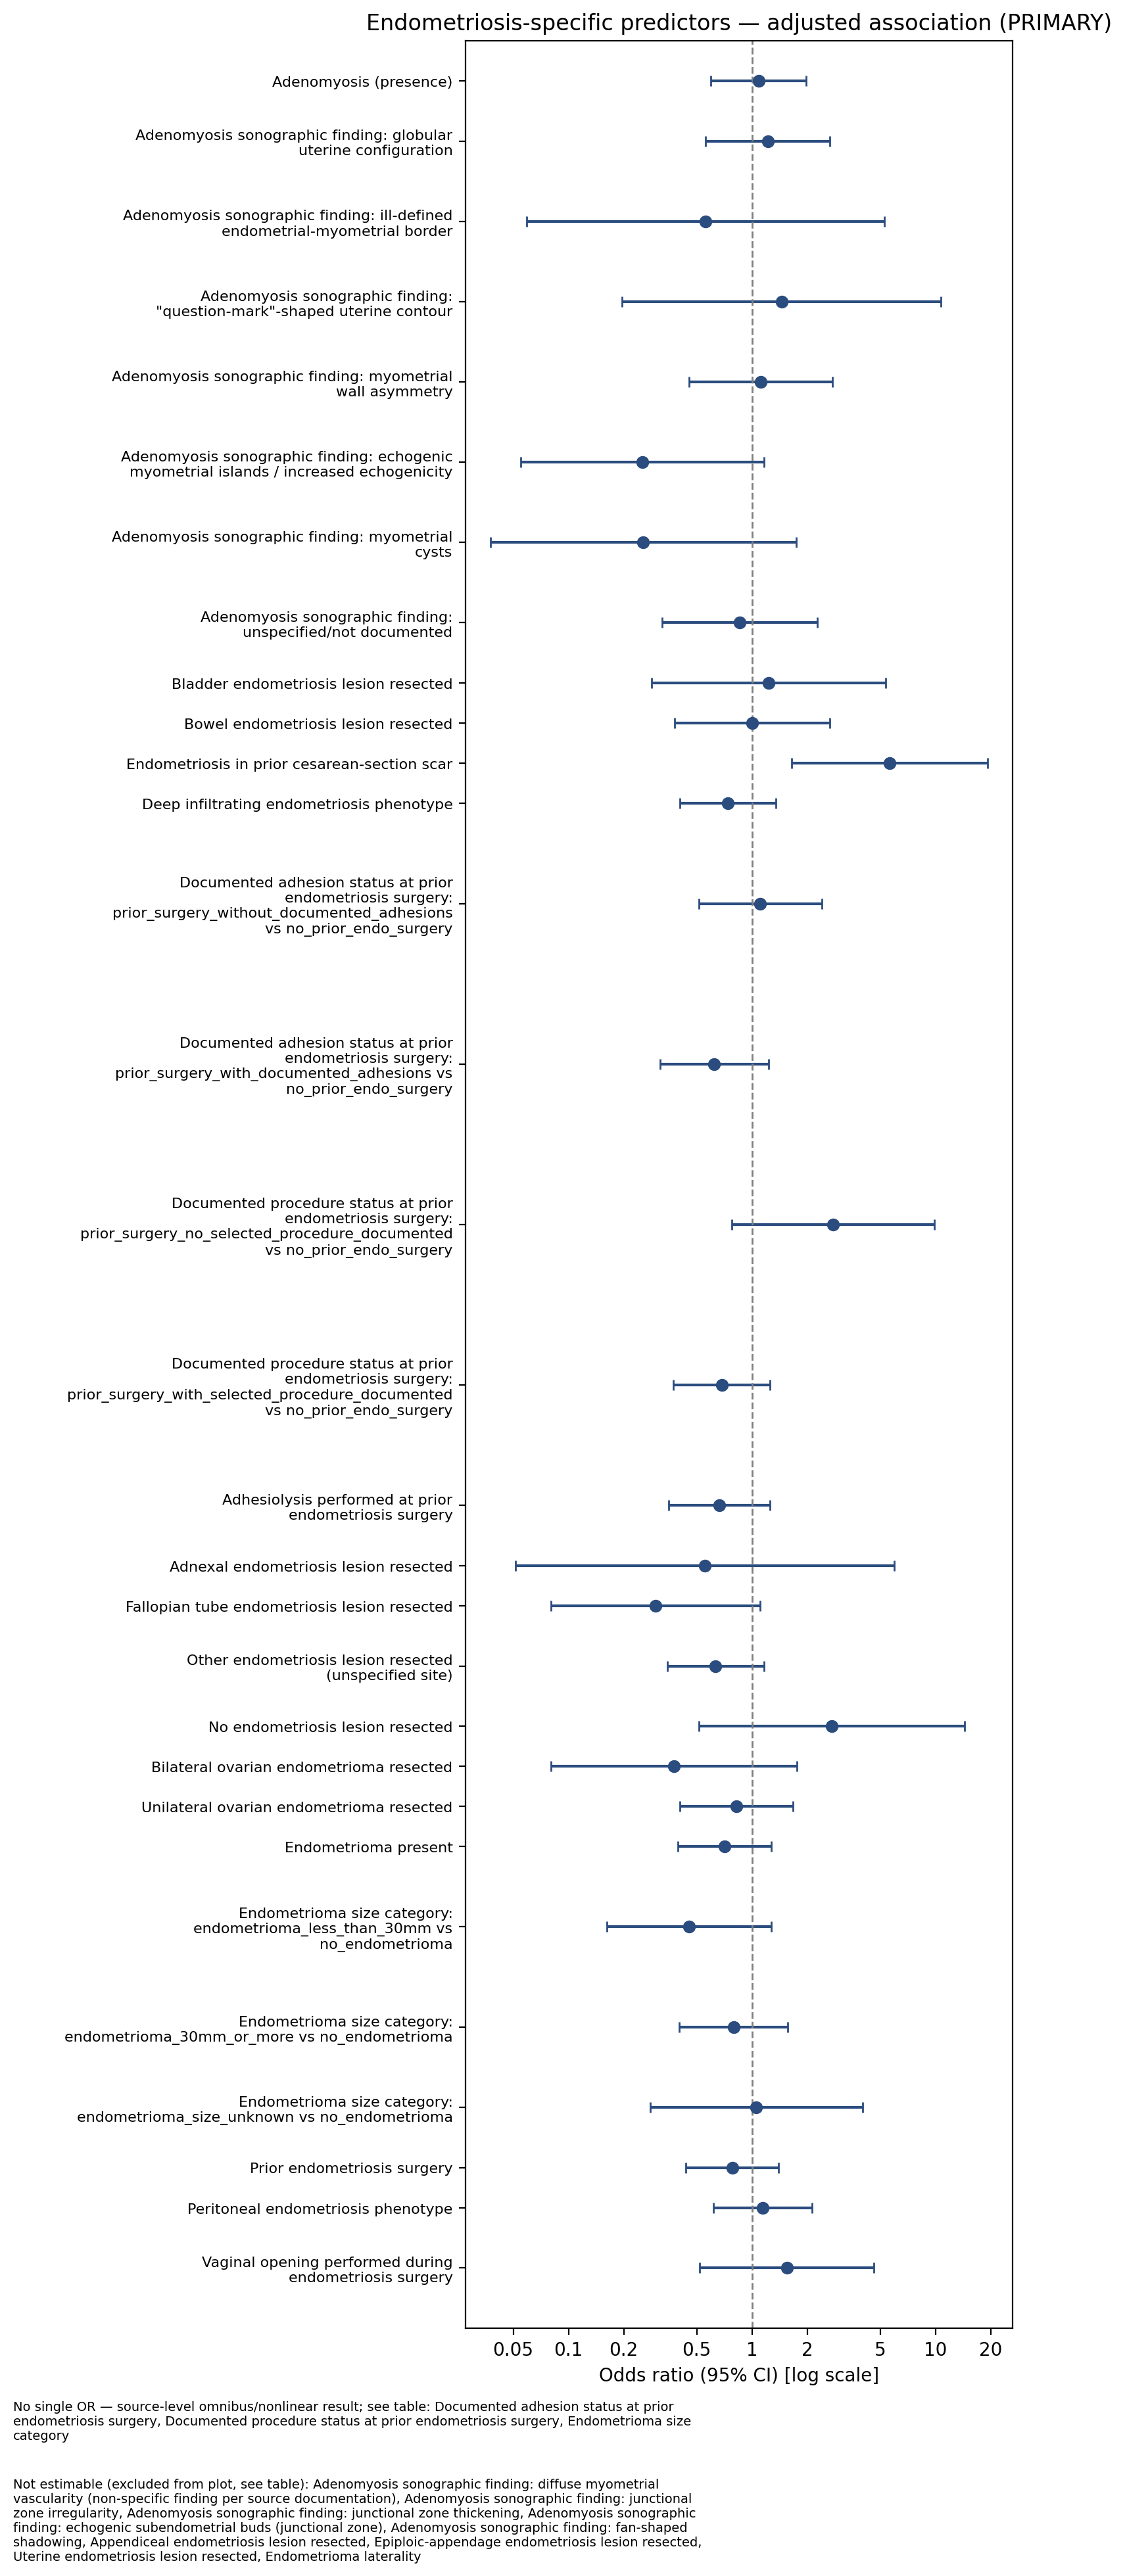

In [37]:
fig_adjusted = figures.plot_endometriosis_adjusted_forest(adjusted_master)
saved_path_adjusted = exports.save_figure(fig_adjusted, exports.FOREST_ENDOMETRIOSIS_ADJUSTED_PNG)
exports.display_saved_figure(saved_path_adjusted)

---
## Limitations

- **Association, not causation.** Nothing in this notebook establishes a
  causal effect of any endometriosis phenotype on intrapartum cesarean
  delivery; all associations may reflect confounding by factors not in the
  locked `PRIMARY_ADJUSTMENT_SET` (`AGE + nulliparity + S_P_CS`), or by
  factors that cannot be adjusted for without risking over-adjustment
  (variables downstream of the phenotype itself).
- **Small event count.** 61 intrapartum-CS events across up to 81 candidate
  predictors means most univariable and adjusted estimates — especially for
  rare endometriosis-specific sub-phenotypes — are exploratory, with wide
  confidence intervals; several are not reliably estimable at all
  (`STANDARD_OR_NOT_RELIABLY_ESTIMABLE`).
- **The adjustment sets are locked, not tunable — but still a specific,
  pre-specified choice.** `PRIMARY_ADJUSTMENT_SET` (`AGE + nulliparity +
  S_P_CS`) and `SENSITIVITY_ADJUSTMENT_SET` (adding
  `mode_of_conception_ivf_vs_all`) are approved (Adjusted Association Design
  Lock, Checkpoint C) and never altered based on a univariable p-value, a
  predictive-model selection result, or an exposure's observed OR — but they
  remain one specific, small conventional-covariate choice, not an
  exhaustive confounder set.
- **Complete-case inferential models (Section F).** The exploratory
  endometriosis-specific adjusted association models (one endometriosis
  exposure at a time, `PRIMARY_ADJUSTMENT_SET`/`SENSITIVITY_ADJUSTMENT_SET`)
  use complete-case rows only; no multiple imputation has been performed.
  Any adjusted analysis flagged with a high complete-case loss
  (`COMPLETE_CASE_RETENTION_WARNING`, Section F) may warrant a future MICE
  sensitivity analysis.
- **Different missing-data handling in the secondary six-predictor
  adjusted-OR analysis (Section H).** Unlike Section F, the secondary
  adjusted-OR analysis over the six Compact Ridge source predictors does
  **not** use complete-case deletion: all 431 cohort rows are retained via
  the same fold-safe reconstruction/imputation contract as the locked
  Compact Ridge final refit (`BMI_before` recomputed from
  component-level-imputed `height`/`weight_before_pregnancy`;
  `derived_hypertension_pih_pet_spectrum`'s 15 missing values imputed with
  the full-cohort mode). These are single reconstructions/imputations
  treated as fixed at estimation time, so the reported confidence intervals
  do not propagate that uncertainty — see
  `outputs/results/compact_ridge_final/adjusted_or/README.md` for the full
  methodology. This is a different, and not interchangeable, missing-data
  policy from Section F's complete-case approach; neither should be assumed
  to generalize to the other. This same secondary analysis also uses
  ordinary model-based MLE/Firth standard errors rather than the
  subject-cluster-robust SEs used in Section F; the 431 deliveries in this
  cohort correspond to 430 subject groups, with only one subject
  contributing two deliveries, which narrows but does not by itself prove
  zero impact of that choice.
- **Multiplicity.** BH-FDR q-values are an exploratory research aid across
  many simultaneous predictor-level tests: one global 81-predictor family in
  Section D, and a separate PRIMARY adjusted endometriosis analysis family in
  Section F. All 35 endometriosis-family source exposures are represented in
  the PRIMARY adjusted analysis; Class C (`STANDARD_ADJUSTED_MODEL_NOT_
  DEFENSIBLE`) exposures are `NOT_FITTED` and never enter the BH procedure at
  all. Benjamini-Hochberg correction is applied only to the estimable Class
  A/B PRIMARY source-level p-values (the exact counts — total represented,
  Class A/B eligible, and actually-estimable — are printed in Section F where
  `adjusted_primary_bh` is built, never hardcoded here). These q-values are
  not used here to decide predictive-model eligibility, to delete any
  predictor from a table, or as a substitute for clinical judgment about
  relevance.
- **Repeated deliveries.** A small number of subjects contribute more than
  one delivery to this cohort (Section A). Subject-cluster-robust standard
  errors are used where technically appropriate, but this does not fully
  resolve every possible source of within-subject correlation for every
  predictor.
- **Incremental predictive value: no dedicated Arm-A/B artifact exists.**
  No dedicated non-endometriosis-vs-full-pool comparison artifact has been
  generated — this does not mean the question was never examined: Decision
  99's completed exploratory model-improvement process already reached a
  documented negative conclusion (no stable incremental value from any
  endometriosis-specific predictor), surfaced read-only in Section H. The
  triangulation table in Section G does not depend on this artifact.
- **Predictive context is internal-validation only, and partly historical.**
  Section H's current Compact Ridge (Decision 99) metrics come from internal
  repeated grouped cross-validation on the same development cohort used for
  exploratory model development — not external validation. The Stage 3 /
  lasso_logistic Final-D metrics shown alongside it are explicitly
  HISTORICAL/SUPERSEDED context for methodological chronology only. Neither
  is re-validated here, and neither should be read as validating the
  associations in Sections D–G (prediction and association are different
  questions — see the introduction).